Сравним наилучший baseline из предыдущего шага с нейросетевыми решениями

In [1]:
%load_ext autoreload 
%autoreload 2

## Импорт необходимых библиотек и модулей

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd

In [53]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

In [5]:
import torch.nn as nn
import torch.optim as optim

In [56]:
from core.utils import *
from core.nlp import *
from core.visualization import *
from core.baseline_training import *
from core.vectorization import *
from core.nn_models import *
from core.nn_training import *

Для воспроизводимости экспериментов

In [7]:
SEED = 316

init_random_seed(SEED)

## Препроцессинг и лучший baseline

In [8]:
data_path = 'data'

In [9]:
data = pd.read_csv(f"{data_path}/ecommerceDataset.csv", header=None, names=["category", "description"])
data.sample(5)

,category,description
6692,Household,Handmade Butterfly Beaded Napkin Rings Set Of ...
37043,Clothing & Accessories,Urbaano G-Strings Eco Pack of Three A very hot...
48509,Electronics,By Pioneer BDP-180 Network 3D Blu-Ray Player w...
16111,Household,Mitashi 6.2 kg Fully-Automatic Top Loading Was...
23949,Books,Fear: Trump in the White House Review `As spec...


Повторим последовательность шагов по препроцессингу данных, аналогичную выполненным при построении baseline и воспроизведем наилучшее решение среди рассмотренных ранее базовых алгоритмов

In [10]:
data_preprocessed = data.copy()

data_preprocessed.dropna(inplace=True)
data_preprocessed.drop_duplicates(inplace=True)
data_preprocessed['description'] = data_preprocessed['description'].apply(tokenize_tiktoken)

print(data_preprocessed.shape)
data_preprocessed.sample(5)

(27802, 2)


,category,description
21219,Books,"[the, land, of, stories, :, worlds, coll, ide,..."
769,Household,"[space, wood, ci, ara, dress, er, table, with,..."
36248,Clothing & Accessories,"[v, ., k, ., jew, els, silver, twin, leaf, rh,..."
9399,Household,"[emb, assy, stainless, steel, multip, urpose, ..."
35221,Clothing & Accessories,"[am, erican, cre, w, men, 's, polyester, track..."


In [11]:
X, y = divide_data(data_preprocessed, 'category')

In [12]:
logreg_classifier = LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')
logreg_classifier

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,316
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv

StratifiedKFold(n_splits=5, random_state=316, shuffle=True)

In [14]:
count_vectorizer_processor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            ('prompt_vectorizer', CountVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32), 'description'),
        ],
        remainder='passthrough',
        verbose_feature_names_out=True
    ))
])

count_vectorizer_processor

,steps,"[('vectorizer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('prompt_vectorizer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<Figure size 1500x600 with 0 Axes>

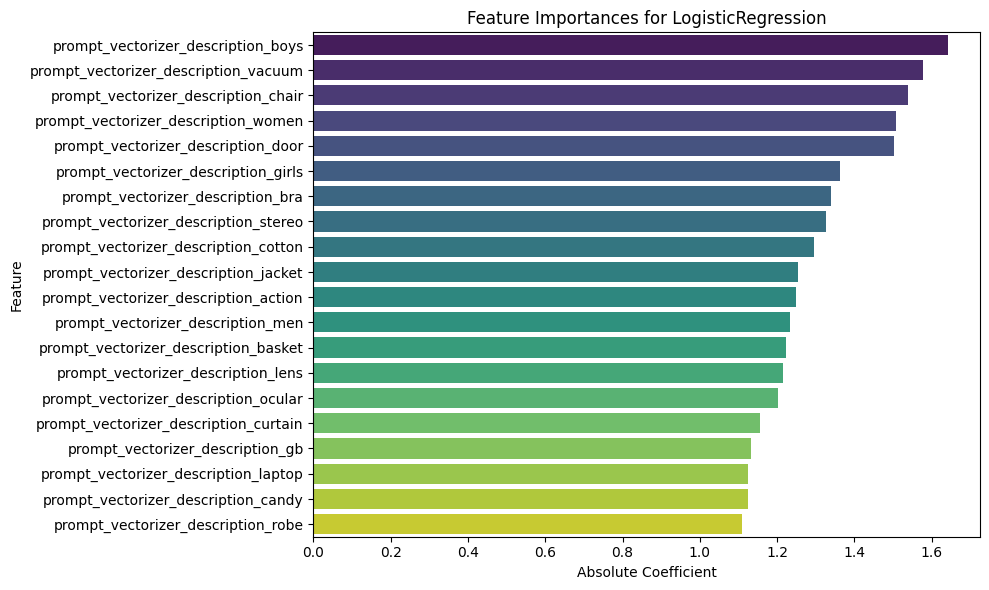

In [15]:
baseline_metrics, baseline_pipeline = train_evaluate_model_cv(model=logreg_classifier, model_name='LogisticRegression', X=X, y=y, 
                                                              preprocessor=count_vectorizer_processor, cv=cv, seed=SEED)

Посмотрим на метрики качества базового решения

In [16]:
baseline_metrics.to_compact_dict()

{'ROC AUC': nan,
 'F1 Score': 0.935450213183778,
 'Precision': 0.9365328795926754,
 'Recall': 0.9345777425840887,
 'Accuracy': 0.9362278794119892,
 'Training Time (s)': 51.82936501502991}

## Препроцессинг перед использованием нейросетей

Так как нейронные сети работают с последовательностями токенов, они не могут напрямую работать с несколькими отдельными текстами. Объединим их

In [49]:
data_nn = data.copy()

data_nn.dropna(inplace=True)
data_nn.drop_duplicates(inplace=True)
data_nn['description'] = data_nn['description'].apply(tokenize_tiktoken)
data_nn['category_id'] = data_nn['category'].map(category_codes)

print(data_nn.shape)
data_nn.sample(5)

(27802, 3)


,category,description,category_id
642,Household,"[trust, basket, single, pot, r, ailing, plan, ...",0
20919,Books,"[h, br, guide, to, data, analytics, basics, fo...",1
17763,Household,"[k, its, ch, ss, square, 450, mm, (, 18, ""), l...",0
45079,Electronics,"[amazon, bas, ics, 3, ., 5, mm, co, iled, ster...",3
15149,Household,"[e, g, ab, 12, v, dc, car, vacuum, cleaner, (,...",0


In [18]:
input_token_counts = token_counts(
    data_nn,
    'description',
    remove_stopwords=True,
    remove_punctuation=True,
    lowercase_for_counting=True
)

Определим максимальную длину последовательности для использования паддинга/усечения при пакетной обработке данных нейросетями

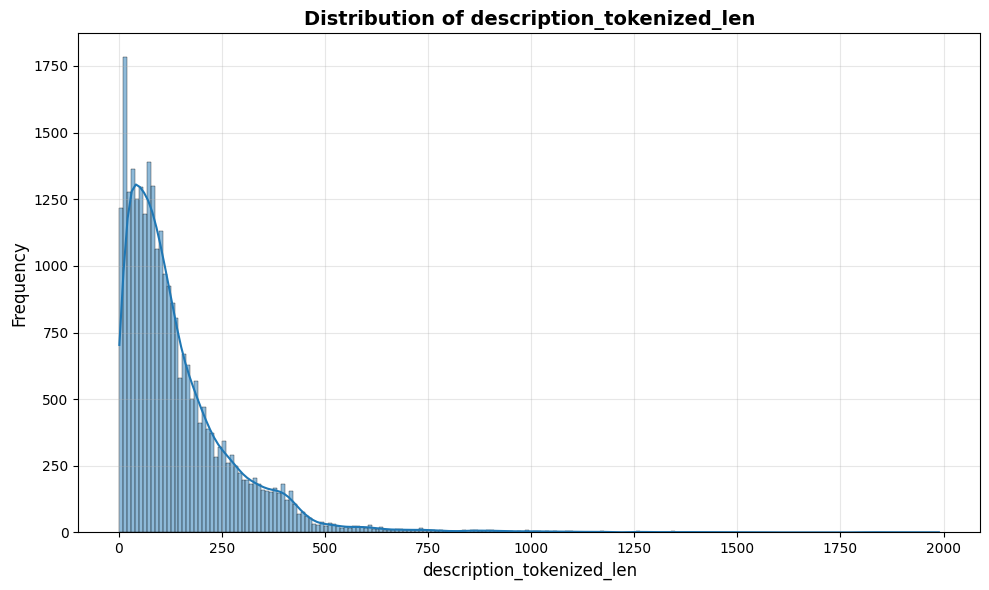

In [19]:
data_nn['description_tokenized_len'] = data_nn['description'].apply(len)
data_nn_filtered = data_nn[data_nn['description_tokenized_len'] < 2000]

plot_histogram_numeric(data_nn_filtered, 'description_tokenized_len', figsize=(10, 6))

data_nn.drop(columns=['description_tokenized_len'], inplace=True)

Для максимально полного анализа текстов откажемся лишь от малозаметного хвоста распределения и будем анализировать только первые 500 токенов последовательностей

In [20]:
MAX_SEQUENCE_LENGTH = 500 

In [21]:
vectorizer = SequenceVectorizer(max_length=MAX_SEQUENCE_LENGTH, pad_left=False)
input_vectorized = vectorizer.fit_transform(data_nn['description'])

input_vectorized.shape

(27802, 500)

Пайплайн предобработки текстов для нейронных сетей

In [22]:
basic_preprocessor = Pipeline([
    ('vectorizer', vectorizer)
])

basic_preprocessor

,steps,"[('vectorizer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,min_frequency,1
,max_vocab_size,None
,pad_token,'<PAD>'
,oov_token,'<OOV>'
,pad_left,False
,max_length,500
,dtype,'int32'


## RNN (Рекуррентная нейронная сеть)

RNN обрабатывает последовательности токенов слева направо, сохраняя информацию о предыдущих токенах. Используем Bidirectional RNN для анализа контекста в обе стороны

Определим гиперпараметры RNN и процесса обучения

In [23]:
LEARNING_RATE = 1e-3        
BATCH_SIZE = 256           
RNN_UNITS = 64              
EMBEDDING_DIM = 256         

DROPOUT_RATE = 0.2         
RECCURENT_DROPOUT_RATE = 0 

REGULARIZATION_STRENGTH = 1e-4

Выберем наиболее оптимальное устройство для обучения

In [24]:
device = get_device()

device

device(type='cuda')

Построим саму модель

In [50]:
rnn_model = RNNForCategoryClassification(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    rnn_units=RNN_UNITS,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECCURENT_DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id,
    num_classes=4,
).to(device)

rnn_model

RNNForCategoryClassification(
  (embedding): Embedding(31217, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (rnn): RNN(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

In [51]:
print(f"Рекуррентная модель содержит число параметров: {count_parameters(rnn_model)}")

Рекуррентная модель содержит число параметров: 8033284


Поскольку наши данные содержат дисбаланс, мы внесем эту информацию в функцию потерь с помощью настраиваемого веса положительного класса. Вычислим его

In [54]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(data_nn["category_id"]),
    y=data_nn["category_id"],
)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
class_weights

tensor([0.6579, 1.1110, 1.2250, 1.3094], device='cuda:0')

Определим функцию потерь и оптимизатор

In [57]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer_class = optim.Adam
optimizer_params = {"lr": LEARNING_RATE, "weight_decay": REGULARIZATION_STRENGTH}

Запустим обучение RNN


🌀 Fold 1/5


Training fold 1:   2%|███                                                                                                                                                       | 1/50 [00:18<14:50, 18.17s/it]

  Epoch 1/50 | Loss: 0.4412


Training fold 1:   4%|██████▏                                                                                                                                                   | 2/50 [00:36<14:31, 18.16s/it]

  Epoch 2/50 | Loss: 0.4085


Training fold 1:   6%|█████████▏                                                                                                                                                | 3/50 [00:54<14:19, 18.28s/it]

  Epoch 3/50 | Loss: 0.3915


Training fold 1:   8%|████████████▎                                                                                                                                             | 4/50 [01:13<14:06, 18.40s/it]

  Epoch 4/50 | Loss: 0.3868


Training fold 1:  10%|███████████████▍                                                                                                                                          | 5/50 [01:32<13:52, 18.51s/it]

  Epoch 5/50 | Loss: 0.3689


Training fold 1:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:50<13:33, 18.48s/it]

  Epoch 6/50 | Loss: 0.3491


Training fold 1:  14%|█████████████████████▌                                                                                                                                    | 7/50 [02:08<13:13, 18.46s/it]

  Epoch 7/50 | Loss: 0.3351


Training fold 1:  16%|████████████████████████▋                                                                                                                                 | 8/50 [02:27<12:54, 18.44s/it]

  Epoch 8/50 | Loss: 0.3169


Training fold 1:  18%|███████████████████████████▋                                                                                                                              | 9/50 [02:45<12:35, 18.42s/it]

  Epoch 9/50 | Loss: 0.3012


Training fold 1:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [03:04<12:19, 18.48s/it]

  Epoch 10/50 | Loss: 0.2889


Training fold 1:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [03:23<12:05, 18.59s/it]

  Epoch 11/50 | Loss: 0.2644


Training fold 1:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [03:41<11:46, 18.59s/it]

  Epoch 12/50 | Loss: 0.2444


Training fold 1:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [04:00<11:27, 18.59s/it]

  Epoch 13/50 | Loss: 0.2271


Training fold 1:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [04:18<11:05, 18.48s/it]

  Epoch 14/50 | Loss: 0.2099


Training fold 1:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [04:36<10:46, 18.48s/it]

  Epoch 15/50 | Loss: 0.2017


Training fold 1:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [04:56<10:34, 18.67s/it]

  Epoch 16/50 | Loss: 0.1851


Training fold 1:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [05:14<10:15, 18.66s/it]

  Epoch 17/50 | Loss: 0.1668


Training fold 1:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [05:33<09:59, 18.72s/it]

  Epoch 18/50 | Loss: 0.1519


Training fold 1:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [05:52<09:41, 18.75s/it]

  Epoch 19/50 | Loss: 0.1376


Training fold 1:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [06:11<09:21, 18.70s/it]

  Epoch 20/50 | Loss: 0.1365


Training fold 1:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [06:29<08:58, 18.56s/it]

  Epoch 21/50 | Loss: 0.1266


Training fold 1:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [06:47<08:38, 18.51s/it]

  Epoch 22/50 | Loss: 0.1233


Training fold 1:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [07:05<08:18, 18.47s/it]

  Epoch 23/50 | Loss: 0.1236


Training fold 1:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [07:24<08:02, 18.57s/it]

  Epoch 24/50 | Loss: 0.1196


Training fold 1:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [07:43<07:46, 18.64s/it]

  Epoch 25/50 | Loss: 0.1132


Training fold 1:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [08:02<07:27, 18.66s/it]

  Epoch 26/50 | Loss: 0.1135


Training fold 1:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [08:20<07:07, 18.57s/it]

  Epoch 27/50 | Loss: 0.0992


Training fold 1:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [08:39<06:51, 18.68s/it]

  Epoch 28/50 | Loss: 0.1008


Training fold 1:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [08:58<06:33, 18.75s/it]

  Epoch 29/50 | Loss: 0.0953


Training fold 1:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [09:17<06:16, 18.82s/it]

  Epoch 30/50 | Loss: 0.0911


Training fold 1:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [09:36<05:57, 18.84s/it]

  Epoch 31/50 | Loss: 0.0931


Training fold 1:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [09:55<05:39, 18.85s/it]

  Epoch 32/50 | Loss: 0.0892


Training fold 1:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [10:14<05:19, 18.82s/it]

  Epoch 33/50 | Loss: 0.0831


Training fold 1:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [10:32<04:59, 18.72s/it]

  Epoch 34/50 | Loss: 0.0788


Training fold 1:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [10:51<04:41, 18.79s/it]

  Epoch 35/50 | Loss: 0.0826


Training fold 1:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [11:10<04:23, 18.83s/it]

  Epoch 36/50 | Loss: 0.0847


Training fold 1:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [11:28<04:03, 18.74s/it]

  Epoch 37/50 | Loss: 0.0768


Training fold 1:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [11:47<03:44, 18.68s/it]

  Epoch 38/50 | Loss: 0.0789


Training fold 1:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [12:06<03:25, 18.69s/it]

  Epoch 39/50 | Loss: 0.0726


Training fold 1:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [12:25<03:07, 18.78s/it]

  Epoch 40/50 | Loss: 0.0792


Training fold 1:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [12:43<02:48, 18.76s/it]

  Epoch 41/50 | Loss: 0.0789


Training fold 1:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [13:02<02:30, 18.82s/it]

  Epoch 42/50 | Loss: 0.0672


Training fold 1:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [13:21<02:11, 18.79s/it]

  Epoch 43/50 | Loss: 0.0681


Training fold 1:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [13:40<01:52, 18.71s/it]

  Epoch 44/50 | Loss: 0.0718


Training fold 1:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [13:58<01:33, 18.62s/it]

  Epoch 45/50 | Loss: 0.0705


Training fold 1:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [14:16<01:14, 18.56s/it]

  Epoch 46/50 | Loss: 0.0601


Training fold 1:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [14:35<00:55, 18.52s/it]

  Epoch 47/50 | Loss: 0.0598


Training fold 1:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [14:53<00:37, 18.51s/it]

  Epoch 48/50 | Loss: 0.0680


Training fold 1:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [15:12<00:18, 18.62s/it]

  Epoch 49/50 | Loss: 0.0623


Training fold 1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [15:31<00:00, 18.64s/it]


  Epoch 50/50 | Loss: 0.0634


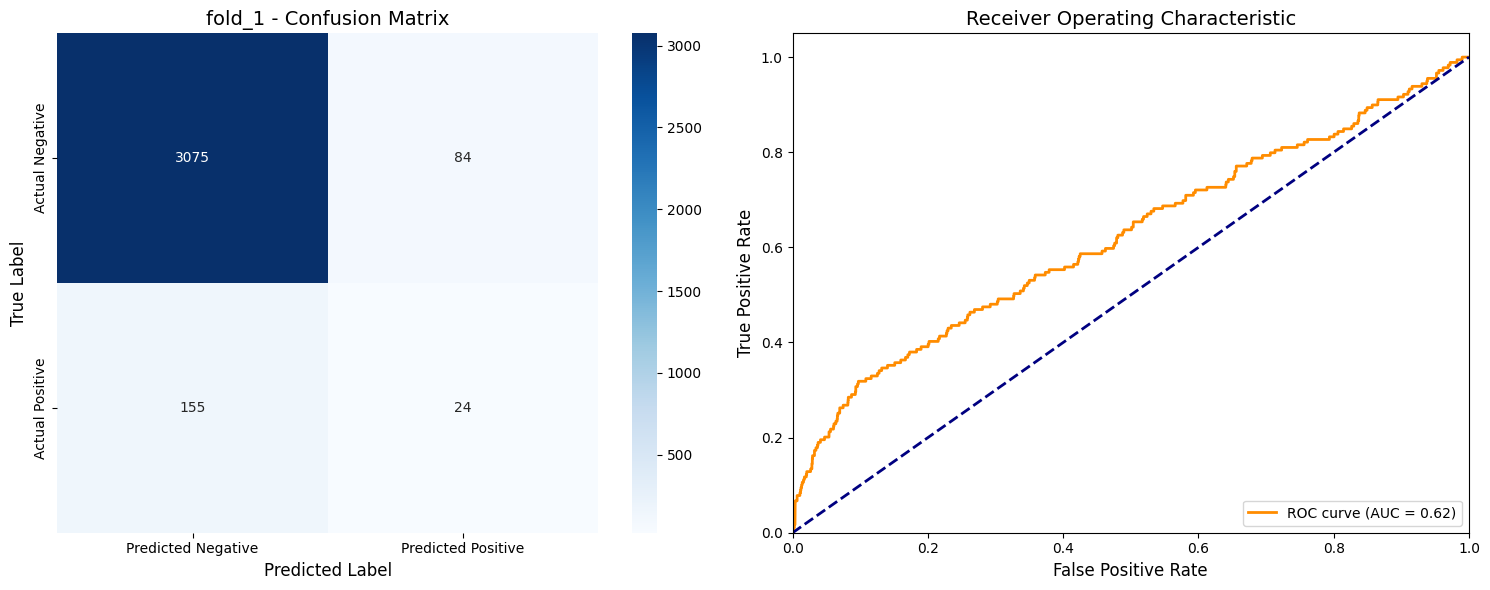


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6204
 F1 Score 0.5649
Precision 0.5871
   Recall 0.5537
 Accuracy 0.9284


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.222222 0.134078
Negative   0.952012 0.973409


🌀 Fold 2/5


Training fold 2:   2%|███                                                                                                                                                       | 1/50 [00:18<15:21, 18.80s/it]

  Epoch 1/50 | Loss: 0.4381


Training fold 2:   4%|██████▏                                                                                                                                                   | 2/50 [00:38<15:14, 19.05s/it]

  Epoch 2/50 | Loss: 0.3941


Training fold 2:   6%|█████████▏                                                                                                                                                | 3/50 [00:56<14:48, 18.90s/it]

  Epoch 3/50 | Loss: 0.3913


Training fold 2:   8%|████████████▎                                                                                                                                             | 4/50 [01:15<14:30, 18.93s/it]

  Epoch 4/50 | Loss: 0.3744


Training fold 2:  10%|███████████████▍                                                                                                                                          | 5/50 [01:34<14:07, 18.82s/it]

  Epoch 5/50 | Loss: 0.3540


Training fold 2:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:53<13:46, 18.79s/it]

  Epoch 6/50 | Loss: 0.3406


Training fold 2:  14%|█████████████████████▌                                                                                                                                    | 7/50 [02:11<13:28, 18.80s/it]

  Epoch 7/50 | Loss: 0.3171


Training fold 2:  16%|████████████████████████▋                                                                                                                                 | 8/50 [02:30<13:09, 18.80s/it]

  Epoch 8/50 | Loss: 0.2972


Training fold 2:  18%|███████████████████████████▋                                                                                                                              | 9/50 [02:49<12:49, 18.78s/it]

  Epoch 9/50 | Loss: 0.2725


Training fold 2:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [03:08<12:31, 18.79s/it]

  Epoch 10/50 | Loss: 0.2608


Training fold 2:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [03:27<12:12, 18.79s/it]

  Epoch 11/50 | Loss: 0.2374


Training fold 2:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [03:45<11:55, 18.83s/it]

  Epoch 12/50 | Loss: 0.2197


Training fold 2:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [04:05<11:42, 18.98s/it]

  Epoch 13/50 | Loss: 0.2049


Training fold 2:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [04:24<11:26, 19.08s/it]

  Epoch 14/50 | Loss: 0.1890


Training fold 2:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [04:43<11:10, 19.16s/it]

  Epoch 15/50 | Loss: 0.1792


Training fold 2:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [05:03<10:52, 19.21s/it]

  Epoch 16/50 | Loss: 0.1722


Training fold 2:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [05:22<10:36, 19.28s/it]

  Epoch 17/50 | Loss: 0.1463


Training fold 2:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [05:42<10:18, 19.32s/it]

  Epoch 18/50 | Loss: 0.1437


Training fold 2:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [06:01<09:59, 19.34s/it]

  Epoch 19/50 | Loss: 0.1339


Training fold 2:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [06:21<09:41, 19.39s/it]

  Epoch 20/50 | Loss: 0.1346


Training fold 2:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [06:40<09:23, 19.41s/it]

  Epoch 21/50 | Loss: 0.1272


Training fold 2:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [06:59<09:02, 19.38s/it]

  Epoch 22/50 | Loss: 0.1171


Training fold 2:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [07:19<08:44, 19.44s/it]

  Epoch 23/50 | Loss: 0.1134


Training fold 2:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [07:38<08:24, 19.42s/it]

  Epoch 24/50 | Loss: 0.1115


Training fold 2:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [07:58<08:06, 19.45s/it]

  Epoch 25/50 | Loss: 0.1063


Training fold 2:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [08:17<07:47, 19.47s/it]

  Epoch 26/50 | Loss: 0.0947


Training fold 2:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [08:37<07:27, 19.47s/it]

  Epoch 27/50 | Loss: 0.0925


Training fold 2:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [08:56<07:08, 19.47s/it]

  Epoch 28/50 | Loss: 0.0963


Training fold 2:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [09:16<06:49, 19.48s/it]

  Epoch 29/50 | Loss: 0.0923


Training fold 2:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [09:35<06:29, 19.50s/it]

  Epoch 30/50 | Loss: 0.0876


Training fold 2:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [09:55<06:10, 19.49s/it]

  Epoch 31/50 | Loss: 0.0925


Training fold 2:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [10:14<05:50, 19.50s/it]

  Epoch 32/50 | Loss: 0.0841


Training fold 2:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [10:34<05:31, 19.51s/it]

  Epoch 33/50 | Loss: 0.0780


Training fold 2:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [10:53<05:12, 19.52s/it]

  Epoch 34/50 | Loss: 0.0763


Training fold 2:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [11:13<04:53, 19.53s/it]

  Epoch 35/50 | Loss: 0.0796


Training fold 2:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [11:33<04:33, 19.57s/it]

  Epoch 36/50 | Loss: 0.0779


Training fold 2:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [11:52<04:14, 19.59s/it]

  Epoch 37/50 | Loss: 0.0754


Training fold 2:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [12:12<03:54, 19.57s/it]

  Epoch 38/50 | Loss: 0.0742


Training fold 2:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [12:31<03:35, 19.56s/it]

  Epoch 39/50 | Loss: 0.0735


Training fold 2:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [12:51<03:15, 19.53s/it]

  Epoch 40/50 | Loss: 0.0674


Training fold 2:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [13:10<02:55, 19.55s/it]

  Epoch 41/50 | Loss: 0.0665


Training fold 2:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [13:30<02:36, 19.56s/it]

  Epoch 42/50 | Loss: 0.0727


Training fold 2:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [13:49<02:17, 19.57s/it]

  Epoch 43/50 | Loss: 0.0706


Training fold 2:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [14:09<01:57, 19.58s/it]

  Epoch 44/50 | Loss: 0.0630


Training fold 2:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [14:29<01:37, 19.57s/it]

  Epoch 45/50 | Loss: 0.0635


Training fold 2:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [14:48<01:17, 19.46s/it]

  Epoch 46/50 | Loss: 0.0528


Training fold 2:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [15:07<00:58, 19.46s/it]

  Epoch 47/50 | Loss: 0.0602


Training fold 2:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [15:27<00:38, 19.47s/it]

  Epoch 48/50 | Loss: 0.0555


Training fold 2:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [15:46<00:19, 19.48s/it]

  Epoch 49/50 | Loss: 0.0564


Training fold 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [16:06<00:00, 19.32s/it]


  Epoch 50/50 | Loss: 0.0568


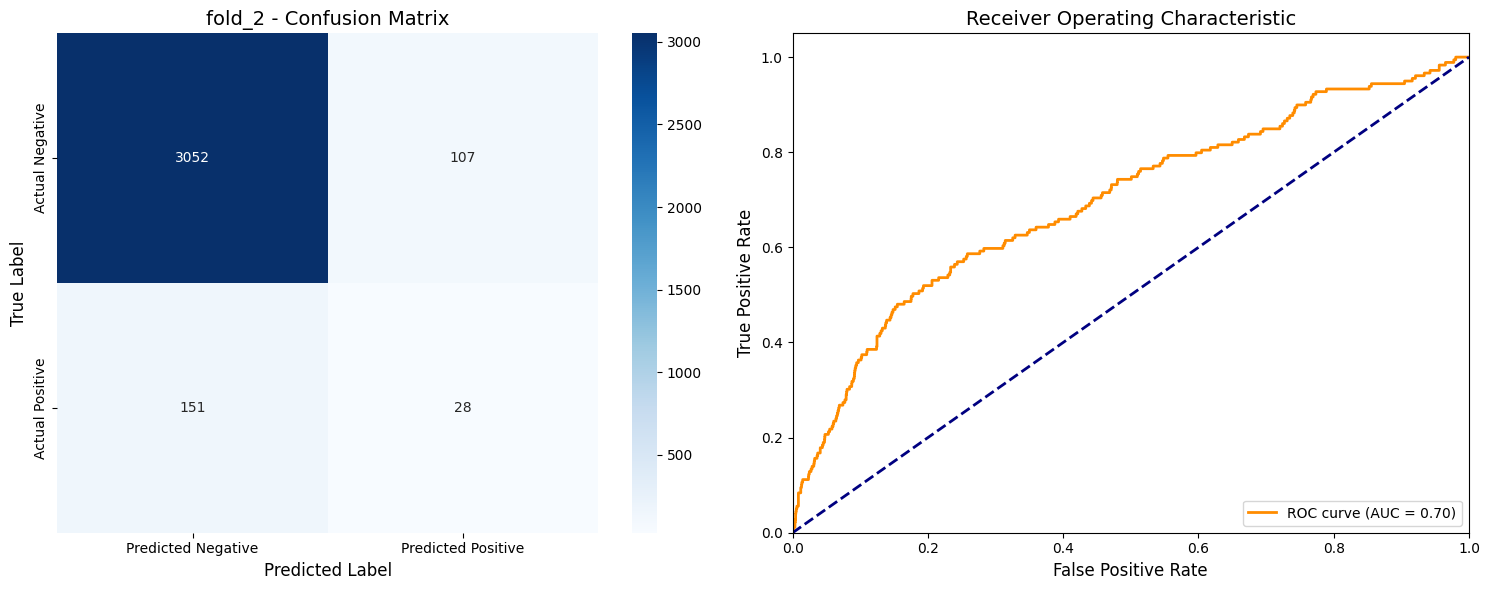


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6957
 F1 Score 0.5689
Precision 0.5801
   Recall 0.5613
 Accuracy 0.9227


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.207407 0.156425
Negative   0.952857 0.966129


🌀 Fold 3/5


Training fold 3:   2%|███                                                                                                                                                       | 1/50 [00:18<15:27, 18.93s/it]

  Epoch 1/50 | Loss: 0.4353


Training fold 3:   4%|██████▏                                                                                                                                                   | 2/50 [00:38<15:15, 19.08s/it]

  Epoch 2/50 | Loss: 0.4024


Training fold 3:   6%|█████████▏                                                                                                                                                | 3/50 [00:57<14:54, 19.03s/it]

  Epoch 3/50 | Loss: 0.3863


Training fold 3:   8%|████████████▎                                                                                                                                             | 4/50 [01:16<14:41, 19.17s/it]

  Epoch 4/50 | Loss: 0.3761


Training fold 3:  10%|███████████████▍                                                                                                                                          | 5/50 [01:35<14:21, 19.15s/it]

  Epoch 5/50 | Loss: 0.3588


Training fold 3:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:54<14:02, 19.16s/it]

  Epoch 6/50 | Loss: 0.3472


Training fold 3:  14%|█████████████████████▌                                                                                                                                    | 7/50 [02:13<13:43, 19.15s/it]

  Epoch 7/50 | Loss: 0.3361


Training fold 3:  16%|████████████████████████▋                                                                                                                                 | 8/50 [02:32<13:22, 19.10s/it]

  Epoch 8/50 | Loss: 0.3105


Training fold 3:  18%|███████████████████████████▋                                                                                                                              | 9/50 [02:52<13:05, 19.16s/it]

  Epoch 9/50 | Loss: 0.3041


Training fold 3:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [03:11<12:47, 19.18s/it]

  Epoch 10/50 | Loss: 0.2813


Training fold 3:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [03:30<12:31, 19.28s/it]

  Epoch 11/50 | Loss: 0.2573


Training fold 3:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [03:50<12:12, 19.28s/it]

  Epoch 12/50 | Loss: 0.2351


Training fold 3:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [04:09<11:53, 19.28s/it]

  Epoch 13/50 | Loss: 0.2290


Training fold 3:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [04:28<11:33, 19.26s/it]

  Epoch 14/50 | Loss: 0.2109


Training fold 3:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [04:48<11:14, 19.28s/it]

  Epoch 15/50 | Loss: 0.1927


Training fold 3:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [05:07<10:55, 19.28s/it]

  Epoch 16/50 | Loss: 0.1779


Training fold 3:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [05:26<10:38, 19.36s/it]

  Epoch 17/50 | Loss: 0.1583


Training fold 3:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [05:46<10:20, 19.39s/it]

  Epoch 18/50 | Loss: 0.1584


Training fold 3:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [06:05<10:00, 19.36s/it]

  Epoch 19/50 | Loss: 0.1528


Training fold 3:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [06:24<09:39, 19.31s/it]

  Epoch 20/50 | Loss: 0.1509


Training fold 3:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [06:44<09:20, 19.33s/it]

  Epoch 21/50 | Loss: 0.1273


Training fold 3:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [07:03<09:00, 19.31s/it]

  Epoch 22/50 | Loss: 0.1167


Training fold 3:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [07:22<08:41, 19.32s/it]

  Epoch 23/50 | Loss: 0.1120


Training fold 3:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [07:42<08:22, 19.32s/it]

  Epoch 24/50 | Loss: 0.1131


Training fold 3:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [08:01<08:04, 19.37s/it]

  Epoch 25/50 | Loss: 0.1051


Training fold 3:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [08:20<07:44, 19.35s/it]

  Epoch 26/50 | Loss: 0.1120


Training fold 3:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [08:40<07:24, 19.34s/it]

  Epoch 27/50 | Loss: 0.0983


Training fold 3:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [08:59<07:05, 19.34s/it]

  Epoch 28/50 | Loss: 0.0913


Training fold 3:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [09:19<06:47, 19.41s/it]

  Epoch 29/50 | Loss: 0.0846


Training fold 3:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [09:38<06:27, 19.38s/it]

  Epoch 30/50 | Loss: 0.0943


Training fold 3:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [09:57<06:07, 19.35s/it]

  Epoch 31/50 | Loss: 0.0862


Training fold 3:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [10:16<05:47, 19.30s/it]

  Epoch 32/50 | Loss: 0.0876


Training fold 3:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [10:36<05:27, 19.27s/it]

  Epoch 33/50 | Loss: 0.0962


Training fold 3:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [10:55<05:08, 19.28s/it]

  Epoch 34/50 | Loss: 0.0879


Training fold 3:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [11:14<04:49, 19.32s/it]

  Epoch 35/50 | Loss: 0.0785


Training fold 3:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [11:34<04:30, 19.34s/it]

  Epoch 36/50 | Loss: 0.0786


Training fold 3:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [11:53<04:12, 19.40s/it]

  Epoch 37/50 | Loss: 0.0769


Training fold 3:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [12:13<03:52, 19.40s/it]

  Epoch 38/50 | Loss: 0.0727


Training fold 3:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [12:32<03:34, 19.46s/it]

  Epoch 39/50 | Loss: 0.0720


Training fold 3:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [12:52<03:14, 19.42s/it]

  Epoch 40/50 | Loss: 0.0723


Training fold 3:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [13:11<02:54, 19.39s/it]

  Epoch 41/50 | Loss: 0.0730


Training fold 3:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [13:30<02:34, 19.35s/it]

  Epoch 42/50 | Loss: 0.0785


Training fold 3:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [13:50<02:15, 19.41s/it]

  Epoch 43/50 | Loss: 0.0775


Training fold 3:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [14:09<01:56, 19.45s/it]

  Epoch 44/50 | Loss: 0.0691


Training fold 3:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [14:29<01:37, 19.47s/it]

  Epoch 45/50 | Loss: 0.0743


Training fold 3:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [14:48<01:17, 19.45s/it]

  Epoch 46/50 | Loss: 0.0656


Training fold 3:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [15:07<00:58, 19.37s/it]

  Epoch 47/50 | Loss: 0.0571


Training fold 3:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [15:26<00:38, 19.23s/it]

  Epoch 48/50 | Loss: 0.0562


Training fold 3:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [15:46<00:19, 19.26s/it]

  Epoch 49/50 | Loss: 0.0623


Training fold 3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [16:05<00:00, 19.30s/it]


  Epoch 50/50 | Loss: 0.0650


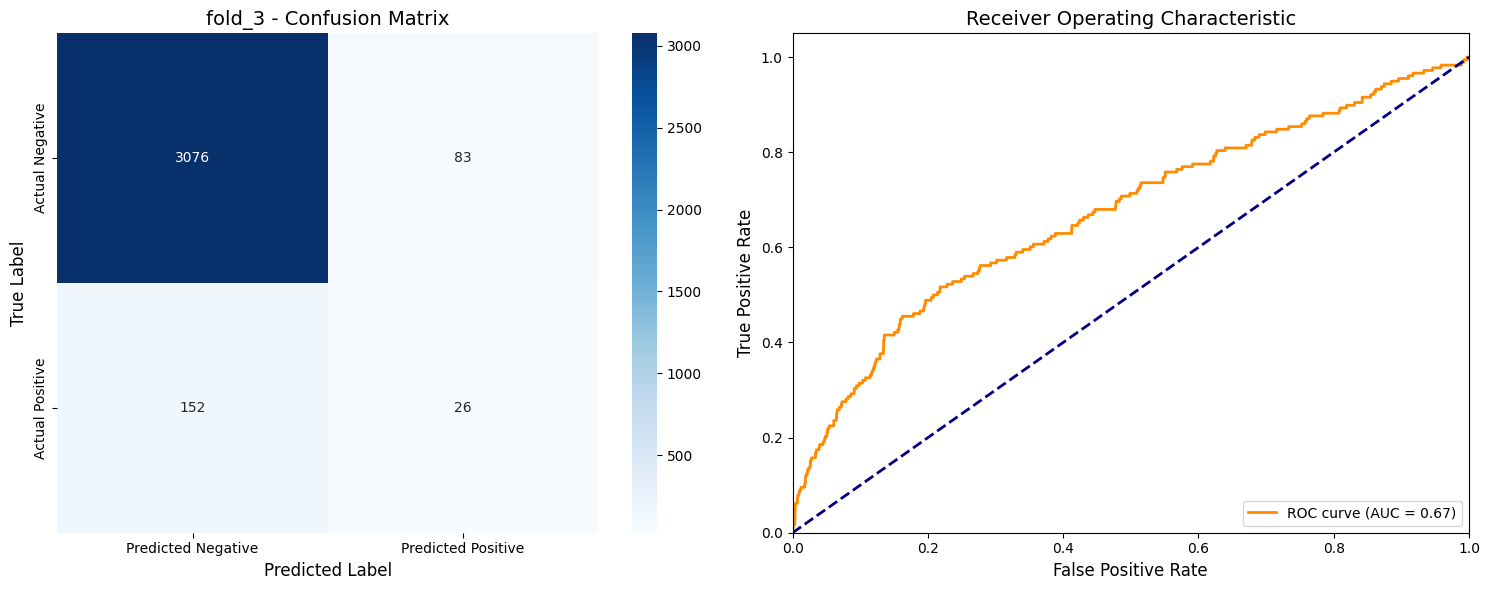


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6720
 F1 Score 0.5722
Precision 0.5957
   Recall 0.5599
 Accuracy 0.9296


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.238532 0.146067
Negative   0.952912 0.973726


🌀 Fold 4/5


Training fold 4:   2%|███                                                                                                                                                       | 1/50 [00:18<15:25, 18.88s/it]

  Epoch 1/50 | Loss: 0.4367


Training fold 4:   4%|██████▏                                                                                                                                                   | 2/50 [00:37<14:57, 18.71s/it]

  Epoch 2/50 | Loss: 0.4008


Training fold 4:   6%|█████████▏                                                                                                                                                | 3/50 [00:55<14:32, 18.57s/it]

  Epoch 3/50 | Loss: 0.3910


Training fold 4:   8%|████████████▎                                                                                                                                             | 4/50 [01:14<14:09, 18.47s/it]

  Epoch 4/50 | Loss: 0.3700


Training fold 4:  10%|███████████████▍                                                                                                                                          | 5/50 [01:32<13:49, 18.44s/it]

  Epoch 5/50 | Loss: 0.3625


Training fold 4:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:50<13:29, 18.41s/it]

  Epoch 6/50 | Loss: 0.3400


Training fold 4:  14%|█████████████████████▌                                                                                                                                    | 7/50 [02:09<13:10, 18.39s/it]

  Epoch 7/50 | Loss: 0.3211


Training fold 4:  16%|████████████████████████▋                                                                                                                                 | 8/50 [02:27<12:51, 18.37s/it]

  Epoch 8/50 | Loss: 0.3101


Training fold 4:  18%|███████████████████████████▋                                                                                                                              | 9/50 [02:45<12:33, 18.38s/it]

  Epoch 9/50 | Loss: 0.2897


Training fold 4:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [03:04<12:14, 18.36s/it]

  Epoch 10/50 | Loss: 0.2707


Training fold 4:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [03:22<11:55, 18.34s/it]

  Epoch 11/50 | Loss: 0.2580


Training fold 4:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [03:40<11:36, 18.33s/it]

  Epoch 12/50 | Loss: 0.2333


Training fold 4:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [03:59<11:18, 18.33s/it]

  Epoch 13/50 | Loss: 0.2199


Training fold 4:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [04:17<10:59, 18.33s/it]

  Epoch 14/50 | Loss: 0.2079


Training fold 4:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [04:35<10:41, 18.33s/it]

  Epoch 15/50 | Loss: 0.1877


Training fold 4:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [04:54<10:23, 18.34s/it]

  Epoch 16/50 | Loss: 0.1691


Training fold 4:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [05:12<10:05, 18.35s/it]

  Epoch 17/50 | Loss: 0.1607


Training fold 4:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [05:31<09:47, 18.37s/it]

  Epoch 18/50 | Loss: 0.1550


Training fold 4:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [05:49<09:29, 18.37s/it]

  Epoch 19/50 | Loss: 0.1459


Training fold 4:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [06:07<09:11, 18.38s/it]

  Epoch 20/50 | Loss: 0.1340


Training fold 4:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [06:26<08:52, 18.38s/it]

  Epoch 21/50 | Loss: 0.1245


Training fold 4:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [06:44<08:34, 18.39s/it]

  Epoch 22/50 | Loss: 0.1258


Training fold 4:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [07:02<08:16, 18.38s/it]

  Epoch 23/50 | Loss: 0.1250


Training fold 4:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [07:21<07:57, 18.37s/it]

  Epoch 24/50 | Loss: 0.1087


Training fold 4:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [07:39<07:39, 18.37s/it]

  Epoch 25/50 | Loss: 0.1056


Training fold 4:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [07:58<07:20, 18.36s/it]

  Epoch 26/50 | Loss: 0.1046


Training fold 4:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [08:16<07:02, 18.37s/it]

  Epoch 27/50 | Loss: 0.1002


Training fold 4:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [08:34<06:45, 18.42s/it]

  Epoch 28/50 | Loss: 0.0948


Training fold 4:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [08:53<06:28, 18.50s/it]

  Epoch 29/50 | Loss: 0.0938


Training fold 4:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [09:12<06:09, 18.47s/it]

  Epoch 30/50 | Loss: 0.0910


Training fold 4:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [09:30<05:50, 18.45s/it]

  Epoch 31/50 | Loss: 0.0888


Training fold 4:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [09:48<05:31, 18.41s/it]

  Epoch 32/50 | Loss: 0.0844


Training fold 4:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [10:07<05:13, 18.43s/it]

  Epoch 33/50 | Loss: 0.0817


Training fold 4:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [10:25<04:54, 18.44s/it]

  Epoch 34/50 | Loss: 0.1141


Training fold 4:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [10:44<04:36, 18.45s/it]

  Epoch 35/50 | Loss: 0.0884


Training fold 4:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [11:02<04:18, 18.46s/it]

  Epoch 36/50 | Loss: 0.0760


Training fold 4:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [11:21<03:59, 18.44s/it]

  Epoch 37/50 | Loss: 0.0750


Training fold 4:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [11:39<03:41, 18.45s/it]

  Epoch 38/50 | Loss: 0.0702


Training fold 4:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [11:57<03:22, 18.45s/it]

  Epoch 39/50 | Loss: 0.0716


Training fold 4:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [12:16<03:04, 18.43s/it]

  Epoch 40/50 | Loss: 0.0698


Training fold 4:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [12:34<02:45, 18.41s/it]

  Epoch 41/50 | Loss: 0.0699


Training fold 4:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [12:53<02:27, 18.40s/it]

  Epoch 42/50 | Loss: 0.0665


Training fold 4:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [13:11<02:08, 18.40s/it]

  Epoch 43/50 | Loss: 0.0667


Training fold 4:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [13:29<01:50, 18.40s/it]

  Epoch 44/50 | Loss: 0.0575


Training fold 4:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [13:48<01:32, 18.43s/it]

  Epoch 45/50 | Loss: 0.0647


Training fold 4:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [14:06<01:13, 18.45s/it]

  Epoch 46/50 | Loss: 0.0791


Training fold 4:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [14:25<00:55, 18.48s/it]

  Epoch 47/50 | Loss: 0.0663


Training fold 4:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [14:43<00:36, 18.45s/it]

  Epoch 48/50 | Loss: 0.0553


Training fold 4:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [15:02<00:18, 18.44s/it]

  Epoch 49/50 | Loss: 0.0592


Training fold 4: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [15:21<00:00, 18.42s/it]


  Epoch 50/50 | Loss: 0.0573


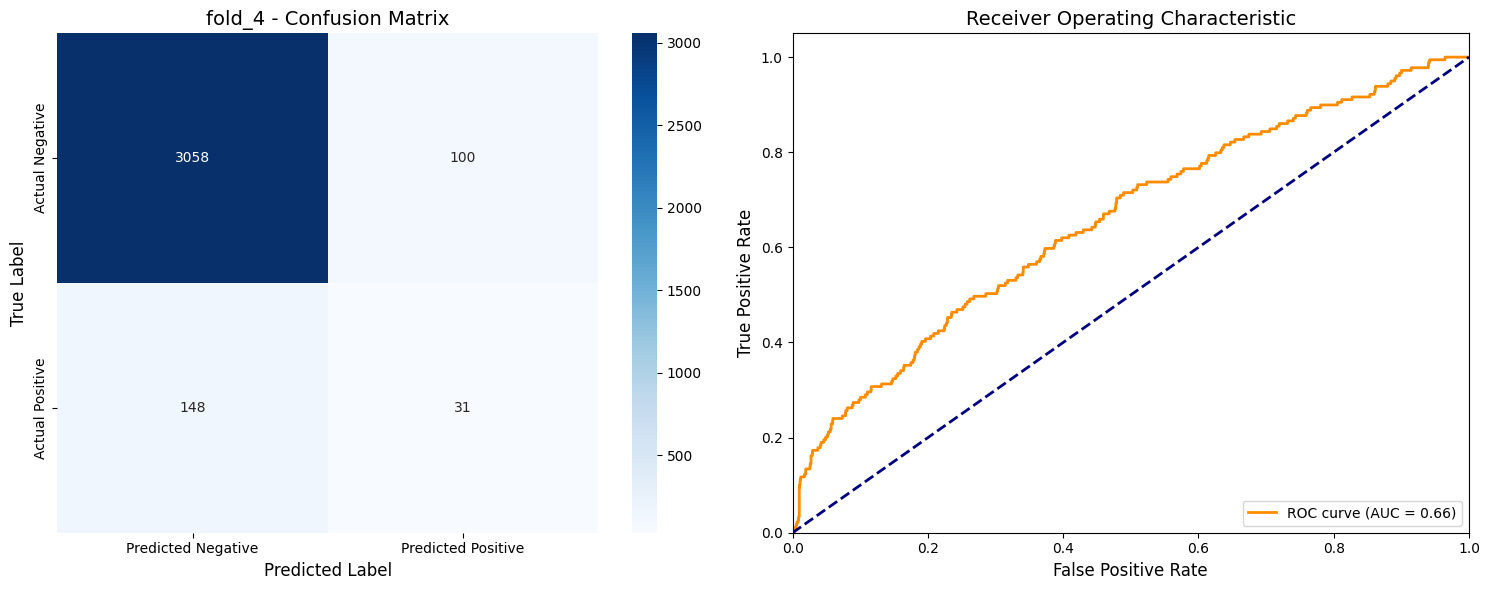


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6559
 F1 Score 0.5805
Precision 0.5952
   Recall 0.5708
 Accuracy 0.9257


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.236641 0.173184
Negative   0.953837 0.968334


🌀 Fold 5/5


Training fold 5:   2%|███                                                                                                                                                       | 1/50 [00:19<15:32, 19.03s/it]

  Epoch 1/50 | Loss: 0.4352


Training fold 5:   4%|██████▏                                                                                                                                                   | 2/50 [00:38<15:13, 19.04s/it]

  Epoch 2/50 | Loss: 0.4024


Training fold 5:   6%|█████████▏                                                                                                                                                | 3/50 [00:56<14:52, 18.98s/it]

  Epoch 3/50 | Loss: 0.3887


Training fold 5:   8%|████████████▎                                                                                                                                             | 4/50 [01:16<14:35, 19.03s/it]

  Epoch 4/50 | Loss: 0.3763


Training fold 5:  10%|███████████████▍                                                                                                                                          | 5/50 [01:35<14:17, 19.06s/it]

  Epoch 5/50 | Loss: 0.3608


Training fold 5:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:54<13:58, 19.06s/it]

  Epoch 6/50 | Loss: 0.3430


Training fold 5:  14%|█████████████████████▌                                                                                                                                    | 7/50 [02:13<13:40, 19.08s/it]

  Epoch 7/50 | Loss: 0.3311


Training fold 5:  16%|████████████████████████▋                                                                                                                                 | 8/50 [02:32<13:22, 19.10s/it]

  Epoch 8/50 | Loss: 0.3074


Training fold 5:  18%|███████████████████████████▋                                                                                                                              | 9/50 [02:51<13:04, 19.14s/it]

  Epoch 9/50 | Loss: 0.2895


Training fold 5:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [03:10<12:46, 19.16s/it]

  Epoch 10/50 | Loss: 0.2720


Training fold 5:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [03:30<12:26, 19.14s/it]

  Epoch 11/50 | Loss: 0.2474


Training fold 5:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [03:49<12:07, 19.13s/it]

  Epoch 12/50 | Loss: 0.2360


Training fold 5:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [04:08<11:48, 19.14s/it]

  Epoch 13/50 | Loss: 0.2169


Training fold 5:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [04:27<11:29, 19.14s/it]

  Epoch 14/50 | Loss: 0.2056


Training fold 5:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [04:46<11:10, 19.15s/it]

  Epoch 15/50 | Loss: 0.1841


Training fold 5:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [05:05<10:49, 19.10s/it]

  Epoch 16/50 | Loss: 0.1701


Training fold 5:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [05:24<10:26, 18.97s/it]

  Epoch 17/50 | Loss: 0.1568


Training fold 5:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [05:43<10:06, 18.96s/it]

  Epoch 18/50 | Loss: 0.1425


Training fold 5:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [06:02<09:47, 18.94s/it]

  Epoch 19/50 | Loss: 0.1429


Training fold 5:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [06:20<09:25, 18.85s/it]

  Epoch 20/50 | Loss: 0.1309


Training fold 5:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [06:39<09:07, 18.89s/it]

  Epoch 21/50 | Loss: 0.1234


Training fold 5:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [06:58<08:46, 18.82s/it]

  Epoch 22/50 | Loss: 0.1159


Training fold 5:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [07:16<08:26, 18.75s/it]

  Epoch 23/50 | Loss: 0.1122


Training fold 5:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [07:35<08:06, 18.70s/it]

  Epoch 24/50 | Loss: 0.1138


Training fold 5:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [07:54<07:46, 18.66s/it]

  Epoch 25/50 | Loss: 0.1106


Training fold 5:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [08:12<07:27, 18.65s/it]

  Epoch 26/50 | Loss: 0.1034


Training fold 5:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [08:31<07:08, 18.64s/it]

  Epoch 27/50 | Loss: 0.0996


Training fold 5:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [08:50<06:50, 18.68s/it]

  Epoch 28/50 | Loss: 0.0948


Training fold 5:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [09:08<06:32, 18.69s/it]

  Epoch 29/50 | Loss: 0.0891


Training fold 5:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [09:27<06:14, 18.73s/it]

  Epoch 30/50 | Loss: 0.0891


Training fold 5:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [09:46<05:55, 18.73s/it]

  Epoch 31/50 | Loss: 0.0891


Training fold 5:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [10:05<05:37, 18.75s/it]

  Epoch 32/50 | Loss: 0.0841


Training fold 5:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [10:23<05:18, 18.76s/it]

  Epoch 33/50 | Loss: 0.0793


Training fold 5:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [10:42<04:59, 18.74s/it]

  Epoch 34/50 | Loss: 0.0792


Training fold 5:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [11:01<04:41, 18.79s/it]

  Epoch 35/50 | Loss: 0.0838


Training fold 5:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [11:20<04:22, 18.74s/it]

  Epoch 36/50 | Loss: 0.0768


Training fold 5:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [11:39<04:04, 18.81s/it]

  Epoch 37/50 | Loss: 0.0763


Training fold 5:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [11:58<03:46, 18.89s/it]

  Epoch 38/50 | Loss: 0.0744


Training fold 5:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [12:17<03:27, 18.91s/it]

  Epoch 39/50 | Loss: 0.0724


Training fold 5:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [12:36<03:09, 18.93s/it]

  Epoch 40/50 | Loss: 0.0713


Training fold 5:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [12:55<02:50, 18.92s/it]

  Epoch 41/50 | Loss: 0.0749


Training fold 5:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [13:14<02:31, 18.92s/it]

  Epoch 42/50 | Loss: 0.0688


Training fold 5:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [13:32<02:12, 18.92s/it]

  Epoch 43/50 | Loss: 0.0649


Training fold 5:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [13:52<01:53, 18.98s/it]

  Epoch 44/50 | Loss: 0.0647


Training fold 5:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [14:10<01:34, 18.94s/it]

  Epoch 45/50 | Loss: 0.0715


Training fold 5:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [14:29<01:15, 18.91s/it]

  Epoch 46/50 | Loss: 0.0779


Training fold 5:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [14:48<00:56, 18.88s/it]

  Epoch 47/50 | Loss: 0.0747


Training fold 5:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [15:07<00:37, 18.86s/it]

  Epoch 48/50 | Loss: 0.0623


Training fold 5:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [15:26<00:18, 18.83s/it]

  Epoch 49/50 | Loss: 0.0556


Training fold 5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [15:44<00:00, 18.90s/it]


  Epoch 50/50 | Loss: 0.0558


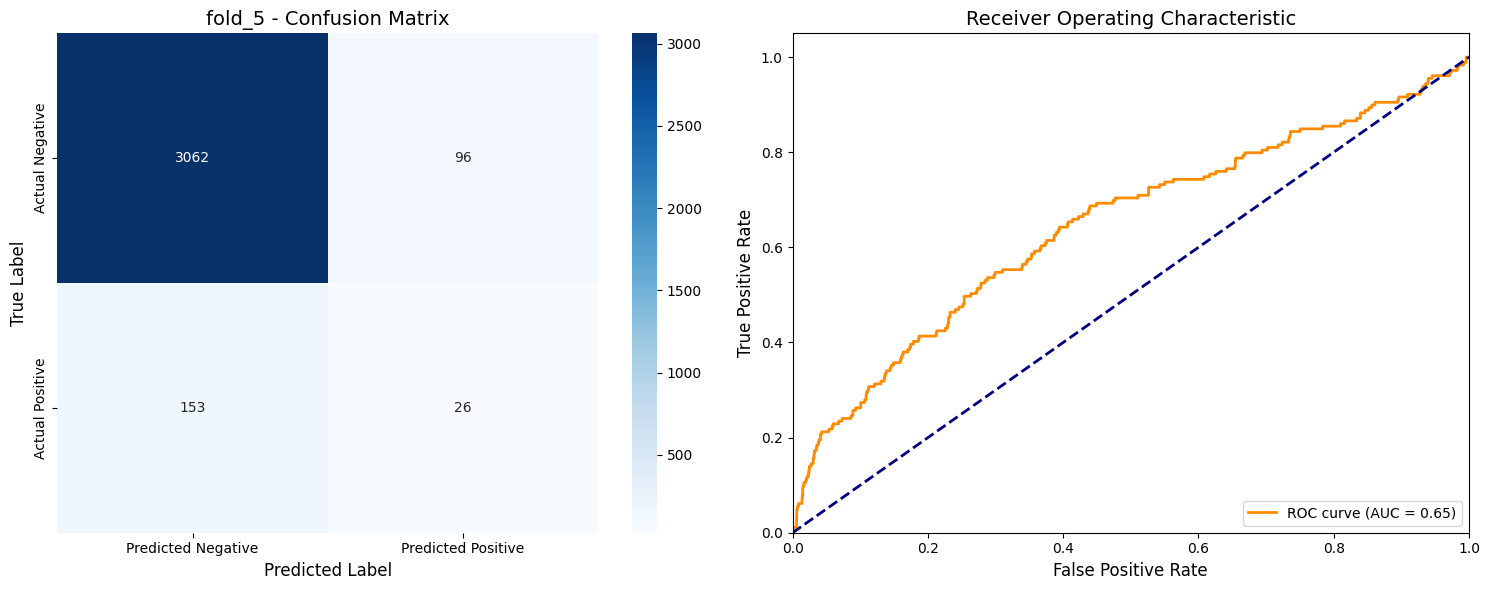


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6453
 F1 Score 0.5668
Precision 0.5828
   Recall 0.5574
 Accuracy 0.9254


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.213115 0.145251
Negative   0.952411 0.969601



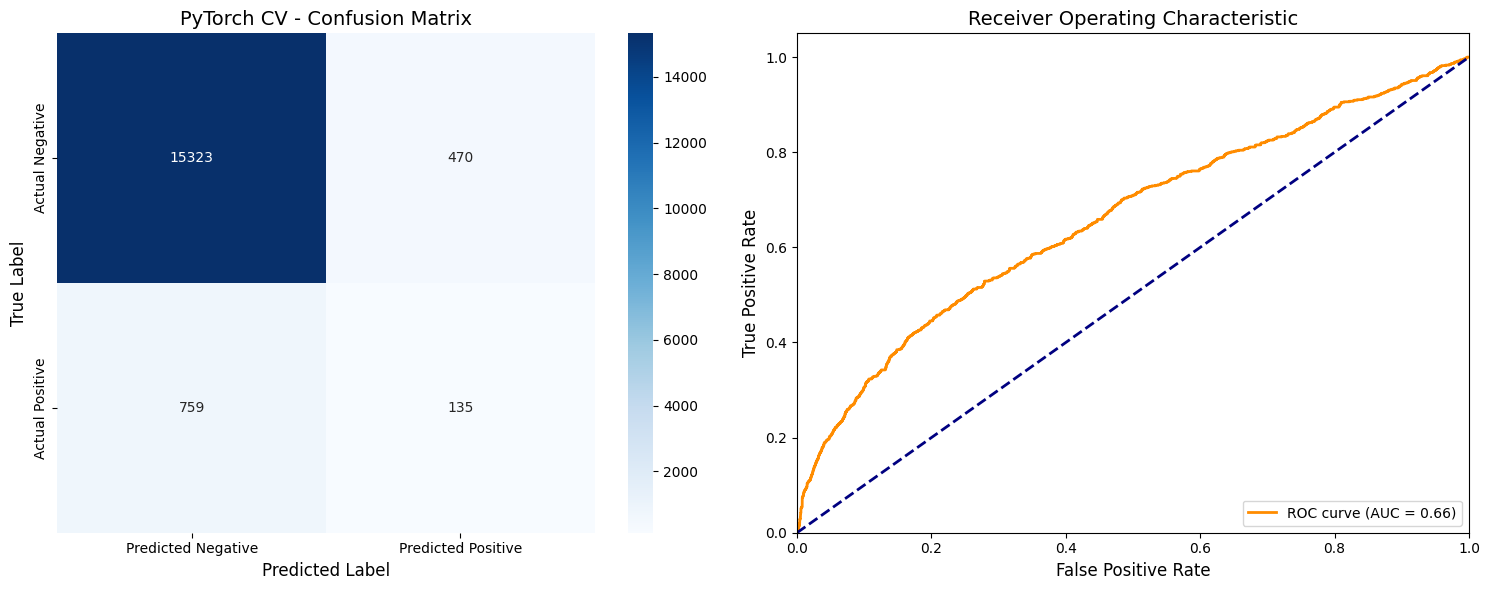

CPU times: user 1h 6min 5s, sys: 10min 25s, total: 1h 16min 30s
Wall time: 1h 18min 57s


ClassificationMetrics(name='RNN', training_time=4729.060570250998, estimators=[{'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': RNNForHallucinationDetection(
  (embedding): Embedding(35965, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (rnn): RNN(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': RNNForHallucinationDetection(
  (embedding): Embedding(35965, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (rnn): RNN(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': RNNForHallucinationDetection(
  (embedding): Embedding(35965, 256

In [ ]:
%%time

rnn_metrics = cross_validate_model(
    model=rnn_model,
    X=data_nn['description'],
    y=data_nn['category_id'],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='RNN'
)

rnn_metrics

Подготовим тестовые данные и совершим прогноз на них

In [42]:
test_data_nn = test_data.copy()
test_data_nn.sample(5)

,Id,Prompt,Answer
1018,26385,"[[, inst, ], you, are, a, helpful, assistant, ...","[the, federal, reserve, admitted, to, getting,..."
7987,4874,"[[, inst, ], you, are, an, ai, assistant, that...","[ai, :, why, did, mike, not, drive, his, car, ..."
9512,2134,"[[, inst, ], you, are, an, ai, assistant, ., y...","[a, way, to, be, heard, ;, b, ):, a, way, to, ..."
5732,6504,"[question, :, given, the, question, :, what, t...","[the, bio, provides, details, about, flo, rent..."
5052,27227,"[question, :, answer, the, following, question...",[artist]


In [43]:
test_data_nn.loc[test_data_nn['Answer'].notna(), 'Answer'] = \
    test_data_nn.loc[test_data_nn['Answer'].notna(), 'Answer'].apply(lambda x: ['[RL]'] + x)


test_data_nn.drop(columns=['Id'], inplace=True)

test_data_nn['Input'] = test_data_nn['Prompt'] + test_data_nn['Answer']

test_data_nn.drop(columns=['Prompt', 'Answer'], inplace=True)

test_data_nn.sample(5)

,Input
5245,"[[, inst, ], you, should, describe, the, task,..."
4641,"[[, inst, ], you, are, an, ai, assistant, ., u..."
4284,"[[, inst, ], you, are, an, ai, assistant, ., p..."
4721,"[[, inst, ], you, are, an, ai, assistant, that..."
4756,"[[, inst, ], you, are, an, ai, assistant, ., p..."


In [44]:
result = predict_with_ensemble(rnn_metrics.estimators, test_data_nn['Input'], device, 256)
rnn_predictions = result[1]
rnn_predictions

Predicting ensemble: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87/87 [00:56<00:00,  1.54it/s]


array([1.2201880e-04, 2.6126474e-03, 1.0705413e-04, ..., 7.8304191e-05,
       9.8454999e-05, 9.3298487e-04], shape=(11125,), dtype=float32)

In [45]:
rnn_submission = build_submission_dataframe(test_data=test_data, id_column="Id", 
                                            target_column="Target", predictions=rnn_predictions)

rnn_submission.head(5)

,Id,Target
0,20568,0.000122
1,17686,0.002613
2,13035,0.000107
3,22646,0.000006
4,5535,0.000085


In [46]:
rnn_submission.to_csv(f"{data_path}/rnn_submission.csv", index=False)

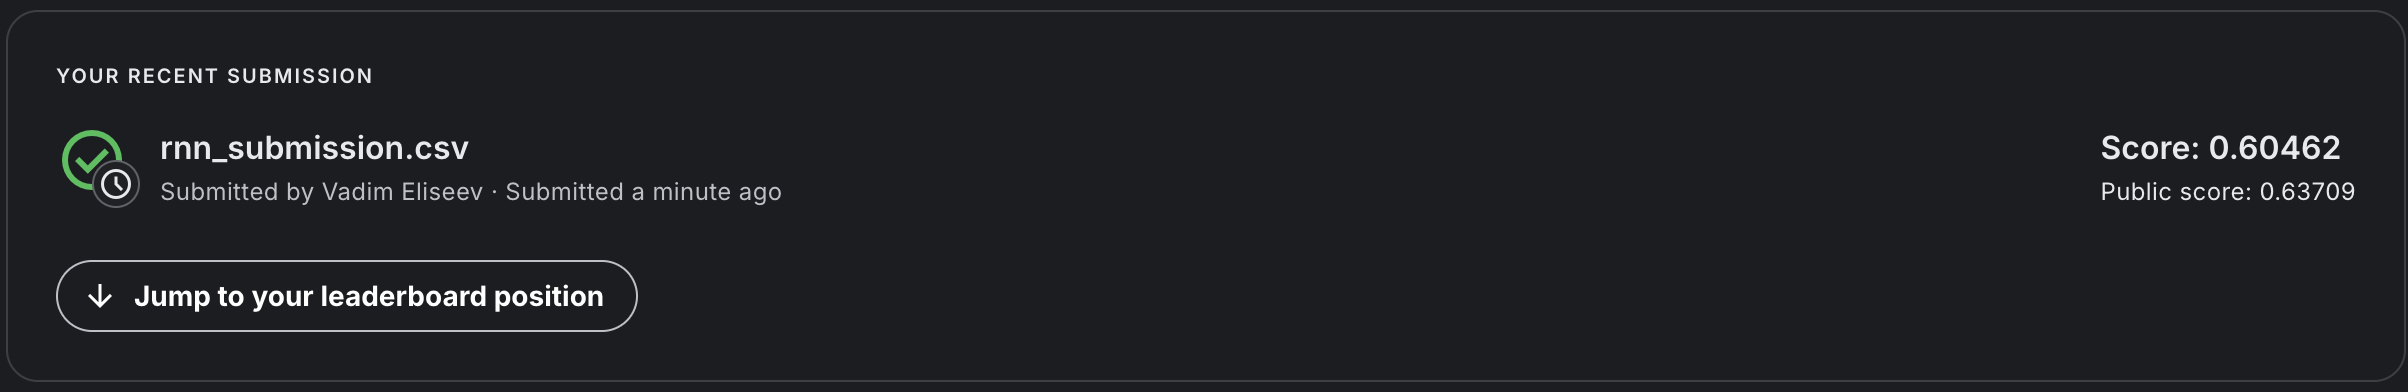

Видим что RNN справилась значительно хуже базового алгоритма. Проверим другие архитектуры

In [47]:
free_memory()

## CNN (Сверточная нейронная сеть)

CNN применяет сверточные фильтры к последовательности токенов, выявляя локальные паттерны. GlobalMaxPooling1D выбирает наиболее важные признаки из всей последовательности. CNN часто работают быстрее RNN и могут выявлять n-граммы эффективнее.

Определим гиперпараметры CNN

In [48]:
BATCH_SIZE = 128
EMBEDDING_DIM = 512
FILTERS = 10
KERNEL_SIZE = 3

Построим модель

In [49]:
cnn_model = CNNForHallucinationDetection(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    num_filters=FILTERS,
    kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id
).to(device)

cnn_model

CNNForHallucinationDetection(
  (embedding): Embedding(35965, 512)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(512, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)

In [50]:
print(f"Сверточная модель содержит число параметров: {count_parameters(cnn_model)}")

Сверточная модель содержит число параметров: 18429461


Запустим процесс обучения


🌀 Fold 1/5


Training fold 1:   2%|███                                                                                                                                                       | 1/50 [00:03<02:53,  3.55s/it]

  Epoch 1/50 | Loss: 0.4056


Training fold 1:   4%|██████▏                                                                                                                                                   | 2/50 [00:07<02:50,  3.55s/it]

  Epoch 2/50 | Loss: 0.3666


Training fold 1:   6%|█████████▏                                                                                                                                                | 3/50 [00:10<02:44,  3.51s/it]

  Epoch 3/50 | Loss: 0.3423


Training fold 1:   8%|████████████▎                                                                                                                                             | 4/50 [00:14<02:40,  3.49s/it]

  Epoch 4/50 | Loss: 0.3258


Training fold 1:  10%|███████████████▍                                                                                                                                          | 5/50 [00:17<02:36,  3.48s/it]

  Epoch 5/50 | Loss: 0.3114


Training fold 1:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:20<02:33,  3.48s/it]

  Epoch 6/50 | Loss: 0.2983


Training fold 1:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:24<02:29,  3.47s/it]

  Epoch 7/50 | Loss: 0.2885


Training fold 1:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:27<02:26,  3.48s/it]

  Epoch 8/50 | Loss: 0.2752


Training fold 1:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:31<02:22,  3.47s/it]

  Epoch 9/50 | Loss: 0.2742


Training fold 1:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:34<02:19,  3.49s/it]

  Epoch 10/50 | Loss: 0.2612


Training fold 1:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:38<02:15,  3.48s/it]

  Epoch 11/50 | Loss: 0.2471


Training fold 1:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:41<02:12,  3.48s/it]

  Epoch 12/50 | Loss: 0.2394


Training fold 1:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:45<02:08,  3.48s/it]

  Epoch 13/50 | Loss: 0.2316


Training fold 1:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:48<02:05,  3.48s/it]

  Epoch 14/50 | Loss: 0.2225


Training fold 1:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:52<02:01,  3.47s/it]

  Epoch 15/50 | Loss: 0.2095


Training fold 1:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:55<01:58,  3.48s/it]

  Epoch 16/50 | Loss: 0.2010


Training fold 1:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [00:59<01:54,  3.48s/it]

  Epoch 17/50 | Loss: 0.1915


Training fold 1:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [01:02<01:51,  3.48s/it]

  Epoch 18/50 | Loss: 0.1807


Training fold 1:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [01:06<01:47,  3.48s/it]

  Epoch 19/50 | Loss: 0.1746


Training fold 1:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [01:09<01:44,  3.49s/it]

  Epoch 20/50 | Loss: 0.1632


Training fold 1:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [01:13<01:41,  3.50s/it]

  Epoch 21/50 | Loss: 0.1526


Training fold 1:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [01:16<01:37,  3.50s/it]

  Epoch 22/50 | Loss: 0.1451


Training fold 1:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [01:20<01:34,  3.51s/it]

  Epoch 23/50 | Loss: 0.1297


Training fold 1:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [01:23<01:31,  3.50s/it]

  Epoch 24/50 | Loss: 0.1242


Training fold 1:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [01:27<01:27,  3.50s/it]

  Epoch 25/50 | Loss: 0.1156


Training fold 1:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [01:30<01:24,  3.50s/it]

  Epoch 26/50 | Loss: 0.1065


Training fold 1:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [01:34<01:20,  3.51s/it]

  Epoch 27/50 | Loss: 0.1016


Training fold 1:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [01:37<01:17,  3.52s/it]

  Epoch 28/50 | Loss: 0.0926


Training fold 1:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [01:41<01:14,  3.53s/it]

  Epoch 29/50 | Loss: 0.0888


Training fold 1:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [01:44<01:10,  3.54s/it]

  Epoch 30/50 | Loss: 0.0820


Training fold 1:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [01:48<01:07,  3.56s/it]

  Epoch 31/50 | Loss: 0.0778


Training fold 1:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [01:52<01:04,  3.60s/it]

  Epoch 32/50 | Loss: 0.0701


Training fold 1:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [01:55<01:01,  3.64s/it]

  Epoch 33/50 | Loss: 0.0657


Training fold 1:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [01:59<00:58,  3.69s/it]

  Epoch 34/50 | Loss: 0.0636


Training fold 1:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [02:03<00:55,  3.72s/it]

  Epoch 35/50 | Loss: 0.0600


Training fold 1:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [02:07<00:52,  3.77s/it]

  Epoch 36/50 | Loss: 0.0564


Training fold 1:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [02:11<00:50,  3.87s/it]

  Epoch 37/50 | Loss: 0.0537


Training fold 1:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [02:15<00:46,  3.91s/it]

  Epoch 38/50 | Loss: 0.0518


Training fold 1:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [02:19<00:43,  3.95s/it]

  Epoch 39/50 | Loss: 0.0478


Training fold 1:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [02:23<00:40,  4.05s/it]

  Epoch 40/50 | Loss: 0.0468


Training fold 1:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [02:28<00:36,  4.08s/it]

  Epoch 41/50 | Loss: 0.0426


Training fold 1:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [02:32<00:32,  4.11s/it]

  Epoch 42/50 | Loss: 0.0442


Training fold 1:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [02:36<00:28,  4.14s/it]

  Epoch 43/50 | Loss: 0.0389


Training fold 1:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [02:40<00:24,  4.15s/it]

  Epoch 44/50 | Loss: 0.0374


Training fold 1:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [02:44<00:20,  4.16s/it]

  Epoch 45/50 | Loss: 0.0383


Training fold 1:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [02:48<00:16,  4.17s/it]

  Epoch 46/50 | Loss: 0.0364


Training fold 1:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [02:53<00:12,  4.18s/it]

  Epoch 47/50 | Loss: 0.0347


Training fold 1:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [02:57<00:08,  4.19s/it]

  Epoch 48/50 | Loss: 0.0316


Training fold 1:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [03:01<00:04,  4.20s/it]

  Epoch 49/50 | Loss: 0.0300


Training fold 1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [03:05<00:00,  3.71s/it]


  Epoch 50/50 | Loss: 0.0298


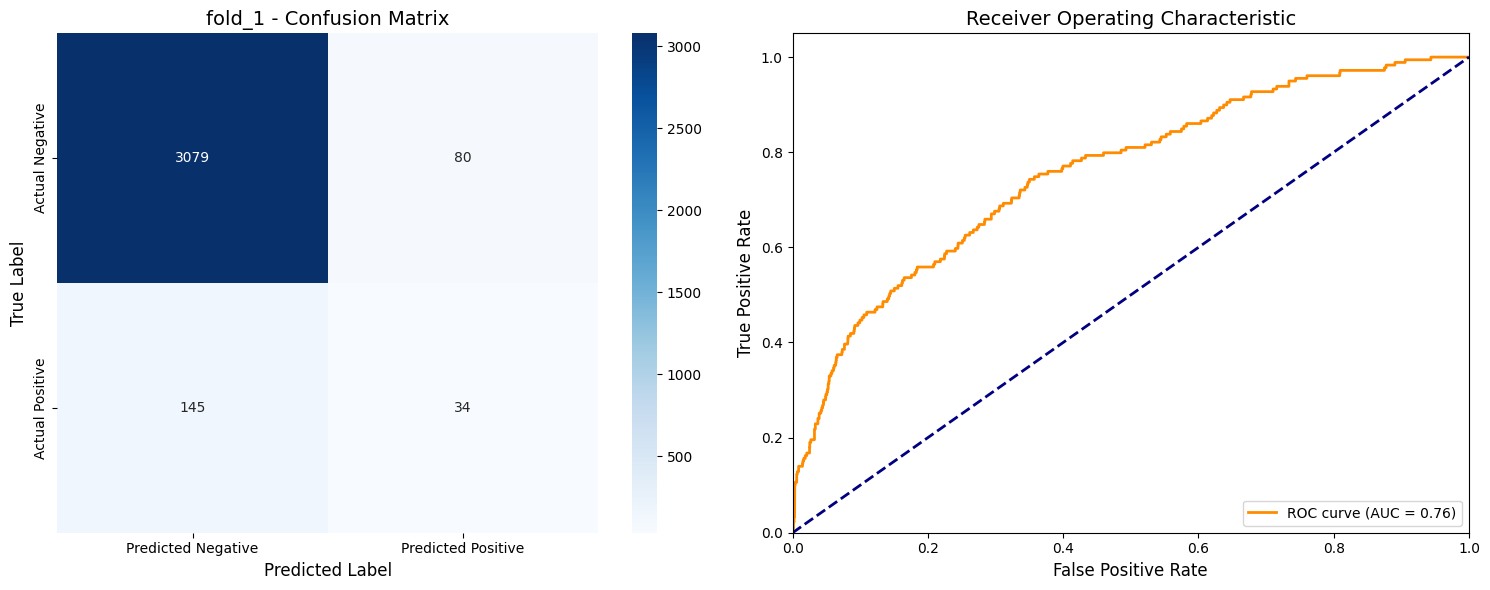


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7579
 F1 Score 0.5984
Precision 0.6266
   Recall 0.5823
 Accuracy 0.9326


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.298246 0.189944
Negative   0.955025 0.974676


🌀 Fold 2/5


Training fold 2:   2%|███                                                                                                                                                       | 1/50 [00:03<03:05,  3.78s/it]

  Epoch 1/50 | Loss: 0.4087


Training fold 2:   4%|██████▏                                                                                                                                                   | 2/50 [00:08<03:17,  4.10s/it]

  Epoch 2/50 | Loss: 0.3823


Training fold 2:   6%|█████████▏                                                                                                                                                | 3/50 [00:12<03:12,  4.10s/it]

  Epoch 3/50 | Loss: 0.3554


Training fold 2:   8%|████████████▎                                                                                                                                             | 4/50 [00:16<03:09,  4.11s/it]

  Epoch 4/50 | Loss: 0.3331


Training fold 2:  10%|███████████████▍                                                                                                                                          | 5/50 [00:20<03:03,  4.08s/it]

  Epoch 5/50 | Loss: 0.3185


Training fold 2:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:24<02:58,  4.07s/it]

  Epoch 6/50 | Loss: 0.3074


Training fold 2:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:28<02:53,  4.04s/it]

  Epoch 7/50 | Loss: 0.2913


Training fold 2:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:32<02:48,  4.01s/it]

  Epoch 8/50 | Loss: 0.2810


Training fold 2:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:36<02:43,  3.99s/it]

  Epoch 9/50 | Loss: 0.2748


Training fold 2:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:40<02:38,  3.97s/it]

  Epoch 10/50 | Loss: 0.2618


Training fold 2:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:44<02:33,  3.95s/it]

  Epoch 11/50 | Loss: 0.2491


Training fold 2:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:47<02:29,  3.93s/it]

  Epoch 12/50 | Loss: 0.2418


Training fold 2:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:51<02:23,  3.89s/it]

  Epoch 13/50 | Loss: 0.2311


Training fold 2:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:55<02:18,  3.86s/it]

  Epoch 14/50 | Loss: 0.2191


Training fold 2:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:59<02:14,  3.84s/it]

  Epoch 15/50 | Loss: 0.2047


Training fold 2:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [01:03<02:09,  3.82s/it]

  Epoch 16/50 | Loss: 0.1980


Training fold 2:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [01:06<02:05,  3.80s/it]

  Epoch 17/50 | Loss: 0.1833


Training fold 2:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [01:10<02:00,  3.78s/it]

  Epoch 18/50 | Loss: 0.1760


Training fold 2:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [01:14<01:56,  3.77s/it]

  Epoch 19/50 | Loss: 0.1648


Training fold 2:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [01:18<01:52,  3.76s/it]

  Epoch 20/50 | Loss: 0.1522


Training fold 2:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [01:21<01:48,  3.74s/it]

  Epoch 21/50 | Loss: 0.1477


Training fold 2:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [01:25<01:44,  3.73s/it]

  Epoch 22/50 | Loss: 0.1364


Training fold 2:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [01:29<01:40,  3.72s/it]

  Epoch 23/50 | Loss: 0.1260


Training fold 2:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [01:32<01:36,  3.72s/it]

  Epoch 24/50 | Loss: 0.1188


Training fold 2:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [01:36<01:32,  3.72s/it]

  Epoch 25/50 | Loss: 0.1084


Training fold 2:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [01:40<01:28,  3.71s/it]

  Epoch 26/50 | Loss: 0.1039


Training fold 2:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [01:43<01:25,  3.70s/it]

  Epoch 27/50 | Loss: 0.0943


Training fold 2:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [01:47<01:21,  3.69s/it]

  Epoch 28/50 | Loss: 0.0869


Training fold 2:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [01:51<01:17,  3.68s/it]

  Epoch 29/50 | Loss: 0.0827


Training fold 2:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [01:55<01:13,  3.69s/it]

  Epoch 30/50 | Loss: 0.0766


Training fold 2:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [01:58<01:09,  3.68s/it]

  Epoch 31/50 | Loss: 0.0718


Training fold 2:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [02:02<01:06,  3.67s/it]

  Epoch 32/50 | Loss: 0.0651


Training fold 2:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [02:06<01:02,  3.67s/it]

  Epoch 33/50 | Loss: 0.0653


Training fold 2:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [02:09<00:58,  3.66s/it]

  Epoch 34/50 | Loss: 0.0612


Training fold 2:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [02:13<00:54,  3.65s/it]

  Epoch 35/50 | Loss: 0.0568


Training fold 2:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [02:16<00:51,  3.65s/it]

  Epoch 36/50 | Loss: 0.0543


Training fold 2:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [02:20<00:47,  3.64s/it]

  Epoch 37/50 | Loss: 0.0514


Training fold 2:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [02:24<00:43,  3.64s/it]

  Epoch 38/50 | Loss: 0.0486


Training fold 2:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [02:27<00:39,  3.63s/it]

  Epoch 39/50 | Loss: 0.0457


Training fold 2:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [02:31<00:36,  3.62s/it]

  Epoch 40/50 | Loss: 0.0425


Training fold 2:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [02:34<00:32,  3.62s/it]

  Epoch 41/50 | Loss: 0.0416


Training fold 2:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [02:38<00:29,  3.63s/it]

  Epoch 42/50 | Loss: 0.0394


Training fold 2:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [02:42<00:25,  3.62s/it]

  Epoch 43/50 | Loss: 0.0370


Training fold 2:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [02:45<00:21,  3.63s/it]

  Epoch 44/50 | Loss: 0.0359


Training fold 2:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [02:49<00:18,  3.63s/it]

  Epoch 45/50 | Loss: 0.0357


Training fold 2:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [02:53<00:14,  3.62s/it]

  Epoch 46/50 | Loss: 0.0342


Training fold 2:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [02:56<00:10,  3.62s/it]

  Epoch 47/50 | Loss: 0.0319


Training fold 2:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [03:00<00:07,  3.62s/it]

  Epoch 48/50 | Loss: 0.0302


Training fold 2:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [03:03<00:03,  3.62s/it]

  Epoch 49/50 | Loss: 0.0306


Training fold 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [03:07<00:00,  3.75s/it]


  Epoch 50/50 | Loss: 0.0307


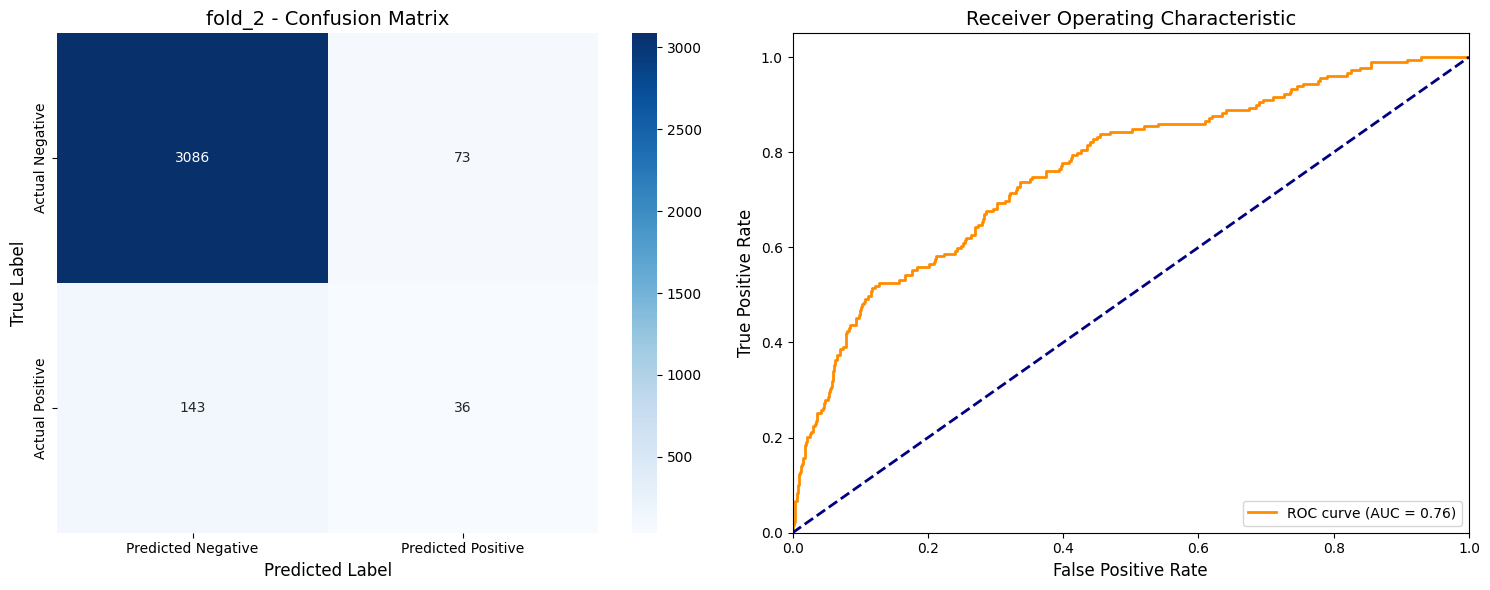


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7634
 F1 Score 0.6081
Precision 0.6430
   Recall 0.5890
 Accuracy 0.9353


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.330275 0.201117
Negative   0.955714 0.976891


🌀 Fold 3/5


Training fold 3:   2%|███                                                                                                                                                       | 1/50 [00:03<02:56,  3.60s/it]

  Epoch 1/50 | Loss: 0.4090


Training fold 3:   4%|██████▏                                                                                                                                                   | 2/50 [00:07<02:52,  3.60s/it]

  Epoch 2/50 | Loss: 0.3740


Training fold 3:   6%|█████████▏                                                                                                                                                | 3/50 [00:10<02:49,  3.60s/it]

  Epoch 3/50 | Loss: 0.3507


Training fold 3:   8%|████████████▎                                                                                                                                             | 4/50 [00:14<02:45,  3.61s/it]

  Epoch 4/50 | Loss: 0.3296


Training fold 3:  10%|███████████████▍                                                                                                                                          | 5/50 [00:18<02:42,  3.61s/it]

  Epoch 5/50 | Loss: 0.3154


Training fold 3:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:21<02:39,  3.61s/it]

  Epoch 6/50 | Loss: 0.3045


Training fold 3:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:25<02:34,  3.60s/it]

  Epoch 7/50 | Loss: 0.2858


Training fold 3:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:28<02:31,  3.60s/it]

  Epoch 8/50 | Loss: 0.2768


Training fold 3:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:32<02:27,  3.59s/it]

  Epoch 9/50 | Loss: 0.2620


Training fold 3:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:35<02:23,  3.59s/it]

  Epoch 10/50 | Loss: 0.2473


Training fold 3:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:39<02:19,  3.59s/it]

  Epoch 11/50 | Loss: 0.2334


Training fold 3:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:43<02:16,  3.59s/it]

  Epoch 12/50 | Loss: 0.2214


Training fold 3:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:46<02:12,  3.59s/it]

  Epoch 13/50 | Loss: 0.2145


Training fold 3:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:50<02:09,  3.60s/it]

  Epoch 14/50 | Loss: 0.2003


Training fold 3:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:53<02:05,  3.59s/it]

  Epoch 15/50 | Loss: 0.1880


Training fold 3:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:57<02:02,  3.60s/it]

  Epoch 16/50 | Loss: 0.1769


Training fold 3:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [01:01<01:58,  3.59s/it]

  Epoch 17/50 | Loss: 0.1676


Training fold 3:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [01:04<01:55,  3.59s/it]

  Epoch 18/50 | Loss: 0.1536


Training fold 3:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [01:08<01:51,  3.60s/it]

  Epoch 19/50 | Loss: 0.1441


Training fold 3:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [01:11<01:47,  3.60s/it]

  Epoch 20/50 | Loss: 0.1330


Training fold 3:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [01:15<01:44,  3.59s/it]

  Epoch 21/50 | Loss: 0.1260


Training fold 3:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [01:19<01:40,  3.60s/it]

  Epoch 22/50 | Loss: 0.1165


Training fold 3:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [01:22<01:36,  3.59s/it]

  Epoch 23/50 | Loss: 0.1084


Training fold 3:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [01:26<01:33,  3.59s/it]

  Epoch 24/50 | Loss: 0.1011


Training fold 3:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [01:29<01:29,  3.59s/it]

  Epoch 25/50 | Loss: 0.0941


Training fold 3:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [01:33<01:26,  3.59s/it]

  Epoch 26/50 | Loss: 0.0872


Training fold 3:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [01:37<01:22,  3.60s/it]

  Epoch 27/50 | Loss: 0.0823


Training fold 3:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [01:40<01:19,  3.60s/it]

  Epoch 28/50 | Loss: 0.0779


Training fold 3:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [01:44<01:15,  3.60s/it]

  Epoch 29/50 | Loss: 0.0747


Training fold 3:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [01:47<01:12,  3.61s/it]

  Epoch 30/50 | Loss: 0.0695


Training fold 3:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [01:51<01:08,  3.60s/it]

  Epoch 31/50 | Loss: 0.0634


Training fold 3:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [01:55<01:04,  3.61s/it]

  Epoch 32/50 | Loss: 0.0591


Training fold 3:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [01:58<01:01,  3.62s/it]

  Epoch 33/50 | Loss: 0.0569


Training fold 3:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [02:02<00:57,  3.61s/it]

  Epoch 34/50 | Loss: 0.0534


Training fold 3:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [02:05<00:53,  3.60s/it]

  Epoch 35/50 | Loss: 0.0513


Training fold 3:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [02:09<00:50,  3.60s/it]

  Epoch 36/50 | Loss: 0.0486


Training fold 3:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [02:13<00:46,  3.59s/it]

  Epoch 37/50 | Loss: 0.0491


Training fold 3:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [02:16<00:43,  3.59s/it]

  Epoch 38/50 | Loss: 0.0449


Training fold 3:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [02:20<00:39,  3.59s/it]

  Epoch 39/50 | Loss: 0.0427


Training fold 3:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [02:23<00:35,  3.59s/it]

  Epoch 40/50 | Loss: 0.0404


Training fold 3:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [02:27<00:32,  3.59s/it]

  Epoch 41/50 | Loss: 0.0397


Training fold 3:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [02:31<00:28,  3.59s/it]

  Epoch 42/50 | Loss: 0.0376


Training fold 3:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [02:34<00:25,  3.58s/it]

  Epoch 43/50 | Loss: 0.0355


Training fold 3:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [02:38<00:21,  3.58s/it]

  Epoch 44/50 | Loss: 0.0360


Training fold 3:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [02:41<00:17,  3.58s/it]

  Epoch 45/50 | Loss: 0.0348


Training fold 3:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [02:45<00:14,  3.58s/it]

  Epoch 46/50 | Loss: 0.0327


Training fold 3:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [02:48<00:10,  3.58s/it]

  Epoch 47/50 | Loss: 0.0312


Training fold 3:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [02:52<00:07,  3.58s/it]

  Epoch 48/50 | Loss: 0.0293


Training fold 3:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [02:56<00:03,  3.59s/it]

  Epoch 49/50 | Loss: 0.0296


Training fold 3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:59<00:00,  3.59s/it]


  Epoch 50/50 | Loss: 0.0289


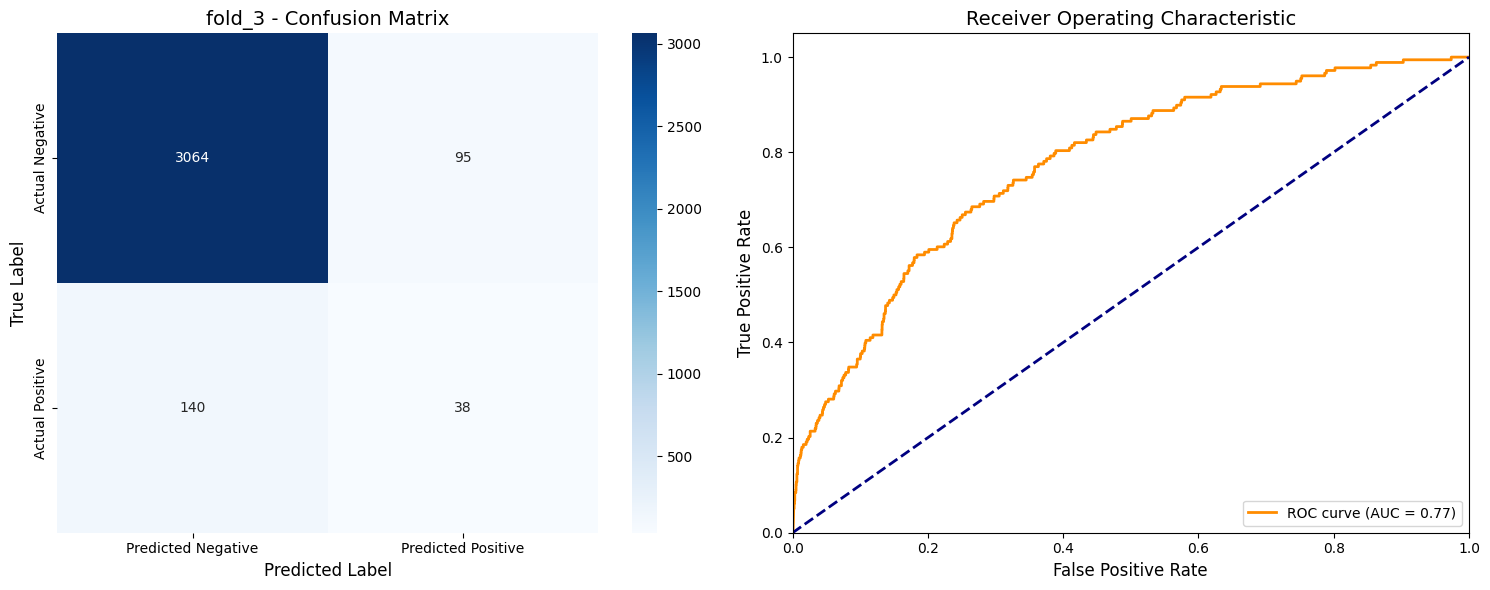


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7746
 F1 Score 0.6037
Precision 0.6210
   Recall 0.5917
 Accuracy 0.9296


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.285714 0.213483
Negative   0.956305 0.969927


🌀 Fold 4/5


Training fold 4:   2%|███                                                                                                                                                       | 1/50 [00:03<02:56,  3.60s/it]

  Epoch 1/50 | Loss: 0.4069


Training fold 4:   4%|██████▏                                                                                                                                                   | 2/50 [00:07<02:51,  3.58s/it]

  Epoch 2/50 | Loss: 0.3711


Training fold 4:   6%|█████████▏                                                                                                                                                | 3/50 [00:10<02:47,  3.57s/it]

  Epoch 3/50 | Loss: 0.3499


Training fold 4:   8%|████████████▎                                                                                                                                             | 4/50 [00:14<02:44,  3.57s/it]

  Epoch 4/50 | Loss: 0.3325


Training fold 4:  10%|███████████████▍                                                                                                                                          | 5/50 [00:17<02:40,  3.57s/it]

  Epoch 5/50 | Loss: 0.3191


Training fold 4:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:21<02:37,  3.57s/it]

  Epoch 6/50 | Loss: 0.2999


Training fold 4:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:25<02:33,  3.57s/it]

  Epoch 7/50 | Loss: 0.2897


Training fold 4:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:28<02:30,  3.58s/it]

  Epoch 8/50 | Loss: 0.2772


Training fold 4:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:32<02:26,  3.58s/it]

  Epoch 9/50 | Loss: 0.2689


Training fold 4:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:35<02:23,  3.58s/it]

  Epoch 10/50 | Loss: 0.2586


Training fold 4:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:39<02:19,  3.59s/it]

  Epoch 11/50 | Loss: 0.2484


Training fold 4:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:42<02:16,  3.59s/it]

  Epoch 12/50 | Loss: 0.2383


Training fold 4:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:46<02:12,  3.59s/it]

  Epoch 13/50 | Loss: 0.2295


Training fold 4:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:50<02:09,  3.59s/it]

  Epoch 14/50 | Loss: 0.2177


Training fold 4:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:53<02:05,  3.59s/it]

  Epoch 15/50 | Loss: 0.2117


Training fold 4:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:57<02:02,  3.60s/it]

  Epoch 16/50 | Loss: 0.1968


Training fold 4:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [01:00<01:58,  3.60s/it]

  Epoch 17/50 | Loss: 0.1882


Training fold 4:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [01:04<01:55,  3.60s/it]

  Epoch 18/50 | Loss: 0.1772


Training fold 4:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [01:08<01:51,  3.60s/it]

  Epoch 19/50 | Loss: 0.1708


Training fold 4:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [01:11<01:47,  3.59s/it]

  Epoch 20/50 | Loss: 0.1585


Training fold 4:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [01:15<01:44,  3.59s/it]

  Epoch 21/50 | Loss: 0.1481


Training fold 4:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [01:18<01:40,  3.59s/it]

  Epoch 22/50 | Loss: 0.1401


Training fold 4:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [01:22<01:36,  3.59s/it]

  Epoch 23/50 | Loss: 0.1323


Training fold 4:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [01:26<01:33,  3.59s/it]

  Epoch 24/50 | Loss: 0.1194


Training fold 4:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [01:29<01:29,  3.58s/it]

  Epoch 25/50 | Loss: 0.1105


Training fold 4:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [01:33<01:25,  3.58s/it]

  Epoch 26/50 | Loss: 0.1046


Training fold 4:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [01:36<01:22,  3.58s/it]

  Epoch 27/50 | Loss: 0.0988


Training fold 4:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [01:40<01:18,  3.58s/it]

  Epoch 28/50 | Loss: 0.0929


Training fold 4:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [01:43<01:15,  3.58s/it]

  Epoch 29/50 | Loss: 0.0835


Training fold 4:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [01:47<01:11,  3.58s/it]

  Epoch 30/50 | Loss: 0.0810


Training fold 4:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [01:51<01:07,  3.58s/it]

  Epoch 31/50 | Loss: 0.0735


Training fold 4:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [01:54<01:04,  3.58s/it]

  Epoch 32/50 | Loss: 0.0687


Training fold 4:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [01:58<01:00,  3.58s/it]

  Epoch 33/50 | Loss: 0.0646


Training fold 4:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [02:01<00:57,  3.58s/it]

  Epoch 34/50 | Loss: 0.0627


Training fold 4:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [02:05<00:53,  3.59s/it]

  Epoch 35/50 | Loss: 0.0594


Training fold 4:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [02:09<00:50,  3.59s/it]

  Epoch 36/50 | Loss: 0.0554


Training fold 4:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [02:12<00:46,  3.59s/it]

  Epoch 37/50 | Loss: 0.0513


Training fold 4:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [02:16<00:43,  3.59s/it]

  Epoch 38/50 | Loss: 0.0484


Training fold 4:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [02:19<00:39,  3.58s/it]

  Epoch 39/50 | Loss: 0.0485


Training fold 4:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [02:23<00:35,  3.58s/it]

  Epoch 40/50 | Loss: 0.0452


Training fold 4:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [02:26<00:32,  3.58s/it]

  Epoch 41/50 | Loss: 0.0437


Training fold 4:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [02:30<00:28,  3.58s/it]

  Epoch 42/50 | Loss: 0.0410


Training fold 4:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [02:34<00:25,  3.58s/it]

  Epoch 43/50 | Loss: 0.0400


Training fold 4:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [02:37<00:21,  3.58s/it]

  Epoch 44/50 | Loss: 0.0380


Training fold 4:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [02:41<00:17,  3.59s/it]

  Epoch 45/50 | Loss: 0.0361


Training fold 4:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [02:44<00:14,  3.59s/it]

  Epoch 46/50 | Loss: 0.0336


Training fold 4:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [02:48<00:10,  3.59s/it]

  Epoch 47/50 | Loss: 0.0338


Training fold 4:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [02:52<00:07,  3.59s/it]

  Epoch 48/50 | Loss: 0.0342


Training fold 4:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [02:55<00:03,  3.59s/it]

  Epoch 49/50 | Loss: 0.0331


Training fold 4: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:59<00:00,  3.58s/it]


  Epoch 50/50 | Loss: 0.0314


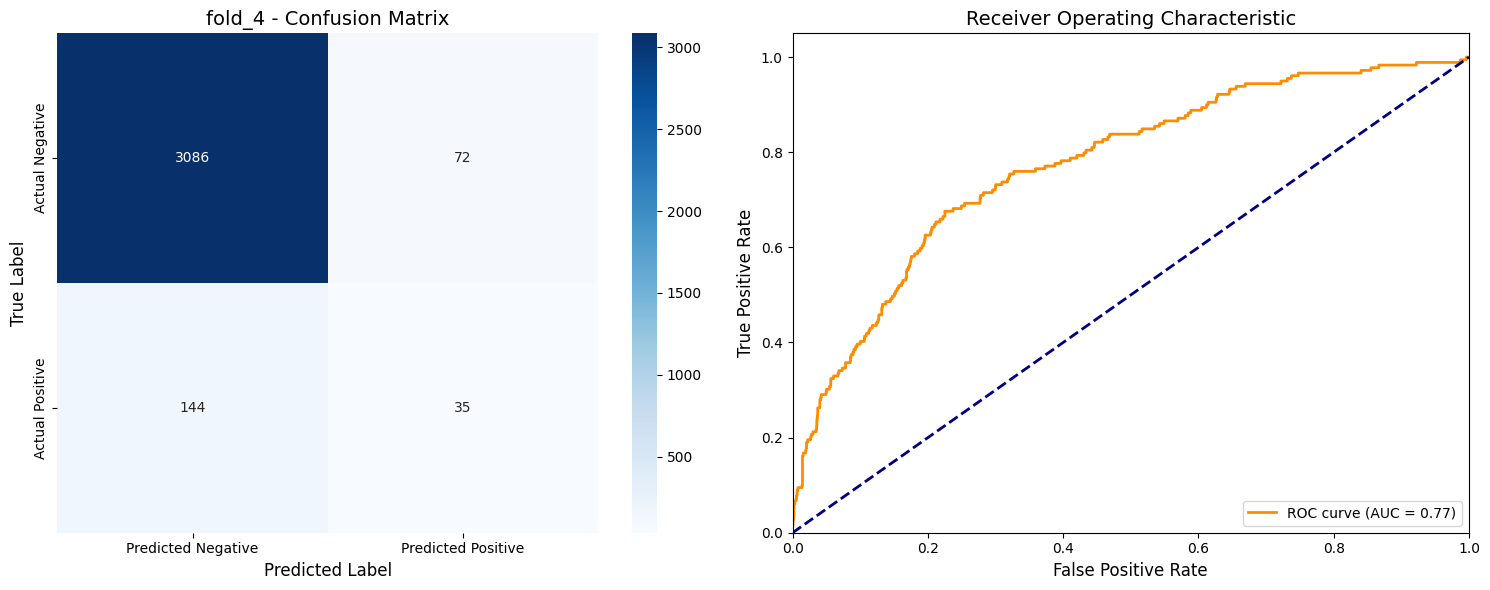


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7738
 F1 Score 0.6055
Precision 0.6413
   Recall 0.5864
 Accuracy 0.9353


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.327103 0.195531
Negative   0.955418 0.977201


🌀 Fold 5/5


Training fold 5:   2%|███                                                                                                                                                       | 1/50 [00:03<02:50,  3.48s/it]

  Epoch 1/50 | Loss: 0.4063


Training fold 5:   4%|██████▏                                                                                                                                                   | 2/50 [00:06<02:47,  3.49s/it]

  Epoch 2/50 | Loss: 0.3697


Training fold 5:   6%|█████████▏                                                                                                                                                | 3/50 [00:10<02:44,  3.49s/it]

  Epoch 3/50 | Loss: 0.3410


Training fold 5:   8%|████████████▎                                                                                                                                             | 4/50 [00:13<02:40,  3.50s/it]

  Epoch 4/50 | Loss: 0.3217


Training fold 5:  10%|███████████████▍                                                                                                                                          | 5/50 [00:17<02:37,  3.49s/it]

  Epoch 5/50 | Loss: 0.3007


Training fold 5:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:20<02:33,  3.48s/it]

  Epoch 6/50 | Loss: 0.2812


Training fold 5:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:24<02:29,  3.47s/it]

  Epoch 7/50 | Loss: 0.2657


Training fold 5:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:27<02:25,  3.47s/it]

  Epoch 8/50 | Loss: 0.2495


Training fold 5:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:31<02:22,  3.46s/it]

  Epoch 9/50 | Loss: 0.2386


Training fold 5:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:34<02:19,  3.48s/it]

  Epoch 10/50 | Loss: 0.2238


Training fold 5:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:38<02:15,  3.48s/it]

  Epoch 11/50 | Loss: 0.2110


Training fold 5:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:41<02:12,  3.48s/it]

  Epoch 12/50 | Loss: 0.2013


Training fold 5:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:45<02:08,  3.47s/it]

  Epoch 13/50 | Loss: 0.1901


Training fold 5:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:48<02:04,  3.46s/it]

  Epoch 14/50 | Loss: 0.1808


Training fold 5:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:52<02:01,  3.49s/it]

  Epoch 15/50 | Loss: 0.1686


Training fold 5:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:55<01:58,  3.48s/it]

  Epoch 16/50 | Loss: 0.1577


Training fold 5:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [00:59<01:55,  3.49s/it]

  Epoch 17/50 | Loss: 0.1459


Training fold 5:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [01:02<01:51,  3.49s/it]

  Epoch 18/50 | Loss: 0.1362


Training fold 5:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [01:06<01:48,  3.49s/it]

  Epoch 19/50 | Loss: 0.1250


Training fold 5:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [01:09<01:44,  3.49s/it]

  Epoch 20/50 | Loss: 0.1158


Training fold 5:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [01:13<01:41,  3.49s/it]

  Epoch 21/50 | Loss: 0.1089


Training fold 5:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [01:16<01:37,  3.48s/it]

  Epoch 22/50 | Loss: 0.1025


Training fold 5:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [01:20<01:33,  3.48s/it]

  Epoch 23/50 | Loss: 0.0926


Training fold 5:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [01:23<01:30,  3.48s/it]

  Epoch 24/50 | Loss: 0.0897


Training fold 5:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [01:27<01:26,  3.47s/it]

  Epoch 25/50 | Loss: 0.0815


Training fold 5:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [01:30<01:23,  3.47s/it]

  Epoch 26/50 | Loss: 0.0753


Training fold 5:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [01:33<01:19,  3.47s/it]

  Epoch 27/50 | Loss: 0.0734


Training fold 5:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [01:37<01:16,  3.47s/it]

  Epoch 28/50 | Loss: 0.0664


Training fold 5:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [01:40<01:12,  3.47s/it]

  Epoch 29/50 | Loss: 0.0612


Training fold 5:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [01:44<01:09,  3.47s/it]

  Epoch 30/50 | Loss: 0.0610


Training fold 5:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [01:47<01:05,  3.47s/it]

  Epoch 31/50 | Loss: 0.0556


Training fold 5:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [01:51<01:02,  3.47s/it]

  Epoch 32/50 | Loss: 0.0533


Training fold 5:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [01:54<00:59,  3.47s/it]

  Epoch 33/50 | Loss: 0.0480


Training fold 5:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [01:58<00:55,  3.47s/it]

  Epoch 34/50 | Loss: 0.0474


Training fold 5:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [02:01<00:52,  3.47s/it]

  Epoch 35/50 | Loss: 0.0459


Training fold 5:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [02:05<00:48,  3.47s/it]

  Epoch 36/50 | Loss: 0.0426


Training fold 5:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [02:08<00:45,  3.47s/it]

  Epoch 37/50 | Loss: 0.0395


Training fold 5:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [02:12<00:41,  3.47s/it]

  Epoch 38/50 | Loss: 0.0386


Training fold 5:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [02:15<00:38,  3.47s/it]

  Epoch 39/50 | Loss: 0.0375


Training fold 5:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [02:19<00:34,  3.47s/it]

  Epoch 40/50 | Loss: 0.0350


Training fold 5:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [02:22<00:31,  3.47s/it]

  Epoch 41/50 | Loss: 0.0335


Training fold 5:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [02:26<00:27,  3.47s/it]

  Epoch 42/50 | Loss: 0.0322


Training fold 5:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [02:29<00:24,  3.47s/it]

  Epoch 43/50 | Loss: 0.0313


Training fold 5:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [02:32<00:20,  3.46s/it]

  Epoch 44/50 | Loss: 0.0321


Training fold 5:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [02:36<00:17,  3.47s/it]

  Epoch 45/50 | Loss: 0.0295


Training fold 5:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [02:39<00:13,  3.47s/it]

  Epoch 46/50 | Loss: 0.0288


Training fold 5:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [02:43<00:10,  3.47s/it]

  Epoch 47/50 | Loss: 0.0273


Training fold 5:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [02:46<00:06,  3.47s/it]

  Epoch 48/50 | Loss: 0.0263


Training fold 5:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [02:50<00:03,  3.47s/it]

  Epoch 49/50 | Loss: 0.0251


Training fold 5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:53<00:00,  3.47s/it]


  Epoch 50/50 | Loss: 0.0259


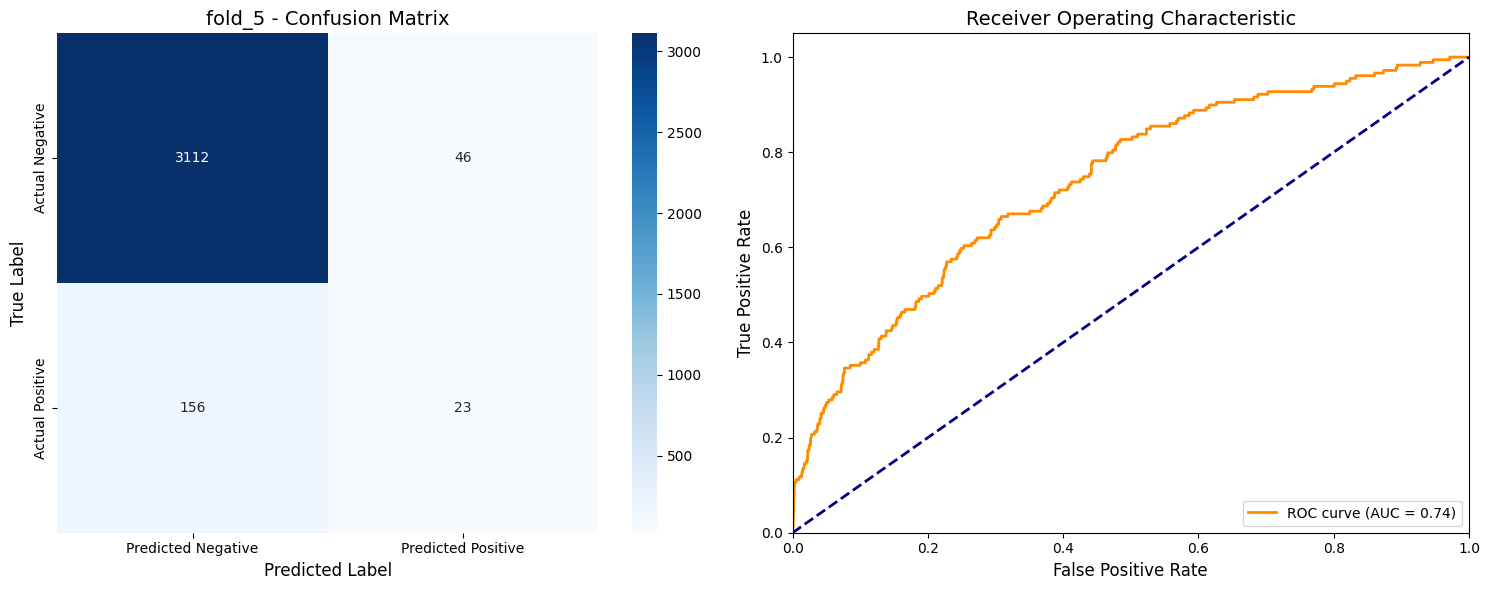


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7364
 F1 Score 0.5770
Precision 0.6428
   Recall 0.5570
 Accuracy 0.9395


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.333333 0.128492
Negative   0.952264 0.985434



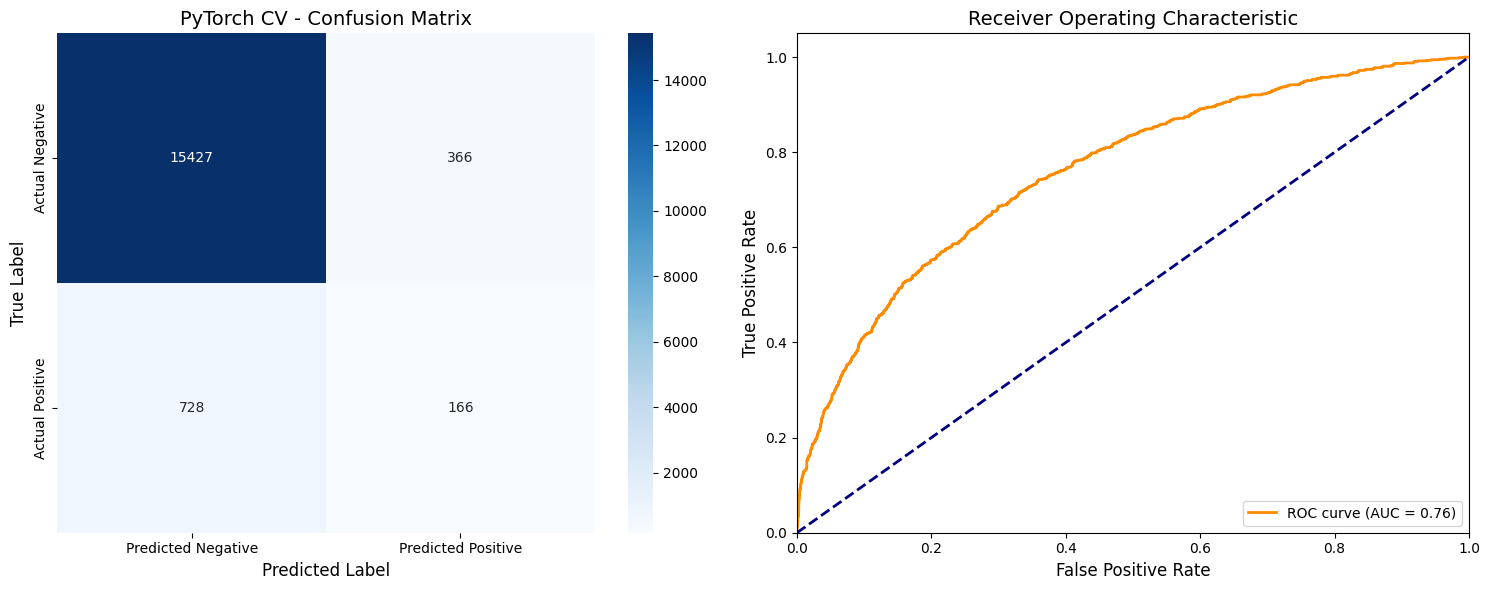

CPU times: user 1min 7s, sys: 13.2 s, total: 1min 20s
Wall time: 15min 16s


ClassificationMetrics(name='CNN', training_time=906.0311564979984, estimators=[{'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': CNNForHallucinationDetection(
  (embedding): Embedding(35965, 512)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(512, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': CNNForHallucinationDetection(
  (embedding): Embedding(35965, 512)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(512, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
             

In [51]:
%%time

cnn_metrics = cross_validate_model(
    model=cnn_model,
    X=data_nn['Input'],
    y=data_nn['Target'],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='CNN'
)

cnn_metrics

Можно заметить, что CNN обучилась значительно быстрее RNN, благодаря оптимизированности архитектуры под параллельные вычисления

Сделаем прогноз на тестовых данных

In [52]:
result = predict_with_ensemble(cnn_metrics.estimators, test_data_nn['Input'], device, 256)
cnn_predictions = result[1]
cnn_predictions

Predicting ensemble: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87/87 [00:05<00:00, 15.63it/s]


array([0.14450648, 0.06780225, 0.00398906, ..., 0.20563105, 0.24798691,
       0.02884781], shape=(11125,), dtype=float32)

In [53]:
cnn_submission = build_submission_dataframe(test_data=test_data, id_column="Id", 
                                            target_column="Target", predictions=cnn_predictions)

cnn_submission.head(5)

,Id,Target
0,20568,0.144506
1,17686,0.067802
2,13035,0.003989
3,22646,0.404805
4,5535,0.000880


In [54]:
cnn_submission.to_csv(f"{data_path}/cnn_submission.csv", index=False)

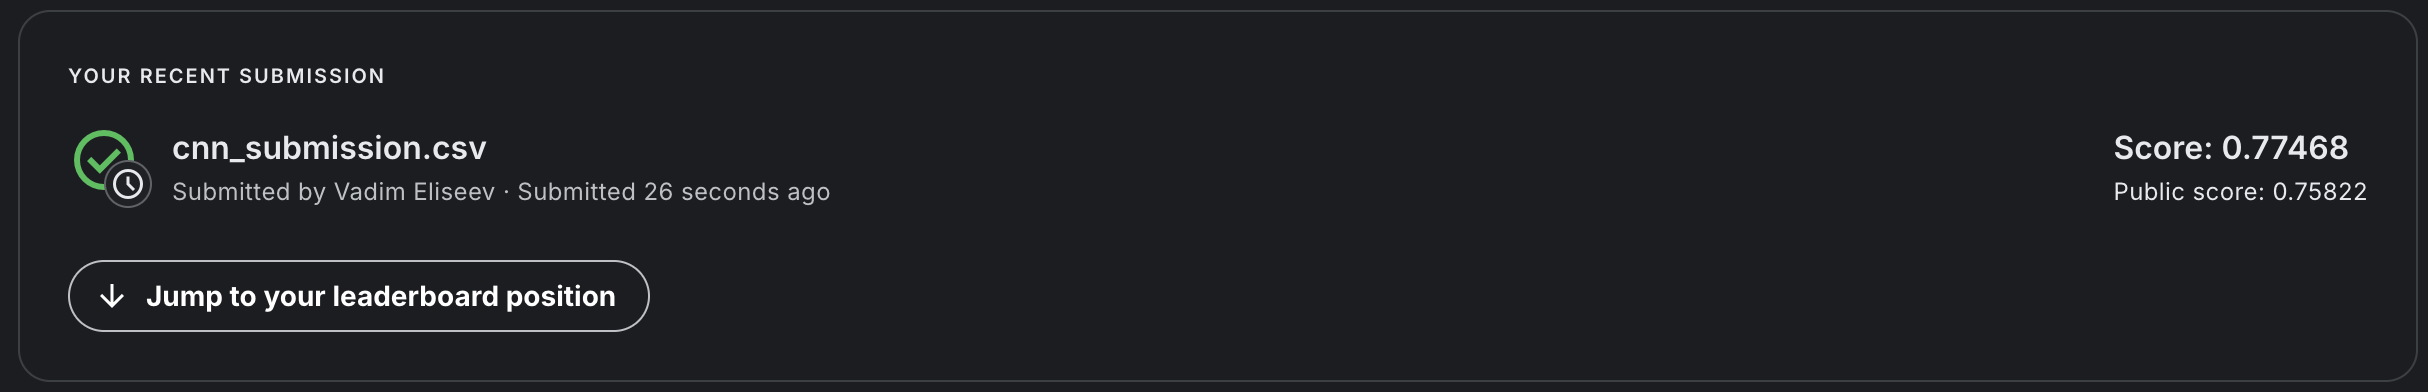

Видно, что CNN справилась значительно быстрее и качественнее рекуррентной сети

In [55]:
free_memory()

## LSTM (Сеть долгой краткосрочной памяти)

LSTM является улучшенной версией RNN с оптимизациями направленными на решение проблем длинных зависимостей и на лучший учет контекста

Определим параметры LSTM

In [57]:
LSTM_UNITS = 64
EMBEDDING_DIM = 256

Построим модель

In [58]:
lstm_model = LSTMForHallucinationDetection(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECCURENT_DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id
).to(device)

lstm_model

LSTMForHallucinationDetection(
  (embedding): Embedding(35965, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [59]:
print(f"LSTM содержит число параметров: {count_parameters(lstm_model)}")

LSTM содержит число параметров: 9372033


Запустим процесс обучения


🌀 Fold 1/5


Training fold 1:   2%|███                                                                                                                                                       | 1/50 [00:09<08:07,  9.94s/it]

  Epoch 1/50 | Loss: 0.4176


Training fold 1:   4%|██████▏                                                                                                                                                   | 2/50 [00:19<07:56,  9.92s/it]

  Epoch 2/50 | Loss: 0.3897


Training fold 1:   6%|█████████▏                                                                                                                                                | 3/50 [00:29<07:45,  9.90s/it]

  Epoch 3/50 | Loss: 0.3594


Training fold 1:   8%|████████████▎                                                                                                                                             | 4/50 [00:39<07:34,  9.87s/it]

  Epoch 4/50 | Loss: 0.3252


Training fold 1:  10%|███████████████▍                                                                                                                                          | 5/50 [00:49<07:24,  9.87s/it]

  Epoch 5/50 | Loss: 0.2801


Training fold 1:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:59<07:13,  9.86s/it]

  Epoch 6/50 | Loss: 0.2420


Training fold 1:  14%|█████████████████████▌                                                                                                                                    | 7/50 [01:09<07:03,  9.86s/it]

  Epoch 7/50 | Loss: 0.1988


Training fold 1:  16%|████████████████████████▋                                                                                                                                 | 8/50 [01:18<06:53,  9.85s/it]

  Epoch 8/50 | Loss: 0.1648


Training fold 1:  18%|███████████████████████████▋                                                                                                                              | 9/50 [01:28<06:44,  9.86s/it]

  Epoch 9/50 | Loss: 0.1413


Training fold 1:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [01:38<06:34,  9.86s/it]

  Epoch 10/50 | Loss: 0.1247


Training fold 1:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [01:48<06:24,  9.86s/it]

  Epoch 11/50 | Loss: 0.1009


Training fold 1:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [01:58<06:15,  9.89s/it]

  Epoch 12/50 | Loss: 0.0922


Training fold 1:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [02:08<06:05,  9.89s/it]

  Epoch 13/50 | Loss: 0.0851


Training fold 1:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [02:18<05:55,  9.87s/it]

  Epoch 14/50 | Loss: 0.0736


Training fold 1:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [02:28<05:45,  9.86s/it]

  Epoch 15/50 | Loss: 0.0691


Training fold 1:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [02:37<05:35,  9.87s/it]

  Epoch 16/50 | Loss: 0.0721


Training fold 1:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [02:47<05:25,  9.87s/it]

  Epoch 17/50 | Loss: 0.0567


Training fold 1:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [02:57<05:16,  9.88s/it]

  Epoch 18/50 | Loss: 0.0535


Training fold 1:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [03:07<05:06,  9.89s/it]

  Epoch 19/50 | Loss: 0.0513


Training fold 1:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [03:17<04:56,  9.90s/it]

  Epoch 20/50 | Loss: 0.0533


Training fold 1:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [03:27<04:47,  9.90s/it]

  Epoch 21/50 | Loss: 0.0465


Training fold 1:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [03:37<04:38,  9.93s/it]

  Epoch 22/50 | Loss: 0.0400


Training fold 1:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [03:47<04:28,  9.95s/it]

  Epoch 23/50 | Loss: 0.0430


Training fold 1:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [03:57<04:19,  9.97s/it]

  Epoch 24/50 | Loss: 0.0334


Training fold 1:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [04:07<04:09,  9.98s/it]

  Epoch 25/50 | Loss: 0.0315


Training fold 1:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [04:17<03:59,  9.98s/it]

  Epoch 26/50 | Loss: 0.0357


Training fold 1:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [04:27<03:49,  9.98s/it]

  Epoch 27/50 | Loss: 0.0333


Training fold 1:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [04:37<03:39,  9.97s/it]

  Epoch 28/50 | Loss: 0.0344


Training fold 1:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [04:47<03:28,  9.95s/it]

  Epoch 29/50 | Loss: 0.0289


Training fold 1:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [04:57<03:18,  9.95s/it]

  Epoch 30/50 | Loss: 0.0339


Training fold 1:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [05:07<03:09,  9.95s/it]

  Epoch 31/50 | Loss: 0.0337


Training fold 1:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [05:17<02:59,  9.96s/it]

  Epoch 32/50 | Loss: 0.0295


Training fold 1:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [05:27<02:49,  9.96s/it]

  Epoch 33/50 | Loss: 0.0413


Training fold 1:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [05:37<02:39,  9.94s/it]

  Epoch 34/50 | Loss: 0.0295


Training fold 1:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [05:46<02:29,  9.94s/it]

  Epoch 35/50 | Loss: 0.0203


Training fold 1:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [05:56<02:19,  9.94s/it]

  Epoch 36/50 | Loss: 0.0166


Training fold 1:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [06:06<02:09,  9.94s/it]

  Epoch 37/50 | Loss: 0.0242


Training fold 1:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [06:16<01:59,  9.94s/it]

  Epoch 38/50 | Loss: 0.0228


Training fold 1:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [06:26<01:49,  9.92s/it]

  Epoch 39/50 | Loss: 0.0291


Training fold 1:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [06:36<01:39,  9.90s/it]

  Epoch 40/50 | Loss: 0.0275


Training fold 1:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [06:46<01:29,  9.90s/it]

  Epoch 41/50 | Loss: 0.0269


Training fold 1:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [06:56<01:19,  9.91s/it]

  Epoch 42/50 | Loss: 0.0234


Training fold 1:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [07:06<01:09,  9.91s/it]

  Epoch 43/50 | Loss: 0.0206


Training fold 1:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [07:16<00:59,  9.90s/it]

  Epoch 44/50 | Loss: 0.0181


Training fold 1:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [07:26<00:49,  9.90s/it]

  Epoch 45/50 | Loss: 0.0178


Training fold 1:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [07:35<00:39,  9.91s/it]

  Epoch 46/50 | Loss: 0.0199


Training fold 1:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [07:45<00:29,  9.91s/it]

  Epoch 47/50 | Loss: 0.0260


Training fold 1:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [07:55<00:19,  9.92s/it]

  Epoch 48/50 | Loss: 0.0256


Training fold 1:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [08:05<00:09,  9.93s/it]

  Epoch 49/50 | Loss: 0.0246


Training fold 1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [08:15<00:00,  9.91s/it]


  Epoch 50/50 | Loss: 0.0277


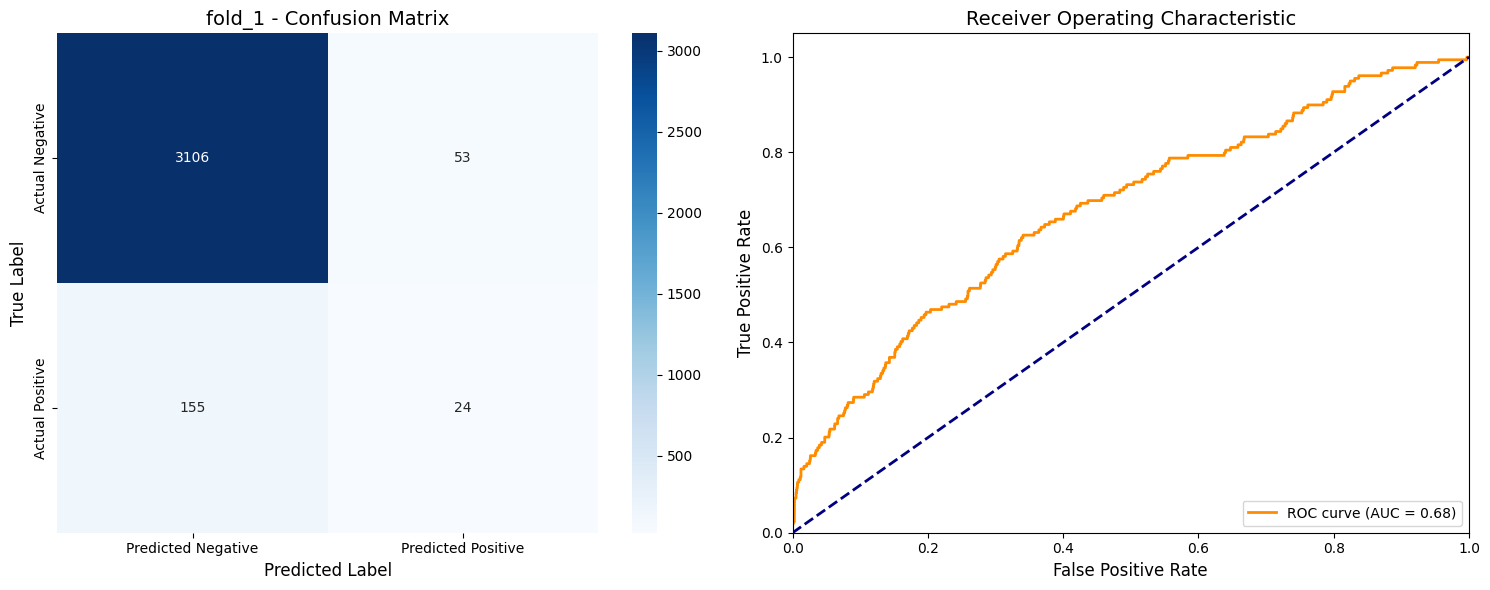


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6790
 F1 Score 0.5776
Precision 0.6321
   Recall 0.5587
 Accuracy 0.9377


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.311688 0.134078
Negative   0.952469 0.983223


🌀 Fold 2/5


Training fold 2:   2%|███                                                                                                                                                       | 1/50 [00:10<08:35, 10.52s/it]

  Epoch 1/50 | Loss: 0.4187


Training fold 2:   4%|██████▏                                                                                                                                                   | 2/50 [00:20<08:07, 10.16s/it]

  Epoch 2/50 | Loss: 0.3920


Training fold 2:   6%|█████████▏                                                                                                                                                | 3/50 [00:30<07:52, 10.05s/it]

  Epoch 3/50 | Loss: 0.3611


Training fold 2:   8%|████████████▎                                                                                                                                             | 4/50 [00:40<07:40, 10.01s/it]

  Epoch 4/50 | Loss: 0.3255


Training fold 2:  10%|███████████████▍                                                                                                                                          | 5/50 [00:50<07:29,  9.98s/it]

  Epoch 5/50 | Loss: 0.2860


Training fold 2:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:00<07:17,  9.95s/it]

  Epoch 6/50 | Loss: 0.2381


Training fold 2:  14%|█████████████████████▌                                                                                                                                    | 7/50 [01:10<07:07,  9.93s/it]

  Epoch 7/50 | Loss: 0.1998


Training fold 2:  16%|████████████████████████▋                                                                                                                                 | 8/50 [01:19<06:56,  9.92s/it]

  Epoch 8/50 | Loss: 0.1678


Training fold 2:  18%|███████████████████████████▋                                                                                                                              | 9/50 [01:29<06:47,  9.93s/it]

  Epoch 9/50 | Loss: 0.1457


Training fold 2:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [01:39<06:37,  9.93s/it]

  Epoch 10/50 | Loss: 0.1267


Training fold 2:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [01:49<06:27,  9.94s/it]

  Epoch 11/50 | Loss: 0.1111


Training fold 2:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [01:59<06:17,  9.93s/it]

  Epoch 12/50 | Loss: 0.0958


Training fold 2:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [02:09<06:07,  9.92s/it]

  Epoch 13/50 | Loss: 0.0835


Training fold 2:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [02:19<05:57,  9.92s/it]

  Epoch 14/50 | Loss: 0.0748


Training fold 2:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [02:29<05:47,  9.92s/it]

  Epoch 15/50 | Loss: 0.0724


Training fold 2:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [02:39<05:37,  9.92s/it]

  Epoch 16/50 | Loss: 0.0566


Training fold 2:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [02:49<05:26,  9.91s/it]

  Epoch 17/50 | Loss: 0.0559


Training fold 2:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [02:59<05:16,  9.90s/it]

  Epoch 18/50 | Loss: 0.0558


Training fold 2:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [03:09<05:07,  9.92s/it]

  Epoch 19/50 | Loss: 0.0584


Training fold 2:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [03:18<04:57,  9.92s/it]

  Epoch 20/50 | Loss: 0.0477


Training fold 2:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [03:28<04:47,  9.93s/it]

  Epoch 21/50 | Loss: 0.0408


Training fold 2:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [03:38<04:37,  9.92s/it]

  Epoch 22/50 | Loss: 0.0372


Training fold 2:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [03:48<04:28,  9.93s/it]

  Epoch 23/50 | Loss: 0.0450


Training fold 2:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [03:58<04:18,  9.95s/it]

  Epoch 24/50 | Loss: 0.0339


Training fold 2:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [04:08<04:08,  9.94s/it]

  Epoch 25/50 | Loss: 0.0305


Training fold 2:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [04:18<03:59,  9.97s/it]

  Epoch 26/50 | Loss: 0.0336


Training fold 2:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [04:28<03:49,  9.97s/it]

  Epoch 27/50 | Loss: 0.0295


Training fold 2:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [04:38<03:39,  9.96s/it]

  Epoch 28/50 | Loss: 0.0288


Training fold 2:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [04:48<03:29,  9.97s/it]

  Epoch 29/50 | Loss: 0.0313


Training fold 2:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [04:58<03:19,  9.97s/it]

  Epoch 30/50 | Loss: 0.0273


Training fold 2:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [05:08<03:09,  9.97s/it]

  Epoch 31/50 | Loss: 0.0245


Training fold 2:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [05:18<02:59,  9.99s/it]

  Epoch 32/50 | Loss: 0.0202


Training fold 2:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [05:28<02:49,  9.98s/it]

  Epoch 33/50 | Loss: 0.0285


Training fold 2:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [05:38<02:39,  9.98s/it]

  Epoch 34/50 | Loss: 0.0270


Training fold 2:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [05:48<02:29,  9.98s/it]

  Epoch 35/50 | Loss: 0.0227


Training fold 2:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [05:58<02:19,  9.97s/it]

  Epoch 36/50 | Loss: 0.0257


Training fold 2:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [06:08<02:09,  9.95s/it]

  Epoch 37/50 | Loss: 0.0263


Training fold 2:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [06:18<01:59,  9.93s/it]

  Epoch 38/50 | Loss: 0.0241


Training fold 2:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [06:28<01:49,  9.94s/it]

  Epoch 39/50 | Loss: 0.0155


Training fold 2:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [06:38<01:39,  9.94s/it]

  Epoch 40/50 | Loss: 0.0233


Training fold 2:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [06:48<01:29,  9.95s/it]

  Epoch 41/50 | Loss: 0.0320


Training fold 2:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [06:58<01:19,  9.97s/it]

  Epoch 42/50 | Loss: 0.0240


Training fold 2:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [07:08<01:09,  9.97s/it]

  Epoch 43/50 | Loss: 0.0243


Training fold 2:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [07:18<00:59,  9.98s/it]

  Epoch 44/50 | Loss: 0.0211


Training fold 2:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [07:28<00:49,  9.97s/it]

  Epoch 45/50 | Loss: 0.0271


Training fold 2:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [07:38<00:39,  9.98s/it]

  Epoch 46/50 | Loss: 0.0168


Training fold 2:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [07:48<00:29,  9.97s/it]

  Epoch 47/50 | Loss: 0.0167


Training fold 2:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [07:57<00:19,  9.92s/it]

  Epoch 48/50 | Loss: 0.0170


Training fold 2:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [08:07<00:09,  9.91s/it]

  Epoch 49/50 | Loss: 0.0179


Training fold 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [08:17<00:00,  9.95s/it]


  Epoch 50/50 | Loss: 0.0199


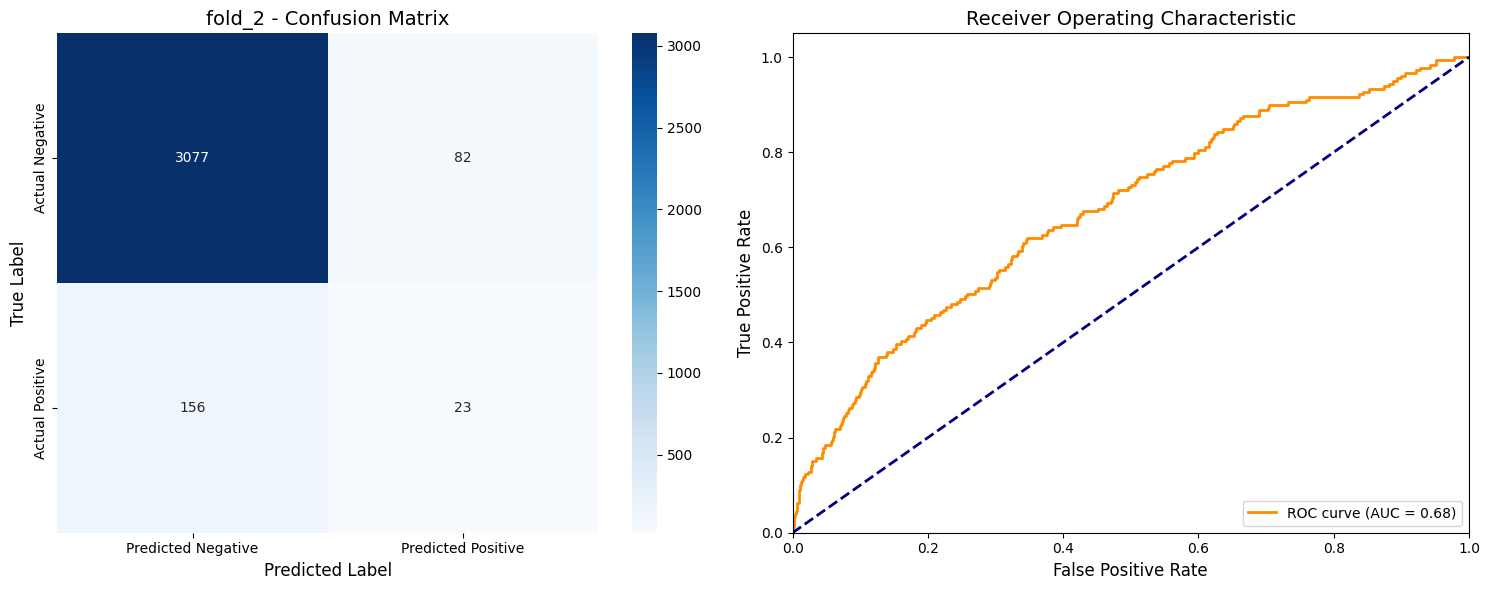


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6781
 F1 Score 0.5624
Precision 0.5854
   Recall 0.5513
 Accuracy 0.9287


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.219048 0.128492
Negative   0.951748 0.974042


🌀 Fold 3/5


Training fold 3:   2%|███                                                                                                                                                       | 1/50 [00:12<10:22, 12.70s/it]

  Epoch 1/50 | Loss: 0.4190


Training fold 3:   4%|██████▏                                                                                                                                                   | 2/50 [00:22<08:51, 11.06s/it]

  Epoch 2/50 | Loss: 0.3866


Training fold 3:   6%|█████████▏                                                                                                                                                | 3/50 [00:32<08:15, 10.55s/it]

  Epoch 3/50 | Loss: 0.3593


Training fold 3:   8%|████████████▎                                                                                                                                             | 4/50 [00:42<07:54, 10.31s/it]

  Epoch 4/50 | Loss: 0.3256


Training fold 3:  10%|███████████████▍                                                                                                                                          | 5/50 [00:52<07:37, 10.17s/it]

  Epoch 5/50 | Loss: 0.2826


Training fold 3:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:02<07:24, 10.10s/it]

  Epoch 6/50 | Loss: 0.2445


Training fold 3:  14%|█████████████████████▌                                                                                                                                    | 7/50 [01:12<07:12, 10.07s/it]

  Epoch 7/50 | Loss: 0.2078


Training fold 3:  16%|████████████████████████▋                                                                                                                                 | 8/50 [01:22<07:01, 10.04s/it]

  Epoch 8/50 | Loss: 0.1722


Training fold 3:  18%|███████████████████████████▋                                                                                                                              | 9/50 [01:32<06:50, 10.02s/it]

  Epoch 9/50 | Loss: 0.1436


Training fold 3:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [01:42<06:40, 10.00s/it]

  Epoch 10/50 | Loss: 0.1259


Training fold 3:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [01:52<06:29,  9.99s/it]

  Epoch 11/50 | Loss: 0.1118


Training fold 3:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [02:02<06:19,  9.99s/it]

  Epoch 12/50 | Loss: 0.0954


Training fold 3:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [02:12<06:09, 10.00s/it]

  Epoch 13/50 | Loss: 0.0834


Training fold 3:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [02:22<06:00, 10.00s/it]

  Epoch 14/50 | Loss: 0.0709


Training fold 3:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [02:32<05:50, 10.01s/it]

  Epoch 15/50 | Loss: 0.0664


Training fold 3:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [02:42<05:40, 10.01s/it]

  Epoch 16/50 | Loss: 0.0629


Training fold 3:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [02:52<05:30, 10.00s/it]

  Epoch 17/50 | Loss: 0.0553


Training fold 3:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [03:02<05:20, 10.03s/it]

  Epoch 18/50 | Loss: 0.0472


Training fold 3:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [03:12<05:10, 10.01s/it]

  Epoch 19/50 | Loss: 0.0446


Training fold 3:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [03:22<04:59,  9.99s/it]

  Epoch 20/50 | Loss: 0.0478


Training fold 3:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [03:32<04:49,  9.98s/it]

  Epoch 21/50 | Loss: 0.0442


Training fold 3:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [03:42<04:39,  9.97s/it]

  Epoch 22/50 | Loss: 0.0343


Training fold 3:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [03:52<04:28,  9.95s/it]

  Epoch 23/50 | Loss: 0.0450


Training fold 3:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [04:02<04:18,  9.95s/it]

  Epoch 24/50 | Loss: 0.0380


Training fold 3:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [04:11<04:08,  9.93s/it]

  Epoch 25/50 | Loss: 0.0306


Training fold 3:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [04:21<03:58,  9.95s/it]

  Epoch 26/50 | Loss: 0.0329


Training fold 3:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [04:31<03:48,  9.95s/it]

  Epoch 27/50 | Loss: 0.0314


Training fold 3:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [04:41<03:39,  9.96s/it]

  Epoch 28/50 | Loss: 0.0421


Training fold 3:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [04:51<03:29,  9.95s/it]

  Epoch 29/50 | Loss: 0.0310


Training fold 3:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [05:01<03:19,  9.97s/it]

  Epoch 30/50 | Loss: 0.0311


Training fold 3:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [05:11<03:09,  9.96s/it]

  Epoch 31/50 | Loss: 0.0304


Training fold 3:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [05:21<02:59,  9.95s/it]

  Epoch 32/50 | Loss: 0.0231


Training fold 3:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [05:31<02:49,  9.95s/it]

  Epoch 33/50 | Loss: 0.0261


Training fold 3:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [05:41<02:39,  9.95s/it]

  Epoch 34/50 | Loss: 0.0299


Training fold 3:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [05:51<02:29,  9.94s/it]

  Epoch 35/50 | Loss: 0.0247


Training fold 3:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [06:01<02:19,  9.94s/it]

  Epoch 36/50 | Loss: 0.0272


Training fold 3:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [06:11<02:09,  9.94s/it]

  Epoch 37/50 | Loss: 0.0217


Training fold 3:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [06:21<01:59,  9.94s/it]

  Epoch 38/50 | Loss: 0.0251


Training fold 3:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [06:31<01:49,  9.95s/it]

  Epoch 39/50 | Loss: 0.0308


Training fold 3:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [06:41<01:39,  9.94s/it]

  Epoch 40/50 | Loss: 0.0180


Training fold 3:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [06:51<01:29,  9.95s/it]

  Epoch 41/50 | Loss: 0.0196


Training fold 3:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [07:01<01:19,  9.95s/it]

  Epoch 42/50 | Loss: 0.0193


Training fold 3:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [07:11<01:09,  9.95s/it]

  Epoch 43/50 | Loss: 0.0213


Training fold 3:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [07:21<00:59,  9.98s/it]

  Epoch 44/50 | Loss: 0.0174


Training fold 3:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [07:31<00:49,  9.97s/it]

  Epoch 45/50 | Loss: 0.0296


Training fold 3:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [07:41<00:39,  9.98s/it]

  Epoch 46/50 | Loss: 0.0228


Training fold 3:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [07:51<00:29, 10.00s/it]

  Epoch 47/50 | Loss: 0.0212


Training fold 3:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [08:01<00:20, 10.01s/it]

  Epoch 48/50 | Loss: 0.0145


Training fold 3:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [08:11<00:10, 10.02s/it]

  Epoch 49/50 | Loss: 0.0208


Training fold 3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [08:21<00:00, 10.02s/it]


  Epoch 50/50 | Loss: 0.0144


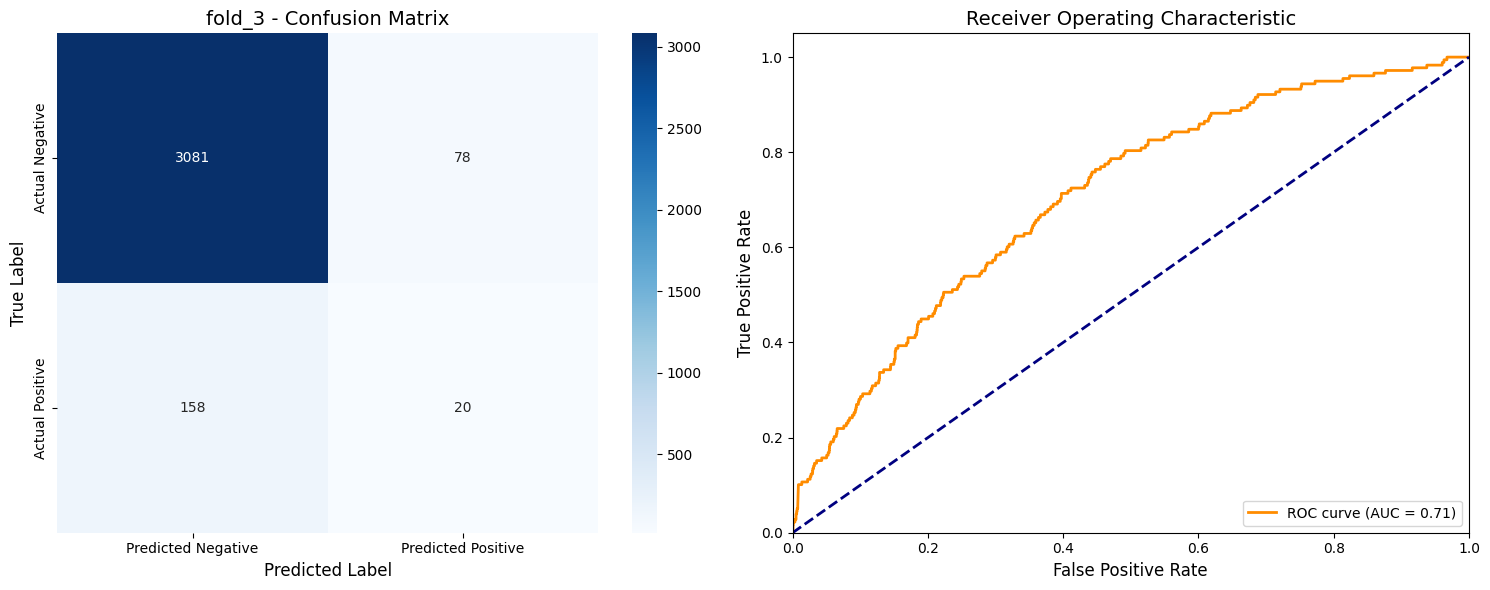


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7058
 F1 Score 0.5540
Precision 0.5777
   Recall 0.5438
 Accuracy 0.9293


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.204082 0.112360
Negative   0.951220 0.975309


🌀 Fold 4/5


Training fold 4:   2%|███                                                                                                                                                       | 1/50 [00:12<10:26, 12.79s/it]

  Epoch 1/50 | Loss: 0.4252


Training fold 4:   4%|██████▏                                                                                                                                                   | 2/50 [00:22<08:55, 11.16s/it]

  Epoch 2/50 | Loss: 0.3886


Training fold 4:   6%|█████████▏                                                                                                                                                | 3/50 [00:32<08:17, 10.59s/it]

  Epoch 3/50 | Loss: 0.3577


Training fold 4:   8%|████████████▎                                                                                                                                             | 4/50 [00:42<07:56, 10.36s/it]

  Epoch 4/50 | Loss: 0.3235


Training fold 4:  10%|███████████████▍                                                                                                                                          | 5/50 [00:52<07:39, 10.22s/it]

  Epoch 5/50 | Loss: 0.2825


Training fold 4:  12%|██████████████████▍                                                                                                                                       | 6/50 [01:02<07:25, 10.13s/it]

  Epoch 6/50 | Loss: 0.2424


Training fold 4:  14%|█████████████████████▌                                                                                                                                    | 7/50 [01:12<07:13, 10.08s/it]

  Epoch 7/50 | Loss: 0.1997


Training fold 4:  16%|████████████████████████▋                                                                                                                                 | 8/50 [01:22<07:03, 10.07s/it]

  Epoch 8/50 | Loss: 0.1746


Training fold 4:  18%|███████████████████████████▋                                                                                                                              | 9/50 [01:32<06:51, 10.03s/it]

  Epoch 9/50 | Loss: 0.1361


Training fold 4:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [01:42<06:40, 10.01s/it]

  Epoch 10/50 | Loss: 0.1192


Training fold 4:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [01:52<06:29,  9.99s/it]

  Epoch 11/50 | Loss: 0.1141


Training fold 4:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [02:02<06:19,  9.99s/it]

  Epoch 12/50 | Loss: 0.1016


Training fold 4:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [02:12<06:10, 10.01s/it]

  Epoch 13/50 | Loss: 0.0837


Training fold 4:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [02:22<06:00, 10.02s/it]

  Epoch 14/50 | Loss: 0.0726


Training fold 4:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [02:32<05:50, 10.02s/it]

  Epoch 15/50 | Loss: 0.0744


Training fold 4:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [02:42<05:40, 10.00s/it]

  Epoch 16/50 | Loss: 0.0694


Training fold 4:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [02:52<05:30, 10.00s/it]

  Epoch 17/50 | Loss: 0.0568


Training fold 4:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [03:02<05:19,  9.99s/it]

  Epoch 18/50 | Loss: 0.0577


Training fold 4:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [03:12<05:09,  9.99s/it]

  Epoch 19/50 | Loss: 0.0492


Training fold 4:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [03:22<04:59,  9.98s/it]

  Epoch 20/50 | Loss: 0.0410


Training fold 4:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [03:32<04:49,  9.99s/it]

  Epoch 21/50 | Loss: 0.0412


Training fold 4:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [03:42<04:39,  9.97s/it]

  Epoch 22/50 | Loss: 0.0492


Training fold 4:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [03:52<04:29,  9.97s/it]

  Epoch 23/50 | Loss: 0.0452


Training fold 4:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [04:02<04:19,  9.97s/it]

  Epoch 24/50 | Loss: 0.0373


Training fold 4:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [04:12<04:09,  9.97s/it]

  Epoch 25/50 | Loss: 0.0397


Training fold 4:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [04:22<03:58,  9.94s/it]

  Epoch 26/50 | Loss: 0.0329


Training fold 4:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [04:32<03:48,  9.95s/it]

  Epoch 27/50 | Loss: 0.0354


Training fold 4:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [04:42<03:38,  9.92s/it]

  Epoch 28/50 | Loss: 0.0368


Training fold 4:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [04:51<03:28,  9.90s/it]

  Epoch 29/50 | Loss: 0.0288


Training fold 4:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [05:01<03:17,  9.89s/it]

  Epoch 30/50 | Loss: 0.0325


Training fold 4:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [05:11<03:07,  9.88s/it]

  Epoch 31/50 | Loss: 0.0287


Training fold 4:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [05:21<02:58,  9.89s/it]

  Epoch 32/50 | Loss: 0.0320


Training fold 4:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [05:31<02:47,  9.88s/it]

  Epoch 33/50 | Loss: 0.0285


Training fold 4:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [05:41<02:38,  9.88s/it]

  Epoch 34/50 | Loss: 0.0219


Training fold 4:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [05:51<02:28,  9.89s/it]

  Epoch 35/50 | Loss: 0.0237


Training fold 4:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [06:01<02:18,  9.88s/it]

  Epoch 36/50 | Loss: 0.0226


Training fold 4:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [06:10<02:08,  9.88s/it]

  Epoch 37/50 | Loss: 0.0312


Training fold 4:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [06:20<01:58,  9.88s/it]

  Epoch 38/50 | Loss: 0.0259


Training fold 4:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [06:30<01:48,  9.88s/it]

  Epoch 39/50 | Loss: 0.0263


Training fold 4:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [06:40<01:38,  9.88s/it]

  Epoch 40/50 | Loss: 0.0306


Training fold 4:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [06:50<01:29,  9.89s/it]

  Epoch 41/50 | Loss: 0.0222


Training fold 4:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [07:00<01:19,  9.88s/it]

  Epoch 42/50 | Loss: 0.0191


Training fold 4:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [07:10<01:09,  9.87s/it]

  Epoch 43/50 | Loss: 0.0193


Training fold 4:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [07:20<00:59,  9.89s/it]

  Epoch 44/50 | Loss: 0.0262


Training fold 4:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [07:29<00:49,  9.88s/it]

  Epoch 45/50 | Loss: 0.0262


Training fold 4:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [07:39<00:39,  9.88s/it]

  Epoch 46/50 | Loss: 0.0188


Training fold 4:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [07:49<00:29,  9.89s/it]

  Epoch 47/50 | Loss: 0.0224


Training fold 4:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [07:59<00:19,  9.88s/it]

  Epoch 48/50 | Loss: 0.0213


Training fold 4:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [08:09<00:09,  9.87s/it]

  Epoch 49/50 | Loss: 0.0241


Training fold 4: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [08:19<00:00,  9.99s/it]


  Epoch 50/50 | Loss: 0.0210


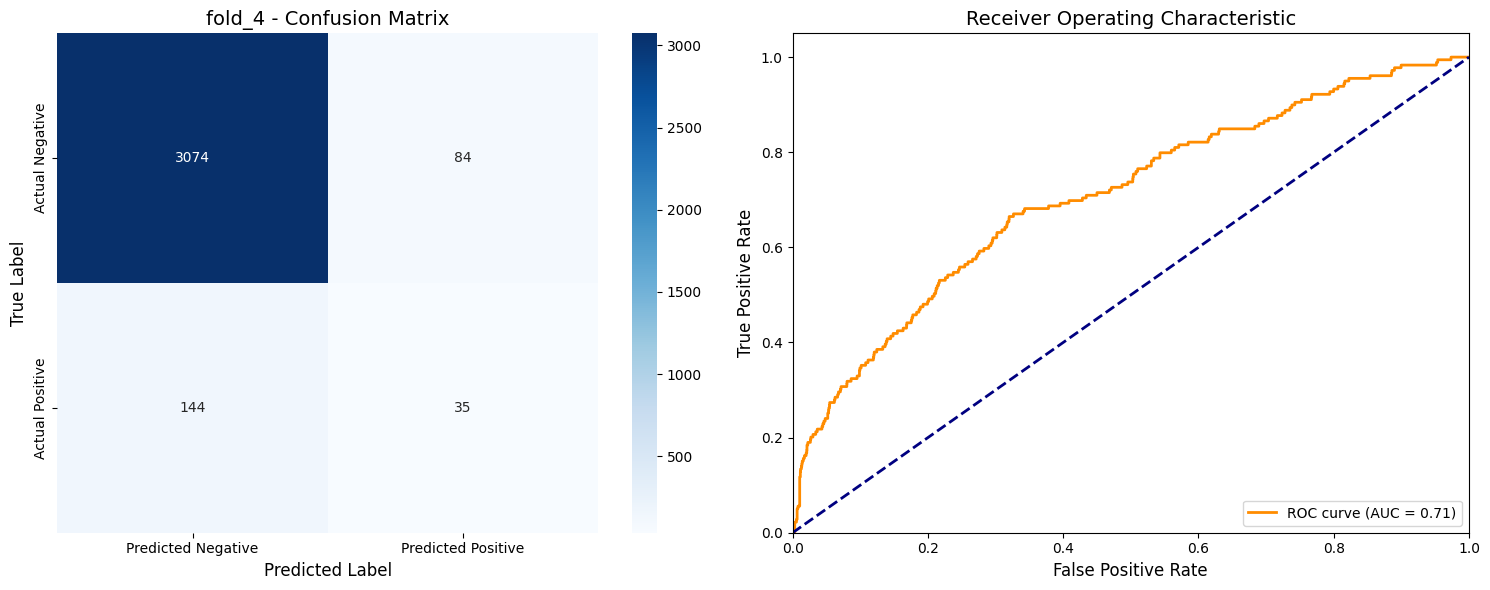


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7071
 F1 Score 0.5996
Precision 0.6247
   Recall 0.5845
 Accuracy 0.9317


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.294118 0.195531
Negative   0.955252 0.973401


🌀 Fold 5/5


Training fold 5:   2%|███                                                                                                                                                       | 1/50 [00:10<08:38, 10.58s/it]

  Epoch 1/50 | Loss: 0.4220


Training fold 5:   4%|██████▏                                                                                                                                                   | 2/50 [00:20<08:06, 10.14s/it]

  Epoch 2/50 | Loss: 0.3873


Training fold 5:   6%|█████████▏                                                                                                                                                | 3/50 [00:30<07:50, 10.01s/it]

  Epoch 3/50 | Loss: 0.3618


Training fold 5:   8%|████████████▎                                                                                                                                             | 4/50 [00:40<07:38,  9.97s/it]

  Epoch 4/50 | Loss: 0.3244


Training fold 5:  10%|███████████████▍                                                                                                                                          | 5/50 [00:50<07:26,  9.93s/it]

  Epoch 5/50 | Loss: 0.2845


Training fold 5:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:59<07:15,  9.90s/it]

  Epoch 6/50 | Loss: 0.2437


Training fold 5:  14%|█████████████████████▌                                                                                                                                    | 7/50 [01:09<07:05,  9.89s/it]

  Epoch 7/50 | Loss: 0.2052


Training fold 5:  16%|████████████████████████▋                                                                                                                                 | 8/50 [01:19<06:54,  9.88s/it]

  Epoch 8/50 | Loss: 0.1706


Training fold 5:  18%|███████████████████████████▋                                                                                                                              | 9/50 [01:29<06:45,  9.88s/it]

  Epoch 9/50 | Loss: 0.1433


Training fold 5:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [01:39<06:34,  9.87s/it]

  Epoch 10/50 | Loss: 0.1230


Training fold 5:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [01:49<06:24,  9.87s/it]

  Epoch 11/50 | Loss: 0.1171


Training fold 5:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [01:59<06:15,  9.88s/it]

  Epoch 12/50 | Loss: 0.0980


Training fold 5:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [02:08<06:05,  9.87s/it]

  Epoch 13/50 | Loss: 0.0871


Training fold 5:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [02:18<05:55,  9.88s/it]

  Epoch 14/50 | Loss: 0.0863


Training fold 5:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [02:28<05:45,  9.87s/it]

  Epoch 15/50 | Loss: 0.0774


Training fold 5:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [02:38<05:35,  9.87s/it]

  Epoch 16/50 | Loss: 0.0702


Training fold 5:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [02:48<05:25,  9.87s/it]

  Epoch 17/50 | Loss: 0.0752


Training fold 5:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [02:58<05:15,  9.87s/it]

  Epoch 18/50 | Loss: 0.0642


Training fold 5:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [03:08<05:05,  9.87s/it]

  Epoch 19/50 | Loss: 0.0481


Training fold 5:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [03:18<04:56,  9.87s/it]

  Epoch 20/50 | Loss: 0.0449


Training fold 5:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [03:27<04:46,  9.87s/it]

  Epoch 21/50 | Loss: 0.0598


Training fold 5:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [03:37<04:36,  9.88s/it]

  Epoch 22/50 | Loss: 0.0489


Training fold 5:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [03:47<04:26,  9.89s/it]

  Epoch 23/50 | Loss: 0.0466


Training fold 5:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [03:57<04:16,  9.88s/it]

  Epoch 24/50 | Loss: 0.0403


Training fold 5:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [04:07<04:06,  9.87s/it]

  Epoch 25/50 | Loss: 0.0328


Training fold 5:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [04:17<03:56,  9.87s/it]

  Epoch 26/50 | Loss: 0.0330


Training fold 5:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [04:27<03:46,  9.87s/it]

  Epoch 27/50 | Loss: 0.0357


Training fold 5:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [04:37<03:37,  9.88s/it]

  Epoch 28/50 | Loss: 0.0318


Training fold 5:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [04:46<03:27,  9.87s/it]

  Epoch 29/50 | Loss: 0.0354


Training fold 5:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [04:56<03:17,  9.88s/it]

  Epoch 30/50 | Loss: 0.0343


Training fold 5:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [05:06<03:07,  9.87s/it]

  Epoch 31/50 | Loss: 0.0279


Training fold 5:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [05:16<02:57,  9.88s/it]

  Epoch 32/50 | Loss: 0.0319


Training fold 5:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [05:26<02:47,  9.87s/it]

  Epoch 33/50 | Loss: 0.0323


Training fold 5:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [05:36<02:37,  9.87s/it]

  Epoch 34/50 | Loss: 0.0254


Training fold 5:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [05:46<02:28,  9.88s/it]

  Epoch 35/50 | Loss: 0.0285


Training fold 5:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [05:56<02:18,  9.88s/it]

  Epoch 36/50 | Loss: 0.0297


Training fold 5:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [06:05<02:08,  9.87s/it]

  Epoch 37/50 | Loss: 0.0239


Training fold 5:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [06:15<01:58,  9.88s/it]

  Epoch 38/50 | Loss: 0.0266


Training fold 5:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [06:25<01:48,  9.87s/it]

  Epoch 39/50 | Loss: 0.0298


Training fold 5:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [06:35<01:38,  9.87s/it]

  Epoch 40/50 | Loss: 0.0197


Training fold 5:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [06:45<01:28,  9.87s/it]

  Epoch 41/50 | Loss: 0.0230


Training fold 5:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [06:55<01:18,  9.87s/it]

  Epoch 42/50 | Loss: 0.0247


Training fold 5:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [07:05<01:09,  9.87s/it]

  Epoch 43/50 | Loss: 0.0240


Training fold 5:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [07:15<00:59,  9.88s/it]

  Epoch 44/50 | Loss: 0.0178


Training fold 5:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [07:24<00:49,  9.88s/it]

  Epoch 45/50 | Loss: 0.0186


Training fold 5:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [07:34<00:39,  9.88s/it]

  Epoch 46/50 | Loss: 0.0258


Training fold 5:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [07:44<00:29,  9.89s/it]

  Epoch 47/50 | Loss: 0.0202


Training fold 5:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [07:54<00:19,  9.89s/it]

  Epoch 48/50 | Loss: 0.0270


Training fold 5:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [08:04<00:09,  9.88s/it]

  Epoch 49/50 | Loss: 0.0184


Training fold 5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [08:14<00:00,  9.89s/it]


  Epoch 50/50 | Loss: 0.0159


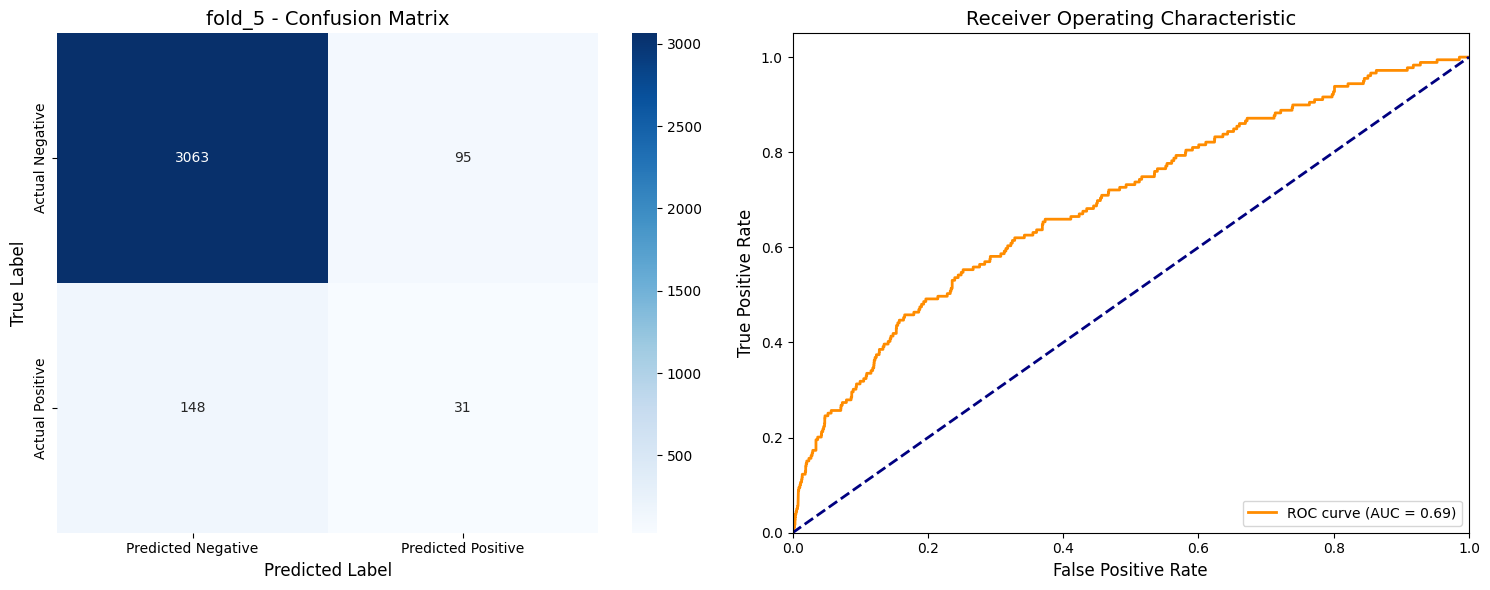


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6940
 F1 Score 0.5826
Precision 0.6000
   Recall 0.5716
 Accuracy 0.9272


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.246032 0.173184
Negative   0.953908 0.969918



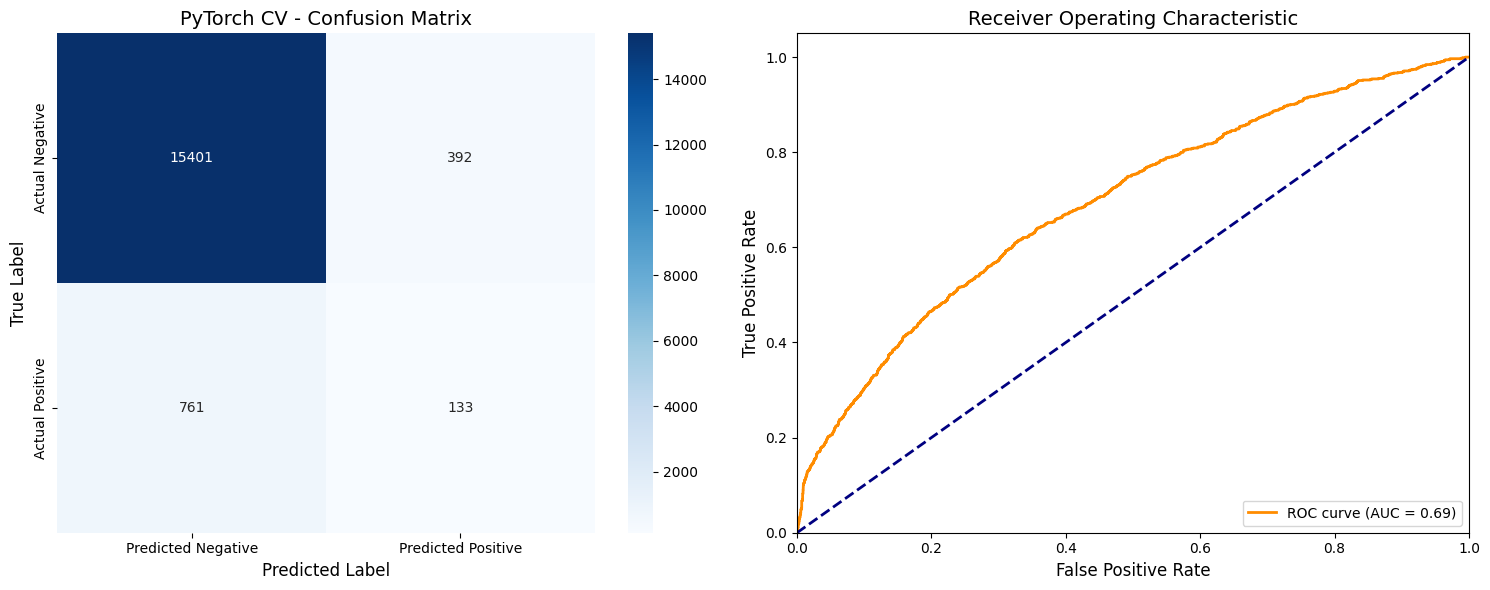

CPU times: user 15min 5s, sys: 48.8 s, total: 15min 54s
Wall time: 42min 44s


ClassificationMetrics(name='LSTM', training_time=2488.4515091249996, estimators=[{'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': LSTMForHallucinationDetection(
  (embedding): Embedding(35965, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': LSTMForHallucinationDetection(
  (embedding): Embedding(35965, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)}, {'preprocessor': Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=1000, pad_left=False))]), 'model': LSTMForHallucinationDetection(
  (embedding): Embedding(3

In [60]:
%%time

lstm_metrics = cross_validate_model(
    model=lstm_model,
    X=data_nn['Input'],
    y=data_nn['Target'],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='LSTM'
)

lstm_metrics

Видно что LSTM справилась практически в 2 раза быстрее RNN, но все еще медленнее CNN, что говорит о наличии проблем у архитектуры в плане распараллеливания

Сделаем прогноз на тестовых данных

In [61]:
result = predict_with_ensemble(lstm_metrics.estimators, test_data_nn['Input'], device, 256)
lstm_predictions = result[1]
lstm_predictions

Predicting ensemble: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87/87 [00:15<00:00,  5.65it/s]


array([7.2984578e-04, 1.9254874e-03, 1.2751837e-03, ..., 1.2482994e-05,
       2.7826297e-04, 4.8251763e-06], shape=(11125,), dtype=float32)

In [62]:
lstm_submission = build_submission_dataframe(test_data=test_data, id_column="Id", 
                                             target_column="Target", predictions=lstm_predictions)

lstm_submission.head(5)

,Id,Target
0,20568,0.000730
1,17686,0.001925
2,13035,0.001275
3,22646,0.000076
4,5535,0.000422


In [63]:
lstm_submission.to_csv(f"{data_path}/lstm_submission.csv", index=False)

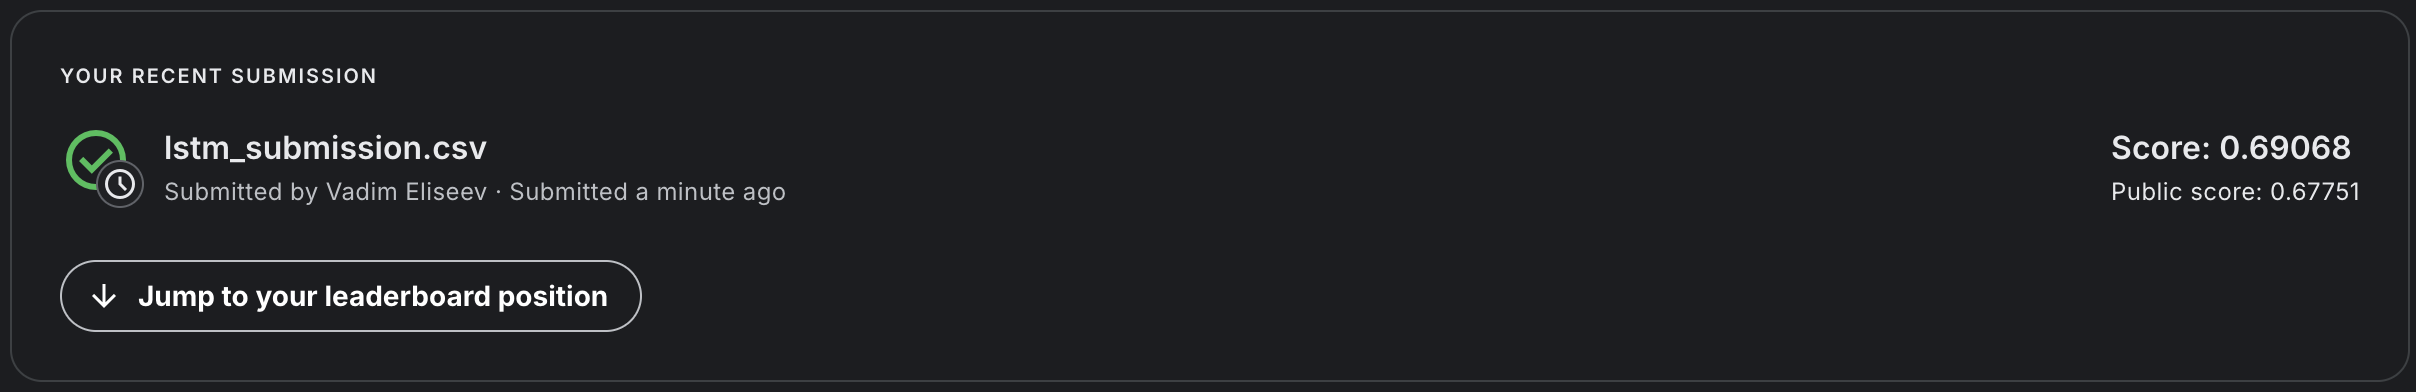

Видим, что модель справилась лучше чем RNN, но все еще хуже сверточной нейронной сети

## Предобученные GloVe эмбеддинги + CNN

Суть подхода - не тратить время на обучение собственной матрицы эмбеддингов, а использовать уже предобученные. Выходы эмбеддингов будут подаваться на сверточный слой - показавший себя лучшим среди прочих архитектур, после чего также будет применен линейный слой классификации

Определим параметры GloVe. Файл с эмбеддингами можно найти по [ссылке](https://huggingface.co/spaces/lwdragon/lstm_mindspore/blob/main/glove.6B.100d.txt)

In [64]:
GLOVE_DIM = 100
GLOVE_MAX_VOCAB = 20000
GLOVE_PATH: str = 'glove/glove.6B.100d.txt'

Определим гиперпараметры сети и процесса обучения

In [65]:
LEARNING_RATE = 1e-3        
BATCH_SIZE = 128
FILTERS = 10
KERNEL_SIZE = 3
REGULARIZATION_STRENGTH = 1e-4
MAX_SEQUENCE_LENGTH = 1000

Загрузим GloVe эмбеддинги и построим препроцессор

In [66]:
glove_vocab, glove_matrix = load_glove_fixed_vocab(GLOVE_PATH, GLOVE_DIM, GLOVE_MAX_VOCAB)
glove_preprocessor = SequenceVectorizer(max_length=MAX_SEQUENCE_LENGTH, vocabulary=glove_vocab, pad_left=False)
glove_preprocessor

,min_frequency,1
,max_vocab_size,None
,pad_token,'<PAD>'
,oov_token,'<OOV>'
,pad_left,False
,max_length,1000
,dtype,'int32'
,vocabulary,"{'!': 807, '""': 10, '#': 2751, '$': 82, ...}"


Построим саму модель

In [67]:
glove_cnn_model = GloveCNNForHallucinationDetection(
    glove_matrix=glove_matrix,
    num_filters=FILTERS,
    kernel_size=KERNEL_SIZE
).to(device)

glove_cnn_model

GloveCNNForHallucinationDetection(
  (embedding): Embedding(20003, 100)
  (relu): ReLU()
  (conv): Conv1d(100, 10, kernel_size=(3,), stride=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)

In [68]:
print(f"Сверточная модель с GloVe эмбеддингами содержит число параметров: {count_parameters(glove_cnn_model)}")
print(f"Сверточная модель с GloVe эмбеддингами содержит число обучаемых параметров: {count_trainable_parameters(glove_cnn_model)}")

Сверточная модель с GloVe эмбеддингами содержит число параметров: 2003321
Сверточная модель с GloVe эмбеддингами содержит число обучаемых параметров: 3021


Можно заметить, что обучаемых параметров практически в 1000 раз меньше чем параметров модели в целом. Это достигается за счет того, что мы замораживаем матрицу эмбеддингов, имеющую большую размерность, и обучаем только сверточный и линейный слои

Запустим процесс обучения


🌀 Fold 1/5


Training fold 1:   2%|███                                                                                                                                                       | 1/50 [00:00<00:28,  1.70it/s]

  Epoch 1/50 | Loss: 0.4299


Training fold 1:   4%|██████▏                                                                                                                                                   | 2/50 [00:01<00:24,  1.95it/s]

  Epoch 2/50 | Loss: 0.4075


Training fold 1:   6%|█████████▏                                                                                                                                                | 3/50 [00:01<00:22,  2.06it/s]

  Epoch 3/50 | Loss: 0.3984


Training fold 1:   8%|████████████▎                                                                                                                                             | 4/50 [00:01<00:21,  2.09it/s]

  Epoch 4/50 | Loss: 0.3852


Training fold 1:  10%|███████████████▍                                                                                                                                          | 5/50 [00:02<00:21,  2.14it/s]

  Epoch 5/50 | Loss: 0.3735


Training fold 1:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:02<00:20,  2.17it/s]

  Epoch 6/50 | Loss: 0.3633


Training fold 1:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:03<00:19,  2.19it/s]

  Epoch 7/50 | Loss: 0.3520


Training fold 1:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:03<00:19,  2.20it/s]

  Epoch 8/50 | Loss: 0.3412


Training fold 1:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:04<00:18,  2.20it/s]

  Epoch 9/50 | Loss: 0.3297


Training fold 1:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:04<00:18,  2.20it/s]

  Epoch 10/50 | Loss: 0.3241


Training fold 1:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:05<00:17,  2.21it/s]

  Epoch 11/50 | Loss: 0.3114


Training fold 1:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:05<00:17,  2.22it/s]

  Epoch 12/50 | Loss: 0.3041


Training fold 1:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:06<00:17,  2.16it/s]

  Epoch 13/50 | Loss: 0.2956


Training fold 1:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:06<00:16,  2.15it/s]

  Epoch 14/50 | Loss: 0.2878


Training fold 1:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:06<00:16,  2.16it/s]

  Epoch 15/50 | Loss: 0.2813


Training fold 1:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:07<00:15,  2.17it/s]

  Epoch 16/50 | Loss: 0.2736


Training fold 1:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [00:07<00:15,  2.18it/s]

  Epoch 17/50 | Loss: 0.2675


Training fold 1:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [00:08<00:14,  2.19it/s]

  Epoch 18/50 | Loss: 0.2619


Training fold 1:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [00:08<00:14,  2.16it/s]

  Epoch 19/50 | Loss: 0.2533


Training fold 1:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [00:09<00:16,  1.86it/s]

  Epoch 20/50 | Loss: 0.2472


Training fold 1:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [00:10<00:15,  1.92it/s]

  Epoch 21/50 | Loss: 0.2420


Training fold 1:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [00:10<00:14,  1.92it/s]

  Epoch 22/50 | Loss: 0.2369


Training fold 1:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [00:10<00:13,  1.99it/s]

  Epoch 23/50 | Loss: 0.2328


Training fold 1:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [00:11<00:12,  2.05it/s]

  Epoch 24/50 | Loss: 0.2263


Training fold 1:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [00:11<00:11,  2.10it/s]

  Epoch 25/50 | Loss: 0.2210


Training fold 1:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [00:12<00:11,  2.13it/s]

  Epoch 26/50 | Loss: 0.2173


Training fold 1:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [00:12<00:10,  2.16it/s]

  Epoch 27/50 | Loss: 0.2136


Training fold 1:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [00:13<00:10,  2.17it/s]

  Epoch 28/50 | Loss: 0.2095


Training fold 1:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [00:13<00:09,  2.18it/s]

  Epoch 29/50 | Loss: 0.2059


Training fold 1:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [00:14<00:09,  2.18it/s]

  Epoch 30/50 | Loss: 0.1995


Training fold 1:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [00:14<00:08,  2.16it/s]

  Epoch 31/50 | Loss: 0.1969


Training fold 1:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [00:15<00:08,  2.17it/s]

  Epoch 32/50 | Loss: 0.1920


Training fold 1:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [00:15<00:07,  2.17it/s]

  Epoch 33/50 | Loss: 0.1897


Training fold 1:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [00:16<00:07,  2.18it/s]

  Epoch 34/50 | Loss: 0.1848


Training fold 1:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [00:16<00:06,  2.14it/s]

  Epoch 35/50 | Loss: 0.1813


Training fold 1:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [00:16<00:06,  2.12it/s]

  Epoch 36/50 | Loss: 0.1764


Training fold 1:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [00:17<00:06,  2.15it/s]

  Epoch 37/50 | Loss: 0.1727


Training fold 1:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [00:17<00:05,  2.18it/s]

  Epoch 38/50 | Loss: 0.1722


Training fold 1:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [00:18<00:05,  2.18it/s]

  Epoch 39/50 | Loss: 0.1682


Training fold 1:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [00:18<00:04,  2.20it/s]

  Epoch 40/50 | Loss: 0.1633


Training fold 1:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [00:19<00:04,  2.20it/s]

  Epoch 41/50 | Loss: 0.1613


Training fold 1:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [00:19<00:03,  2.21it/s]

  Epoch 42/50 | Loss: 0.1588


Training fold 1:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [00:20<00:03,  2.20it/s]

  Epoch 43/50 | Loss: 0.1545


Training fold 1:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [00:20<00:02,  2.18it/s]

  Epoch 44/50 | Loss: 0.1556


Training fold 1:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [00:21<00:02,  2.19it/s]

  Epoch 45/50 | Loss: 0.1505


Training fold 1:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [00:21<00:01,  2.17it/s]

  Epoch 46/50 | Loss: 0.1476


Training fold 1:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [00:22<00:01,  2.12it/s]

  Epoch 47/50 | Loss: 0.1448


Training fold 1:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [00:22<00:00,  2.06it/s]

  Epoch 48/50 | Loss: 0.1427


Training fold 1:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [00:23<00:00,  2.08it/s]

  Epoch 49/50 | Loss: 0.1393


Training fold 1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:23<00:00,  2.13it/s]

  Epoch 50/50 | Loss: 0.1376


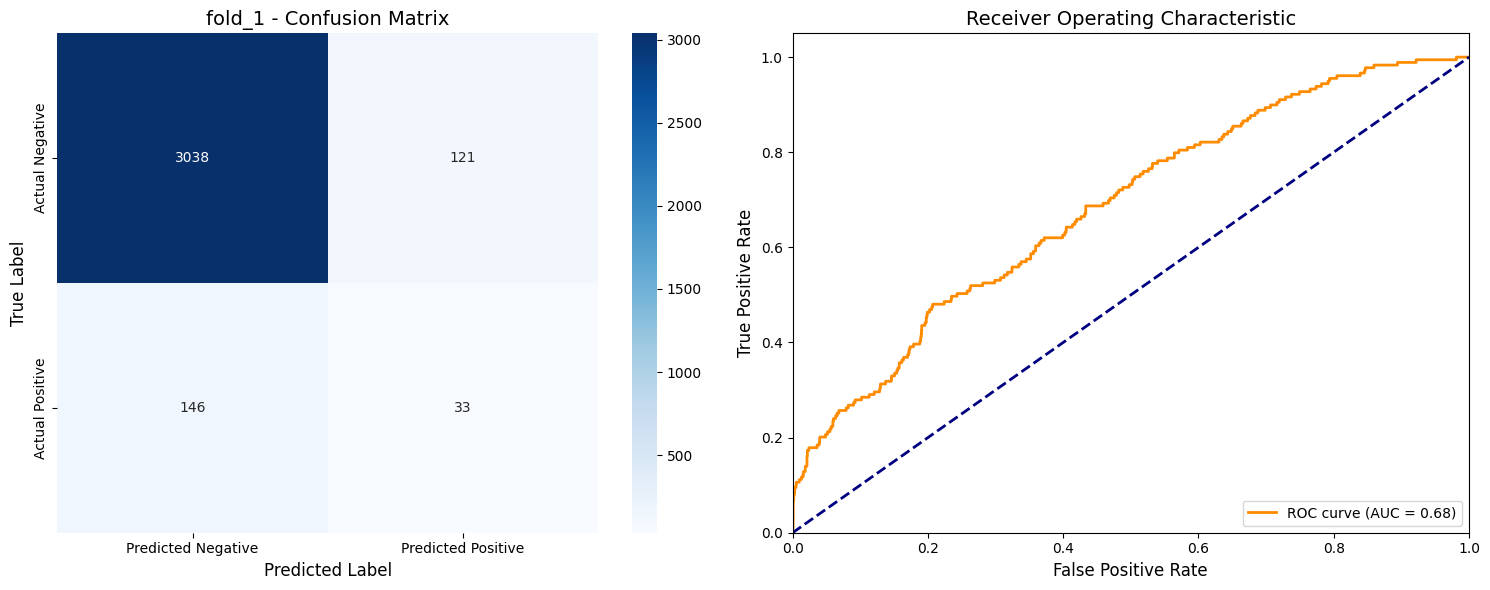


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6838
 F1 Score 0.5781
Precision 0.5842
   Recall 0.5730
 Accuracy 0.9200


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.214286 0.184358
Negative   0.954146 0.961697


🌀 Fold 2/5


Training fold 2:   2%|███                                                                                                                                                       | 1/50 [00:00<00:23,  2.07it/s]

  Epoch 1/50 | Loss: 0.4308


Training fold 2:   4%|██████▏                                                                                                                                                   | 2/50 [00:00<00:22,  2.13it/s]

  Epoch 2/50 | Loss: 0.4081


Training fold 2:   6%|█████████▏                                                                                                                                                | 3/50 [00:01<00:21,  2.15it/s]

  Epoch 3/50 | Loss: 0.3945


Training fold 2:   8%|████████████▎                                                                                                                                             | 4/50 [00:01<00:21,  2.16it/s]

  Epoch 4/50 | Loss: 0.3812


Training fold 2:  10%|███████████████▍                                                                                                                                          | 5/50 [00:02<00:20,  2.20it/s]

  Epoch 5/50 | Loss: 0.3707


Training fold 2:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:02<00:19,  2.20it/s]

  Epoch 6/50 | Loss: 0.3622


Training fold 2:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:03<00:19,  2.22it/s]

  Epoch 7/50 | Loss: 0.3495


Training fold 2:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:03<00:19,  2.21it/s]

  Epoch 8/50 | Loss: 0.3384


Training fold 2:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:04<00:18,  2.22it/s]

  Epoch 9/50 | Loss: 0.3295


Training fold 2:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:04<00:17,  2.23it/s]

  Epoch 10/50 | Loss: 0.3196


Training fold 2:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:04<00:17,  2.24it/s]

  Epoch 11/50 | Loss: 0.3124


Training fold 2:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:05<00:16,  2.24it/s]

  Epoch 12/50 | Loss: 0.3043


Training fold 2:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:05<00:16,  2.24it/s]

  Epoch 13/50 | Loss: 0.2963


Training fold 2:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:06<00:16,  2.24it/s]

  Epoch 14/50 | Loss: 0.2860


Training fold 2:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:06<00:15,  2.23it/s]

  Epoch 15/50 | Loss: 0.2820


Training fold 2:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:07<00:15,  2.24it/s]

  Epoch 16/50 | Loss: 0.2770


Training fold 2:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [00:07<00:14,  2.25it/s]

  Epoch 17/50 | Loss: 0.2691


Training fold 2:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [00:08<00:14,  2.25it/s]

  Epoch 18/50 | Loss: 0.2607


Training fold 2:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [00:08<00:13,  2.26it/s]

  Epoch 19/50 | Loss: 0.2566


Training fold 2:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [00:08<00:13,  2.26it/s]

  Epoch 20/50 | Loss: 0.2528


Training fold 2:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [00:09<00:12,  2.26it/s]

  Epoch 21/50 | Loss: 0.2440


Training fold 2:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [00:09<00:12,  2.26it/s]

  Epoch 22/50 | Loss: 0.2383


Training fold 2:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [00:10<00:11,  2.26it/s]

  Epoch 23/50 | Loss: 0.2338


Training fold 2:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [00:10<00:11,  2.23it/s]

  Epoch 24/50 | Loss: 0.2308


Training fold 2:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [00:11<00:11,  2.23it/s]

  Epoch 25/50 | Loss: 0.2305


Training fold 2:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [00:11<00:10,  2.22it/s]

  Epoch 26/50 | Loss: 0.2195


Training fold 2:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [00:12<00:10,  2.23it/s]

  Epoch 27/50 | Loss: 0.2150


Training fold 2:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [00:12<00:09,  2.24it/s]

  Epoch 28/50 | Loss: 0.2143


Training fold 2:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [00:13<00:09,  2.24it/s]

  Epoch 29/50 | Loss: 0.2108


Training fold 2:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [00:13<00:08,  2.24it/s]

  Epoch 30/50 | Loss: 0.2040


Training fold 2:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [00:13<00:08,  2.24it/s]

  Epoch 31/50 | Loss: 0.2005


Training fold 2:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [00:14<00:08,  2.24it/s]

  Epoch 32/50 | Loss: 0.1965


Training fold 2:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [00:14<00:07,  2.22it/s]

  Epoch 33/50 | Loss: 0.1948


Training fold 2:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [00:15<00:07,  2.23it/s]

  Epoch 34/50 | Loss: 0.1901


Training fold 2:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [00:15<00:06,  2.23it/s]

  Epoch 35/50 | Loss: 0.1876


Training fold 2:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [00:16<00:06,  2.24it/s]

  Epoch 36/50 | Loss: 0.1838


Training fold 2:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [00:16<00:05,  2.24it/s]

  Epoch 37/50 | Loss: 0.1842


Training fold 2:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [00:17<00:05,  2.24it/s]

  Epoch 38/50 | Loss: 0.1821


Training fold 2:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [00:17<00:04,  2.24it/s]

  Epoch 39/50 | Loss: 0.1774


Training fold 2:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [00:17<00:04,  2.22it/s]

  Epoch 40/50 | Loss: 0.1723


Training fold 2:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [00:18<00:04,  2.23it/s]

  Epoch 41/50 | Loss: 0.1709


Training fold 2:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [00:18<00:03,  2.23it/s]

  Epoch 42/50 | Loss: 0.1690


Training fold 2:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [00:19<00:03,  2.23it/s]

  Epoch 43/50 | Loss: 0.1681


Training fold 2:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [00:19<00:02,  2.23it/s]

  Epoch 44/50 | Loss: 0.1609


Training fold 2:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [00:20<00:02,  2.23it/s]

  Epoch 45/50 | Loss: 0.1597


Training fold 2:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [00:20<00:01,  2.24it/s]

  Epoch 46/50 | Loss: 0.1573


Training fold 2:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [00:21<00:01,  2.24it/s]

  Epoch 47/50 | Loss: 0.1550


Training fold 2:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [00:21<00:00,  2.24it/s]

  Epoch 48/50 | Loss: 0.1552


Training fold 2:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [00:21<00:00,  2.24it/s]

  Epoch 49/50 | Loss: 0.1537


Training fold 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:22<00:00,  2.23it/s]

  Epoch 50/50 | Loss: 0.1495


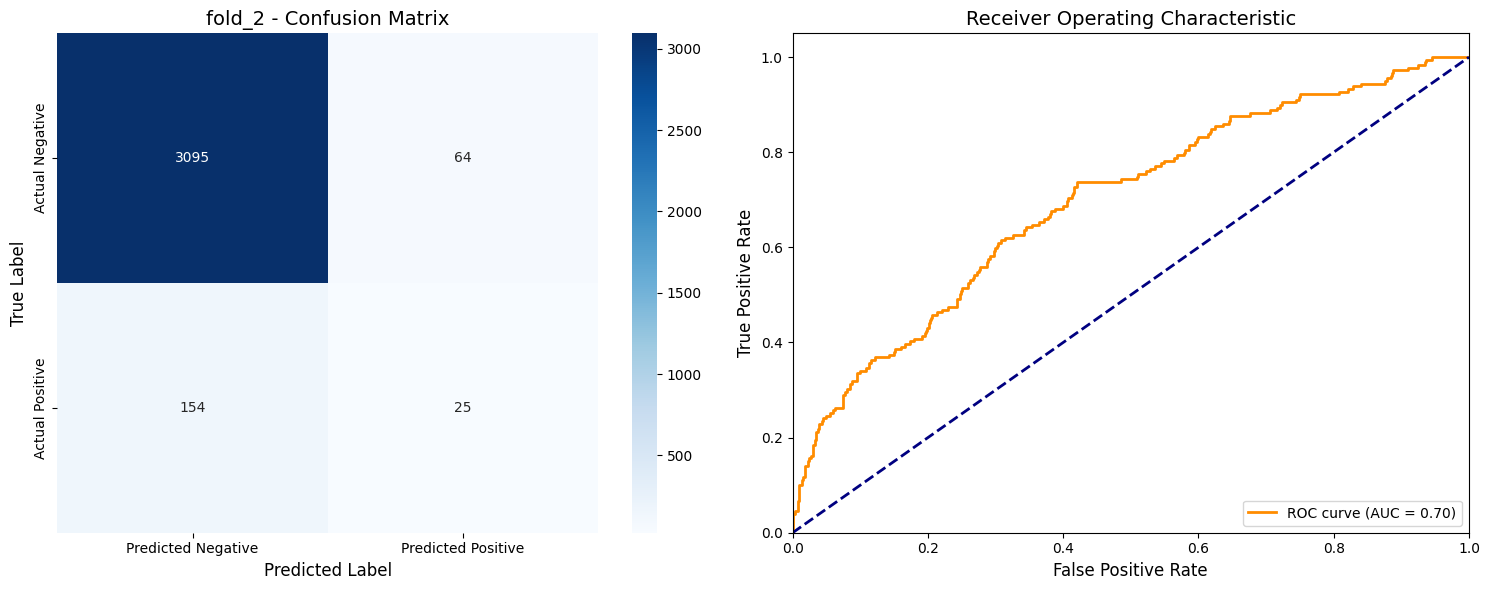


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6970
 F1 Score 0.5763
Precision 0.6167
   Recall 0.5597
 Accuracy 0.9347


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.280899 0.139665
Negative   0.952601 0.979740


🌀 Fold 3/5


Training fold 3:   2%|███                                                                                                                                                       | 1/50 [00:00<00:23,  2.07it/s]

  Epoch 1/50 | Loss: 0.4308


Training fold 3:   4%|██████▏                                                                                                                                                   | 2/50 [00:00<00:22,  2.18it/s]

  Epoch 2/50 | Loss: 0.4093


Training fold 3:   6%|█████████▏                                                                                                                                                | 3/50 [00:01<00:21,  2.22it/s]

  Epoch 3/50 | Loss: 0.3963


Training fold 3:   8%|████████████▎                                                                                                                                             | 4/50 [00:01<00:20,  2.24it/s]

  Epoch 4/50 | Loss: 0.3852


Training fold 3:  10%|███████████████▍                                                                                                                                          | 5/50 [00:02<00:20,  2.24it/s]

  Epoch 5/50 | Loss: 0.3711


Training fold 3:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:02<00:19,  2.25it/s]

  Epoch 6/50 | Loss: 0.3593


Training fold 3:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:03<00:19,  2.23it/s]

  Epoch 7/50 | Loss: 0.3477


Training fold 3:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:03<00:19,  2.16it/s]

  Epoch 8/50 | Loss: 0.3366


Training fold 3:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:04<00:18,  2.17it/s]

  Epoch 9/50 | Loss: 0.3266


Training fold 3:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:04<00:18,  2.18it/s]

  Epoch 10/50 | Loss: 0.3177


Training fold 3:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:05<00:17,  2.18it/s]

  Epoch 11/50 | Loss: 0.3074


Training fold 3:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:05<00:17,  2.18it/s]

  Epoch 12/50 | Loss: 0.3011


Training fold 3:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:05<00:16,  2.18it/s]

  Epoch 13/50 | Loss: 0.2931


Training fold 3:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:06<00:16,  2.16it/s]

  Epoch 14/50 | Loss: 0.2850


Training fold 3:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:06<00:16,  2.17it/s]

  Epoch 15/50 | Loss: 0.2788


Training fold 3:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:07<00:15,  2.16it/s]

  Epoch 16/50 | Loss: 0.2729


Training fold 3:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [00:07<00:15,  2.09it/s]

  Epoch 17/50 | Loss: 0.2682


Training fold 3:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [00:08<00:15,  2.11it/s]

  Epoch 18/50 | Loss: 0.2591


Training fold 3:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [00:08<00:14,  2.15it/s]

  Epoch 19/50 | Loss: 0.2538


Training fold 3:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [00:09<00:13,  2.18it/s]

  Epoch 20/50 | Loss: 0.2493


Training fold 3:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [00:09<00:13,  2.20it/s]

  Epoch 21/50 | Loss: 0.2448


Training fold 3:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [00:10<00:12,  2.21it/s]

  Epoch 22/50 | Loss: 0.2417


Training fold 3:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [00:10<00:12,  2.22it/s]

  Epoch 23/50 | Loss: 0.2342


Training fold 3:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [00:10<00:11,  2.22it/s]

  Epoch 24/50 | Loss: 0.2283


Training fold 3:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [00:11<00:11,  2.23it/s]

  Epoch 25/50 | Loss: 0.2251


Training fold 3:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [00:11<00:10,  2.22it/s]

  Epoch 26/50 | Loss: 0.2235


Training fold 3:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [00:12<00:10,  2.21it/s]

  Epoch 27/50 | Loss: 0.2171


Training fold 3:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [00:12<00:09,  2.21it/s]

  Epoch 28/50 | Loss: 0.2130


Training fold 3:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [00:13<00:09,  2.22it/s]

  Epoch 29/50 | Loss: 0.2127


Training fold 3:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [00:13<00:08,  2.23it/s]

  Epoch 30/50 | Loss: 0.2064


Training fold 3:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [00:14<00:08,  2.23it/s]

  Epoch 31/50 | Loss: 0.2007


Training fold 3:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [00:14<00:08,  2.22it/s]

  Epoch 32/50 | Loss: 0.1993


Training fold 3:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [00:15<00:07,  2.23it/s]

  Epoch 33/50 | Loss: 0.2000


Training fold 3:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [00:15<00:07,  2.23it/s]

  Epoch 34/50 | Loss: 0.1911


Training fold 3:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [00:15<00:06,  2.24it/s]

  Epoch 35/50 | Loss: 0.1876


Training fold 3:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [00:16<00:06,  2.24it/s]

  Epoch 36/50 | Loss: 0.1875


Training fold 3:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [00:16<00:05,  2.24it/s]

  Epoch 37/50 | Loss: 0.1823


Training fold 3:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [00:17<00:05,  2.24it/s]

  Epoch 38/50 | Loss: 0.1790


Training fold 3:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [00:17<00:04,  2.24it/s]

  Epoch 39/50 | Loss: 0.1759


Training fold 3:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [00:18<00:04,  2.24it/s]

  Epoch 40/50 | Loss: 0.1734


Training fold 3:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [00:18<00:04,  2.22it/s]

  Epoch 41/50 | Loss: 0.1711


Training fold 3:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [00:19<00:03,  2.23it/s]

  Epoch 42/50 | Loss: 0.1683


Training fold 3:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [00:19<00:03,  2.24it/s]

  Epoch 43/50 | Loss: 0.1664


Training fold 3:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [00:19<00:02,  2.24it/s]

  Epoch 44/50 | Loss: 0.1637


Training fold 3:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [00:20<00:02,  2.24it/s]

  Epoch 45/50 | Loss: 0.1638


Training fold 3:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [00:20<00:01,  2.13it/s]

  Epoch 46/50 | Loss: 0.1593


Training fold 3:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [00:21<00:01,  2.02it/s]

  Epoch 47/50 | Loss: 0.1564


Training fold 3:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [00:21<00:00,  2.09it/s]

  Epoch 48/50 | Loss: 0.1558


Training fold 3:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [00:22<00:00,  2.12it/s]

  Epoch 49/50 | Loss: 0.1520


Training fold 3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:22<00:00,  2.19it/s]

  Epoch 50/50 | Loss: 0.1499


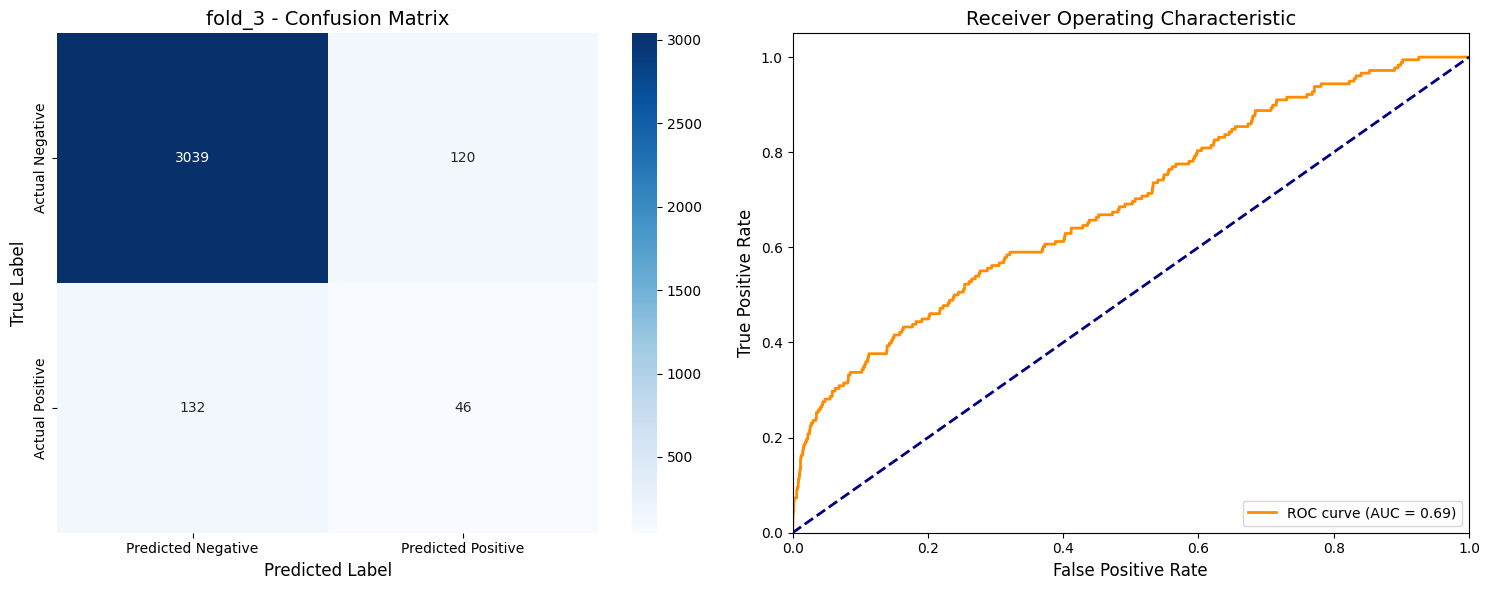


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6890
 F1 Score 0.6138
Precision 0.6177
   Recall 0.6102
 Accuracy 0.9245


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.277108 0.258427
Negative   0.958373 0.962013


🌀 Fold 4/5


Training fold 4:   2%|███                                                                                                                                                       | 1/50 [00:00<00:22,  2.15it/s]

  Epoch 1/50 | Loss: 0.4300


Training fold 4:   4%|██████▏                                                                                                                                                   | 2/50 [00:00<00:21,  2.20it/s]

  Epoch 2/50 | Loss: 0.4085


Training fold 4:   6%|█████████▏                                                                                                                                                | 3/50 [00:01<00:21,  2.19it/s]

  Epoch 3/50 | Loss: 0.3963


Training fold 4:   8%|████████████▎                                                                                                                                             | 4/50 [00:01<00:21,  2.19it/s]

  Epoch 4/50 | Loss: 0.3875


Training fold 4:  10%|███████████████▍                                                                                                                                          | 5/50 [00:02<00:20,  2.19it/s]

  Epoch 5/50 | Loss: 0.3756


Training fold 4:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:02<00:20,  2.20it/s]

  Epoch 6/50 | Loss: 0.3649


Training fold 4:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:03<00:19,  2.20it/s]

  Epoch 7/50 | Loss: 0.3537


Training fold 4:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:03<00:19,  2.21it/s]

  Epoch 8/50 | Loss: 0.3470


Training fold 4:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:04<00:18,  2.21it/s]

  Epoch 9/50 | Loss: 0.3348


Training fold 4:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:04<00:18,  2.20it/s]

  Epoch 10/50 | Loss: 0.3273


Training fold 4:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:05<00:17,  2.20it/s]

  Epoch 11/50 | Loss: 0.3175


Training fold 4:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:05<00:17,  2.21it/s]

  Epoch 12/50 | Loss: 0.3117


Training fold 4:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:05<00:16,  2.21it/s]

  Epoch 13/50 | Loss: 0.3070


Training fold 4:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:06<00:16,  2.21it/s]

  Epoch 14/50 | Loss: 0.2983


Training fold 4:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:06<00:15,  2.21it/s]

  Epoch 15/50 | Loss: 0.2881


Training fold 4:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:07<00:15,  2.21it/s]

  Epoch 16/50 | Loss: 0.2866


Training fold 4:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [00:07<00:14,  2.22it/s]

  Epoch 17/50 | Loss: 0.2785


Training fold 4:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [00:08<00:14,  2.21it/s]

  Epoch 18/50 | Loss: 0.2720


Training fold 4:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [00:08<00:14,  2.18it/s]

  Epoch 19/50 | Loss: 0.2667


Training fold 4:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [00:09<00:13,  2.15it/s]

  Epoch 20/50 | Loss: 0.2640


Training fold 4:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [00:09<00:13,  2.11it/s]

  Epoch 21/50 | Loss: 0.2605


Training fold 4:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [00:10<00:13,  2.12it/s]

  Epoch 22/50 | Loss: 0.2519


Training fold 4:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [00:10<00:12,  2.11it/s]

  Epoch 23/50 | Loss: 0.2494


Training fold 4:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [00:11<00:12,  2.11it/s]

  Epoch 24/50 | Loss: 0.2414


Training fold 4:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [00:11<00:11,  2.11it/s]

  Epoch 25/50 | Loss: 0.2383


Training fold 4:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [00:11<00:11,  2.11it/s]

  Epoch 26/50 | Loss: 0.2324


Training fold 4:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [00:12<00:10,  2.09it/s]

  Epoch 27/50 | Loss: 0.2302


Training fold 4:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [00:12<00:10,  2.10it/s]

  Epoch 28/50 | Loss: 0.2245


Training fold 4:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [00:13<00:09,  2.10it/s]

  Epoch 29/50 | Loss: 0.2219


Training fold 4:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [00:13<00:09,  2.12it/s]

  Epoch 30/50 | Loss: 0.2195


Training fold 4:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [00:14<00:08,  2.14it/s]

  Epoch 31/50 | Loss: 0.2154


Training fold 4:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [00:14<00:08,  2.16it/s]

  Epoch 32/50 | Loss: 0.2093


Training fold 4:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [00:15<00:07,  2.18it/s]

  Epoch 33/50 | Loss: 0.2075


Training fold 4:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [00:15<00:07,  2.19it/s]

  Epoch 34/50 | Loss: 0.2023


Training fold 4:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [00:16<00:06,  2.20it/s]

  Epoch 35/50 | Loss: 0.2020


Training fold 4:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [00:16<00:06,  2.18it/s]

  Epoch 36/50 | Loss: 0.1961


Training fold 4:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [00:17<00:05,  2.20it/s]

  Epoch 37/50 | Loss: 0.1909


Training fold 4:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [00:17<00:05,  2.21it/s]

  Epoch 38/50 | Loss: 0.1879


Training fold 4:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [00:17<00:04,  2.21it/s]

  Epoch 39/50 | Loss: 0.1869


Training fold 4:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [00:18<00:04,  2.21it/s]

  Epoch 40/50 | Loss: 0.1833


Training fold 4:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [00:18<00:04,  2.22it/s]

  Epoch 41/50 | Loss: 0.1793


Training fold 4:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [00:19<00:03,  2.22it/s]

  Epoch 42/50 | Loss: 0.1782


Training fold 4:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [00:19<00:03,  2.21it/s]

  Epoch 43/50 | Loss: 0.1722


Training fold 4:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [00:20<00:02,  2.21it/s]

  Epoch 44/50 | Loss: 0.1684


Training fold 4:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [00:20<00:02,  2.20it/s]

  Epoch 45/50 | Loss: 0.1690


Training fold 4:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [00:21<00:01,  2.21it/s]

  Epoch 46/50 | Loss: 0.1644


Training fold 4:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [00:21<00:01,  2.21it/s]

  Epoch 47/50 | Loss: 0.1617


Training fold 4:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [00:22<00:00,  2.21it/s]

  Epoch 48/50 | Loss: 0.1592


Training fold 4:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [00:22<00:00,  2.21it/s]

  Epoch 49/50 | Loss: 0.1566


Training fold 4: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:22<00:00,  2.18it/s]

  Epoch 50/50 | Loss: 0.1581


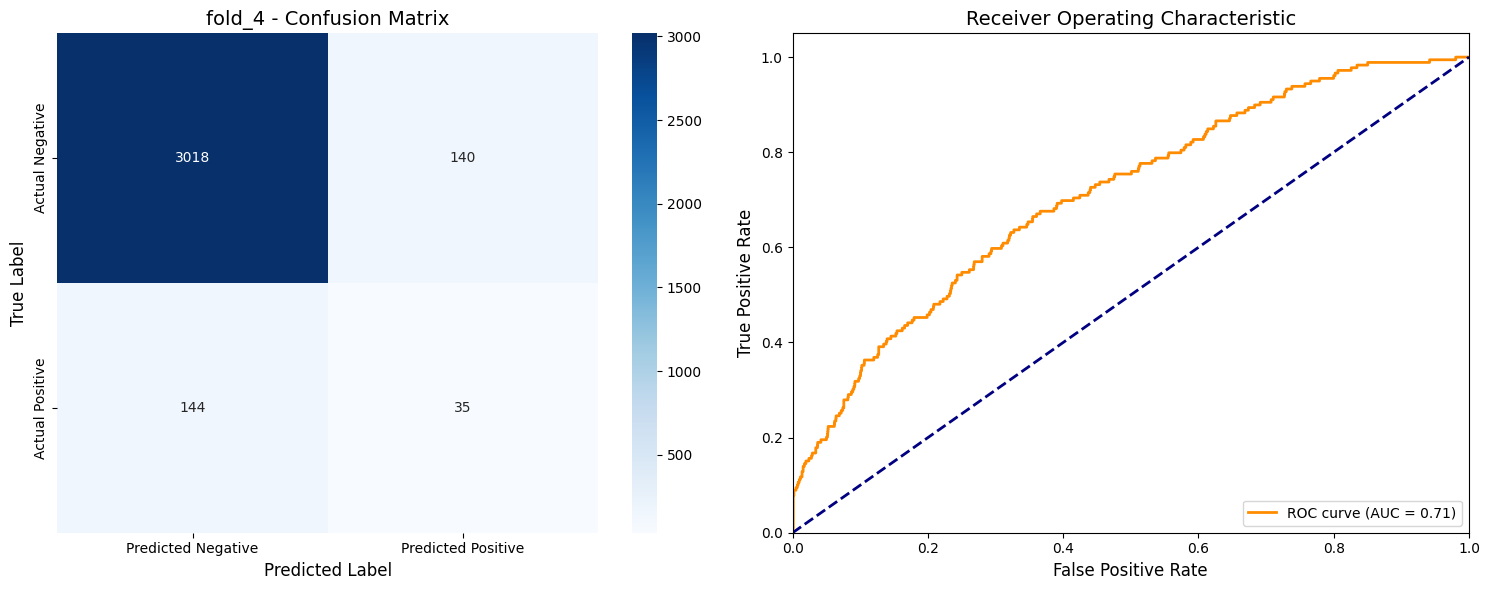


                     FOLD_4 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7105
 F1 Score 0.5764
Precision 0.5772
   Recall 0.5756
 Accuracy 0.9149


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.200000 0.195531
Negative   0.954459 0.955668


🌀 Fold 5/5


Training fold 5:   2%|███                                                                                                                                                       | 1/50 [00:00<00:23,  2.08it/s]

  Epoch 1/50 | Loss: 0.4288


Training fold 5:   4%|██████▏                                                                                                                                                   | 2/50 [00:00<00:22,  2.10it/s]

  Epoch 2/50 | Loss: 0.4080


Training fold 5:   6%|█████████▏                                                                                                                                                | 3/50 [00:01<00:21,  2.15it/s]

  Epoch 3/50 | Loss: 0.3932


Training fold 5:   8%|████████████▎                                                                                                                                             | 4/50 [00:01<00:21,  2.18it/s]

  Epoch 4/50 | Loss: 0.3853


Training fold 5:  10%|███████████████▍                                                                                                                                          | 5/50 [00:02<00:20,  2.18it/s]

  Epoch 5/50 | Loss: 0.3701


Training fold 5:  12%|██████████████████▍                                                                                                                                       | 6/50 [00:02<00:20,  2.19it/s]

  Epoch 6/50 | Loss: 0.3583


Training fold 5:  14%|█████████████████████▌                                                                                                                                    | 7/50 [00:03<00:19,  2.20it/s]

  Epoch 7/50 | Loss: 0.3488


Training fold 5:  16%|████████████████████████▋                                                                                                                                 | 8/50 [00:03<00:19,  2.21it/s]

  Epoch 8/50 | Loss: 0.3396


Training fold 5:  18%|███████████████████████████▋                                                                                                                              | 9/50 [00:04<00:18,  2.21it/s]

  Epoch 9/50 | Loss: 0.3318


Training fold 5:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [00:04<00:18,  2.19it/s]

  Epoch 10/50 | Loss: 0.3187


Training fold 5:  22%|█████████████████████████████████▋                                                                                                                       | 11/50 [00:05<00:17,  2.20it/s]

  Epoch 11/50 | Loss: 0.3119


Training fold 5:  24%|████████████████████████████████████▋                                                                                                                    | 12/50 [00:05<00:17,  2.20it/s]

  Epoch 12/50 | Loss: 0.3032


Training fold 5:  26%|███████████████████████████████████████▊                                                                                                                 | 13/50 [00:05<00:16,  2.21it/s]

  Epoch 13/50 | Loss: 0.2983


Training fold 5:  28%|██████████████████████████████████████████▊                                                                                                              | 14/50 [00:06<00:16,  2.19it/s]

  Epoch 14/50 | Loss: 0.2876


Training fold 5:  30%|█████████████████████████████████████████████▉                                                                                                           | 15/50 [00:06<00:15,  2.20it/s]

  Epoch 15/50 | Loss: 0.2786


Training fold 5:  32%|████████████████████████████████████████████████▉                                                                                                        | 16/50 [00:07<00:15,  2.21it/s]

  Epoch 16/50 | Loss: 0.2750


Training fold 5:  34%|████████████████████████████████████████████████████                                                                                                     | 17/50 [00:07<00:14,  2.22it/s]

  Epoch 17/50 | Loss: 0.2666


Training fold 5:  36%|███████████████████████████████████████████████████████                                                                                                  | 18/50 [00:08<00:14,  2.22it/s]

  Epoch 18/50 | Loss: 0.2600


Training fold 5:  38%|██████████████████████████████████████████████████████████▏                                                                                              | 19/50 [00:08<00:13,  2.22it/s]

  Epoch 19/50 | Loss: 0.2541


Training fold 5:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [00:09<00:13,  2.22it/s]

  Epoch 20/50 | Loss: 0.2482


Training fold 5:  42%|████████████████████████████████████████████████████████████████▎                                                                                        | 21/50 [00:09<00:13,  2.21it/s]

  Epoch 21/50 | Loss: 0.2432


Training fold 5:  44%|███████████████████████████████████████████████████████████████████▎                                                                                     | 22/50 [00:10<00:12,  2.21it/s]

  Epoch 22/50 | Loss: 0.2395


Training fold 5:  46%|██████████████████████████████████████████████████████████████████████▍                                                                                  | 23/50 [00:10<00:12,  2.21it/s]

  Epoch 23/50 | Loss: 0.2347


Training fold 5:  48%|█████████████████████████████████████████████████████████████████████████▍                                                                               | 24/50 [00:10<00:11,  2.21it/s]

  Epoch 24/50 | Loss: 0.2294


Training fold 5:  50%|████████████████████████████████████████████████████████████████████████████▌                                                                            | 25/50 [00:11<00:11,  2.20it/s]

  Epoch 25/50 | Loss: 0.2238


Training fold 5:  52%|███████████████████████████████████████████████████████████████████████████████▌                                                                         | 26/50 [00:11<00:10,  2.21it/s]

  Epoch 26/50 | Loss: 0.2221


Training fold 5:  54%|██████████████████████████████████████████████████████████████████████████████████▌                                                                      | 27/50 [00:12<00:10,  2.21it/s]

  Epoch 27/50 | Loss: 0.2179


Training fold 5:  56%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 28/50 [00:12<00:09,  2.20it/s]

  Epoch 28/50 | Loss: 0.2117


Training fold 5:  58%|████████████████████████████████████████████████████████████████████████████████████████▋                                                                | 29/50 [00:13<00:09,  2.21it/s]

  Epoch 29/50 | Loss: 0.2069


Training fold 5:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [00:13<00:09,  2.22it/s]

  Epoch 30/50 | Loss: 0.2038


Training fold 5:  62%|██████████████████████████████████████████████████████████████████████████████████████████████▊                                                          | 31/50 [00:14<00:08,  2.22it/s]

  Epoch 31/50 | Loss: 0.1996


Training fold 5:  64%|█████████████████████████████████████████████████████████████████████████████████████████████████▉                                                       | 32/50 [00:14<00:08,  2.22it/s]

  Epoch 32/50 | Loss: 0.1986


Training fold 5:  66%|████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                    | 33/50 [00:14<00:07,  2.23it/s]

  Epoch 33/50 | Loss: 0.1933


Training fold 5:  68%|████████████████████████████████████████████████████████████████████████████████████████████████████████                                                 | 34/50 [00:15<00:07,  2.23it/s]

  Epoch 34/50 | Loss: 0.1913


Training fold 5:  70%|███████████████████████████████████████████████████████████████████████████████████████████████████████████                                              | 35/50 [00:15<00:06,  2.18it/s]

  Epoch 35/50 | Loss: 0.1854


Training fold 5:  72%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                          | 36/50 [00:16<00:06,  2.16it/s]

  Epoch 36/50 | Loss: 0.1817


Training fold 5:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                       | 37/50 [00:16<00:06,  2.15it/s]

  Epoch 37/50 | Loss: 0.1781


Training fold 5:  76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 38/50 [00:17<00:05,  2.14it/s]

  Epoch 38/50 | Loss: 0.1765


Training fold 5:  78%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                 | 39/50 [00:17<00:05,  2.14it/s]

  Epoch 39/50 | Loss: 0.1727


Training fold 5:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [00:18<00:04,  2.11it/s]

  Epoch 40/50 | Loss: 0.1705


Training fold 5:  82%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                           | 41/50 [00:18<00:04,  2.09it/s]

  Epoch 41/50 | Loss: 0.1680


Training fold 5:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 42/50 [00:19<00:03,  2.10it/s]

  Epoch 42/50 | Loss: 0.1658


Training fold 5:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 43/50 [00:19<00:03,  2.11it/s]

  Epoch 43/50 | Loss: 0.1629


Training fold 5:  88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                  | 44/50 [00:20<00:02,  2.11it/s]

  Epoch 44/50 | Loss: 0.1601


Training fold 5:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋               | 45/50 [00:20<00:02,  2.10it/s]

  Epoch 45/50 | Loss: 0.1574


Training fold 5:  92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊            | 46/50 [00:21<00:01,  2.13it/s]

  Epoch 46/50 | Loss: 0.1536


Training fold 5:  94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊         | 47/50 [00:21<00:01,  2.16it/s]

  Epoch 47/50 | Loss: 0.1516


Training fold 5:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉      | 48/50 [00:22<00:00,  2.18it/s]

  Epoch 48/50 | Loss: 0.1488


Training fold 5:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 49/50 [00:22<00:00,  2.19it/s]

  Epoch 49/50 | Loss: 0.1458


Training fold 5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:22<00:00,  2.18it/s]

  Epoch 50/50 | Loss: 0.1425


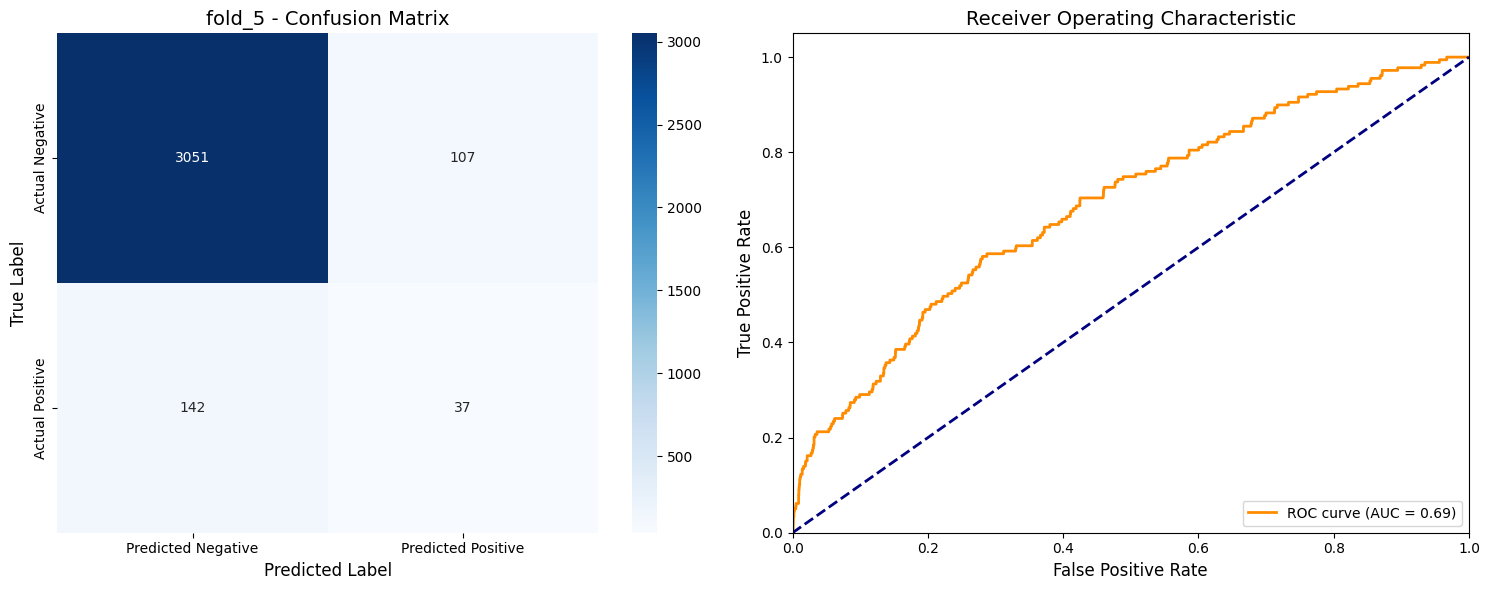


                     FOLD_5 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.6890
 F1 Score 0.5949
Precision 0.6062
   Recall 0.5864
 Accuracy 0.9254


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.256944 0.206704
Negative   0.955528 0.966118



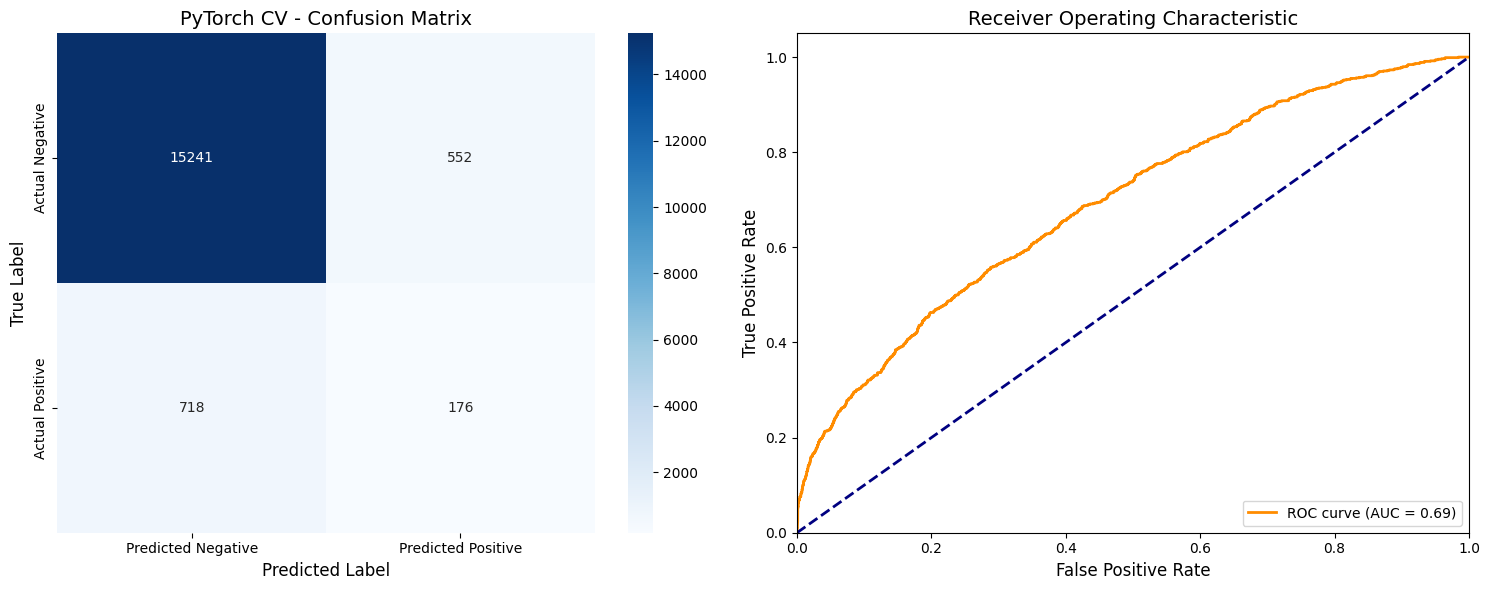

CPU times: user 50.8 s, sys: 6.07 s, total: 56.9 s
Wall time: 2min


ClassificationMetrics(name='CNN with GloVe', training_time=114.54725787600546, estimators=[{'preprocessor': SequenceVectorizer(max_length=1000, pad_left=False,
                   vocabulary={'!': 807, '"': 10, '#': 2751, '$': 82, '%': 264,
                               '&': 1163, '&amp;': 725, "'": 59, "''": 29,
                               "'50s": 17347, "'60s": 11122, "'70s": 10964,
                               "'80s": 11320, "'90s": 11437, "'d": 1153,
                               "'em": 10806, "'ll": 771, "'m": 474, "'n": 18701,
                               "'n'": 12556, "'re": 269, "'s": 11, "'ve": 464,
                               '(': 25, '(212)': 16047, '(800)': 13105, ')': 26,
                               '*': 13699, '+': 3280, ',': 3, ...}), 'model': GloveCNNForHallucinationDetection(
  (embedding): Embedding(20003, 100)
  (relu): ReLU()
  (conv): Conv1d(100, 10, kernel_size=(3,), stride=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in

In [69]:
%%time

glove_cnn_metrics = cross_validate_model(
    model=glove_cnn_model,
    X=data_nn['Input'],
    y=data_nn['Target'],
    preprocessor=glove_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=50,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name='CNN with GloVe'
)

glove_cnn_metrics

Процесс обучения прошел быстрее чем у классической CNN, благодаря меньшему количеству обучаемых парамтеров

Сделаем прогноз на тестовых данных

In [70]:
result = predict_with_ensemble(glove_cnn_metrics.estimators, test_data_nn['Input'], device, 256)
glove_cnn_predictions = result[1]
glove_cnn_predictions

Predicting ensemble: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87/87 [00:03<00:00, 25.89it/s]


array([0.23272195, 0.07774238, 0.00124065, ..., 0.11036283, 0.04222597,
       0.01477696], shape=(11125,), dtype=float32)

In [71]:
glove_cnn_submission = build_submission_dataframe(test_data=test_data, id_column="Id", 
                                                  target_column="Target", predictions=glove_cnn_predictions)

glove_cnn_submission.head(5)

,Id,Target
0,20568,0.232722
1,17686,0.077742
2,13035,0.001241
3,22646,0.132822
4,5535,0.035918


In [72]:
glove_cnn_submission.to_csv(f"{data_path}/glove_cnn_submission.csv", index=False)

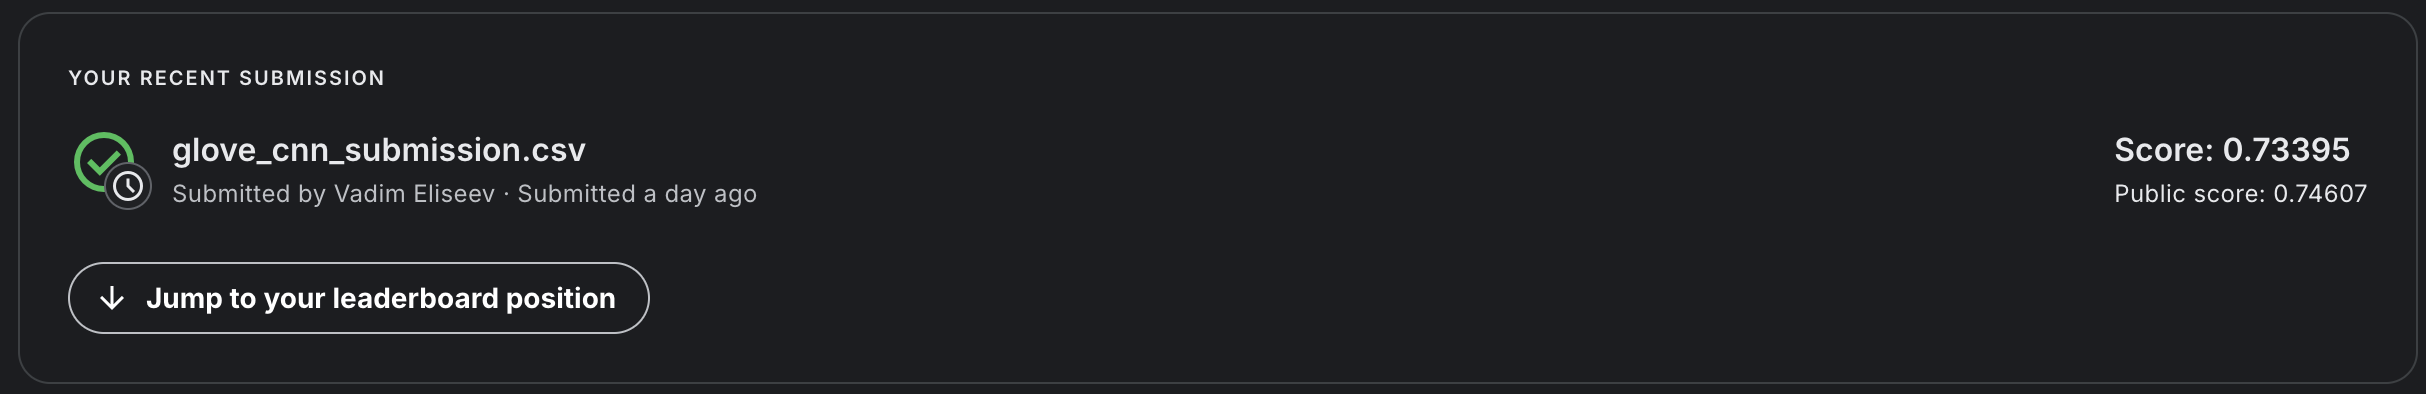

CNN с предобученными эмбеддингами справилась лучше RNN и LSTM, однако уступила CNN с обучаемой матрицой эмбеддингов

## Сравнение качества полученных моделей

Сравним качество базового решения с нейросетями с помощью тепловой карты

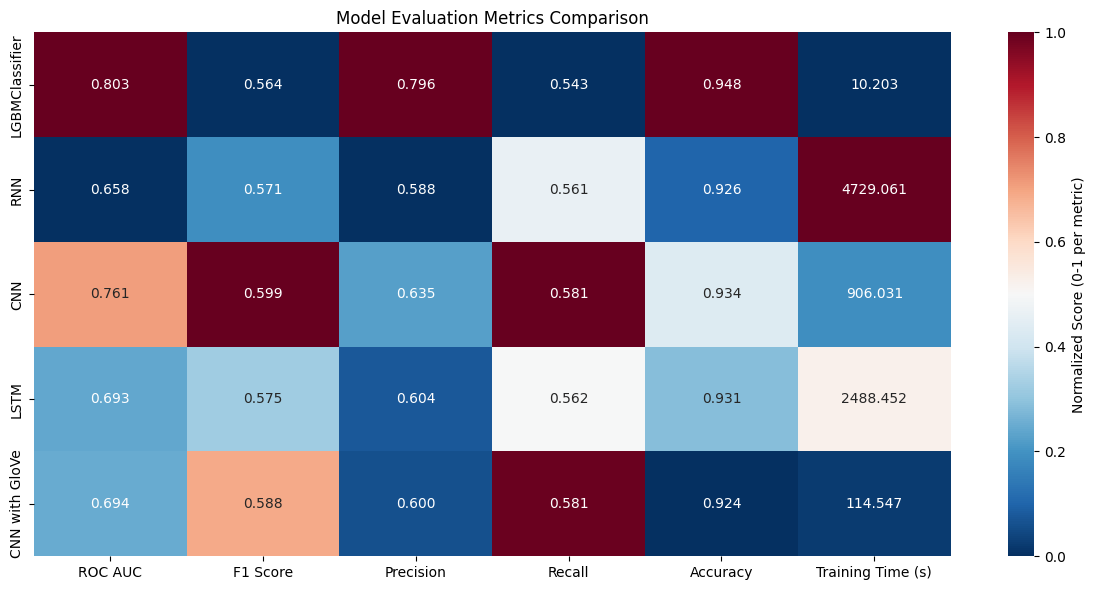

In [73]:
plot_metrics_heatmap([
    baseline_metrics,
    rnn_metrics,
    cnn_metrics,
    lstm_metrics,
    glove_cnn_metrics
])

Лучший результат все еще показала комбинация `CountVectorizer` и `LGBM` без удаления стоп-слов и пунктуации. Далее расположились CNN с обучаемыми и GloVe эмбеддингами, после них LSTM и RNN

Лучший результат версии CNN с обучаемыми эмбеддингами по сравнению с GloVe может быть следствием наличия зависимости сгенерированности текста от наличия конкретных токенов в нем. Это может объяснить и превосходство градиентного бустинга над нейронными сетями

В дальнейшем можно сравнить лучший алгоритм этого шага с подходами, связанными с дообучением существующих LLM (transfer learning)